In [ ]:
# ============================================================
# LOADING 5K JOB DATASET
# ============================================================
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()

# Automatically pick the uploaded CSV file
csv_file = next(
    (name for name in uploaded.keys() if name.lower().endswith('.csv')),
    None
)

if csv_file is None:
    raise ValueError('Please upload a CSV file.')

# Load only the 5,000 records needed for this project
df = pd.read_csv(csv_file, nrows=5000)

print(f'Loaded file: {csv_file}')
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')


In [ ]:
# Verify that the dataset is the expected 5K-record dataset
if len(df) > 5000:
    df = df.head(5000).copy()

print('Dataset shape:', df.shape)
display(df.head())


In [ ]:
# No Kaggle download is required because the 5K CSV is already uploaded.
print('Using the uploaded 5K CSV file.')


In [ ]:
# Dataset is already loaded into df above.
# Do not reload the original 1.6M-row Kaggle dataset.
df.shape


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
display(df.head())

In [ ]:
df.tail()

In [ ]:
df.shape #Get the number of rows and columns

In [ ]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

In [ ]:
df.columns.tolist()

In [ ]:
#Checking Data Type This is particularly important for:

# Job Posting Date
# Job Description
# Skills
# Experience
# Salary Range

df.info()

In [ ]:
#Check missing values

missing = df.isnull().sum()

missing = missing.sort_values(ascending=False)

missing

In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

In [ ]:
#Create a combined table
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_report.sort_values(
    "Missing Percentage",
    ascending=False
)

In [ ]:
#checking Duplicate Values

df.duplicated().sum()

In [ ]:
df["Job Id"].duplicated().sum()

In [ ]:
df[df["Job Id"].duplicated(keep=False)]

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

from wordcloud import WordCloud

In [ ]:
!pip install wordcloud

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 1000)

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [ ]:
df.columns.tolist()

['job_id',
 'experience',
 'qualifications',
 'salary_range',
 'location',
 'country',
 'latitude',
 'longitude',
 'work_type',
 'company_size',
 'job_posting_date',
 'preference',
 'contact_person',
 'contact',
 'job_title',
 'role',
 'job_portal',
 'job_description',
 'benefits',
 'skills',
 'responsibilities',
 'company',
 'company_profile']

In [ ]:
df.dtypes

,0
job_id,float64
experience,object
qualifications,object
salary_range,object
location,object
country,object
latitude,float64
longitude,float64
work_type,object
company_size,int64


In [ ]:
data_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isnull().sum(),
    "missing_%": df.isnull().mean() * 100,
    "unique_values": df.nunique()
})

data_summary.sort_values(
    "missing_%",
    ascending=False
)

,dtype,missing_count,missing_%,unique_values
company_profile,object,15,0.3,882
experience,object,0,0.0,48
job_id,float64,0,0.0,4967
salary_range,object,0,0.0,560
location,object,0,0.0,214
country,object,0,0.0,216
qualifications,object,0,0.0,10
latitude,float64,0,0.0,216
longitude,float64,0,0.0,216
company_size,int64,0,0.0,4900


In [ ]:
#missing value Analysis

missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
company_profile,15


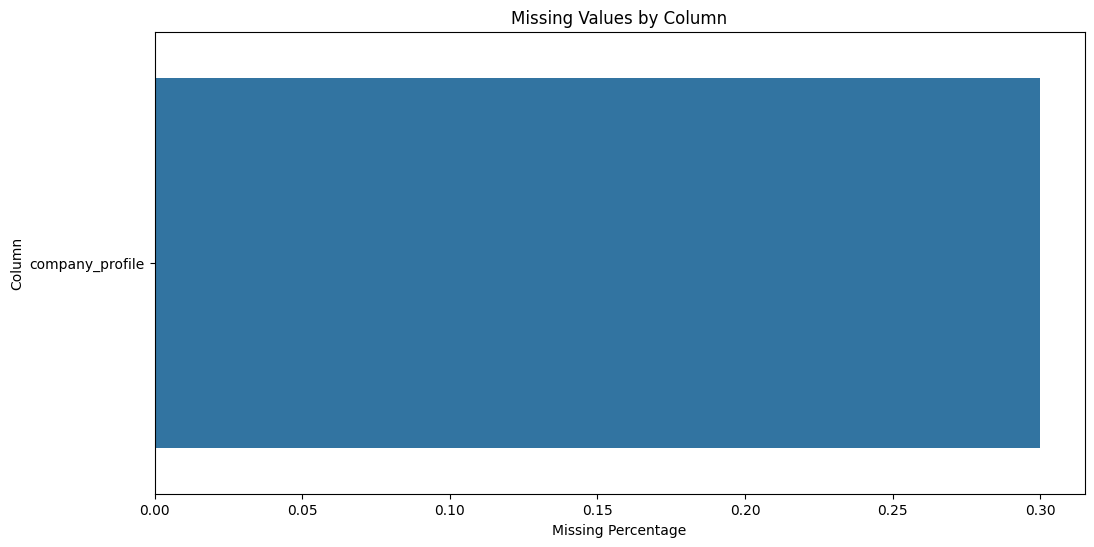

In [ ]:
#Visualizing Missing Values

missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")

plt.show()

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Job IDs:", df["job_id"].duplicated().sum())

Duplicate rows: 0
Duplicate Job IDs: 33


In [ ]:
#Checking Unique Values
categorical_columns = [
    "work_type",
    "company_size",
    "preference",
    "job_title",
    "role",
    "job_portal",
    "country"
]

for col in categorical_columns:
    if col in df.columns:
        print(f"\n{'='*50}")
        print(col.upper())
        print("Unique values:", df[col].nunique())
        print(df[col].value_counts(dropna=False).head(15))


WORK_TYPE
Unique values: 5
work_type
Temporary    1022
Full-Time    1013
Contract     1002
Part-Time     998
Intern        965
Name: count, dtype: int64

COMPANY_SIZE
Unique values: 4900
company_size
57916     3
110234    3
109030    2
86718     2
18433     2
65899     2
16609     2
78870     2
26928     2
49941     2
88586     2
17089     2
40019     2
125996    2
92898     2
Name: count, dtype: int64

PREFERENCE
Unique values: 3
preference
Both      1692
Female    1661
Male      1647
Name: count, dtype: int64

JOB_TITLE
Unique values: 147
job_title
UX/UI Designer                  154
Software Engineer                87
Digital Marketing Specialist     85
Network Engineer                 69
Procurement Manager              68
Customer Support Specialist      68
Software Tester                  63
HR Coordinator                   57
Executive Assistant              57
Purchasing Agent                 57
UI Developer                     56
Systems Administrator            56
Financial 

In [ ]:
#Date Preprocessing
df["job_posting_date"].head()

,job_posting_date
0,24-04-2022
1,19-12-2022
2,14-09-2022
3,25-02-2023
4,11-10-2022


In [ ]:
df["job_posting_date"] = pd.to_datetime(
    df["job_posting_date"],
    errors="coerce"
)

/tmp/ipykernel_529/517274293.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["job_posting_date"] = pd.to_datetime(


In [ ]:
#After converting date datatype checking it

df["job_posting_date"].dtype

dtype('<M8[ns]')

In [ ]:
#Extracting Useful features

df["posting_year"] = df["job_posting_date"].dt.year
df["posting_month"] = df["job_posting_date"].dt.month
df["posting_day"] = df["job_posting_date"].dt.day
df["posting_day_name"] = df["job_posting_date"].dt.day_name()

In [ ]:
yearly_jobs = df["posting_year"].value_counts().sort_index()

yearly_jobs
#job posting trends

,count
posting_year,
2021,732
2022,2521
2023,1747


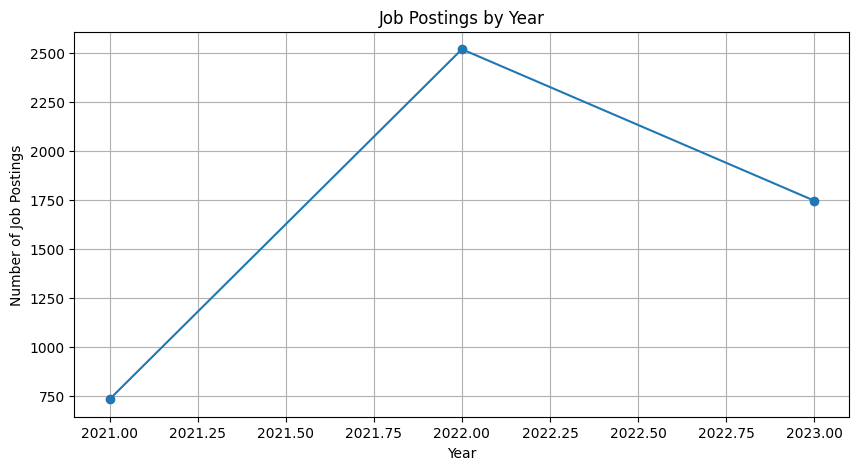

In [ ]:
plt.figure(figsize=(10, 5))

yearly_jobs.plot(kind="line", marker="o")

plt.title("Job Postings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Job Postings")
plt.grid(True)

plt.show()

In [ ]:
#Job title Analysis
top_job_titles = df["job_title"].value_counts().head(15)

top_job_titles

,count
job_title,
UX/UI Designer,154
Software Engineer,87
Digital Marketing Specialist,85
Network Engineer,69
Procurement Manager,68
Customer Support Specialist,68
Software Tester,63
HR Coordinator,57
Executive Assistant,57


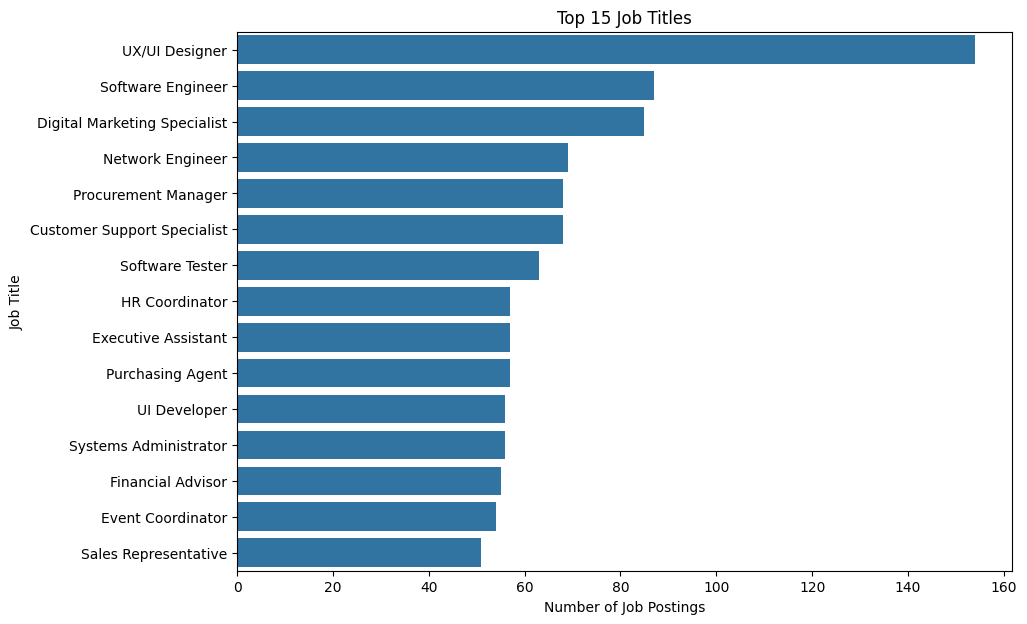

In [ ]:
#Visualization of above
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_job_titles.values,
    y=top_job_titles.index
)

plt.title("Top 15 Job Titles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")

plt.show()

In [ ]:
#Role Ananlysis
top_roles = df["role"].value_counts().head(15)

top_roles

,count
role,
Interaction Designer,61
User Interface Designer,53
Network Administrator,52
Procurement Analyst,47
Social Media Manager,44
User Experience Designer,40
Backend Developer,40
Database Administrator,37
Customer Success Manager,37


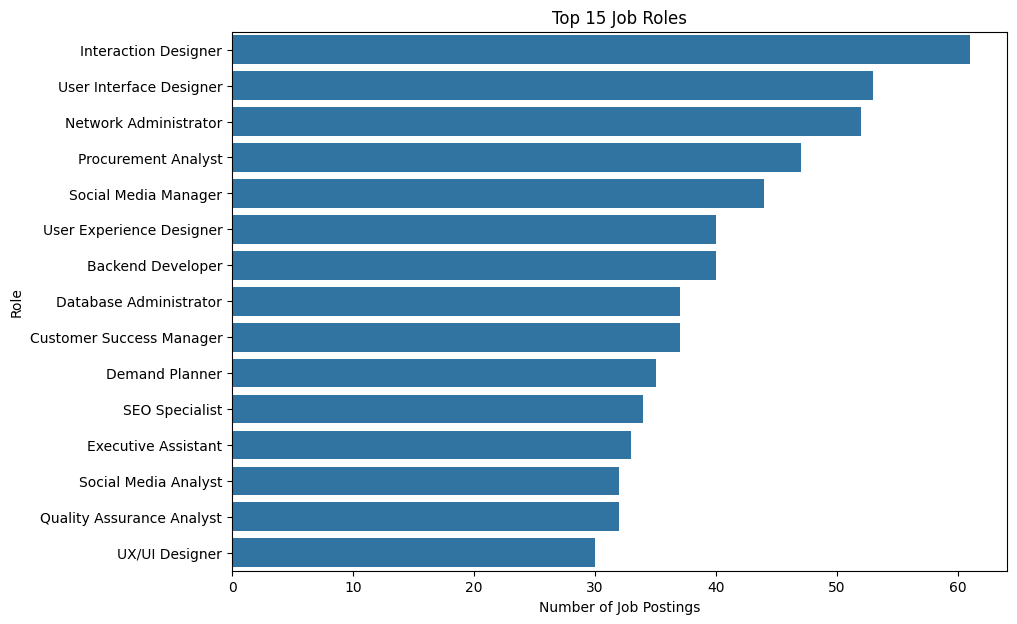

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_roles.values,
    y=top_roles.index
)

plt.title("Top 15 Job Roles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Role")

plt.show()

In [ ]:
#Work Type Analysis
df["work_type"].value_counts()

,count
work_type,
Temporary,1022
Full-Time,1013
Contract,1002
Part-Time,998
Intern,965


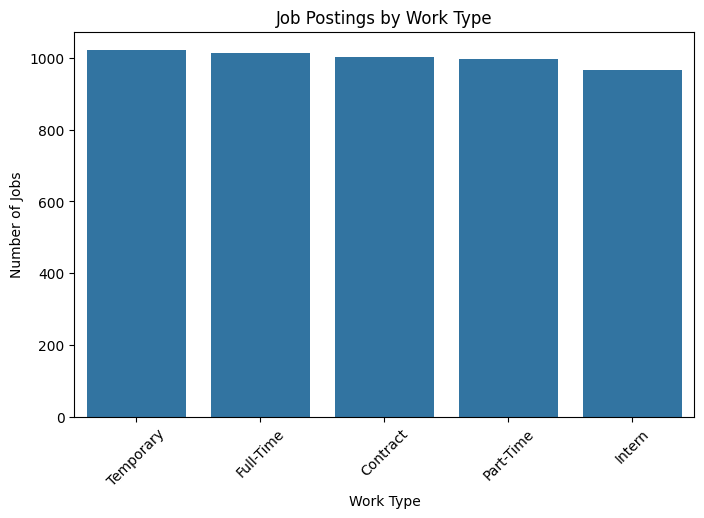

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="work_type",
    order=df["work_type"].value_counts().index
)

plt.title("Job Postings by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

In [ ]:
#Country Analysis

top_countries = df["country"].value_counts().head(15)

top_countries

,count
country,
Rwanda,36
American Samoa,36
St. Lucia,35
South Sudan,34
Sint Maarten (Dutch part),34
Sao Tome and Principe,33
Comoros,32
Isle of Man,32
Belize,32


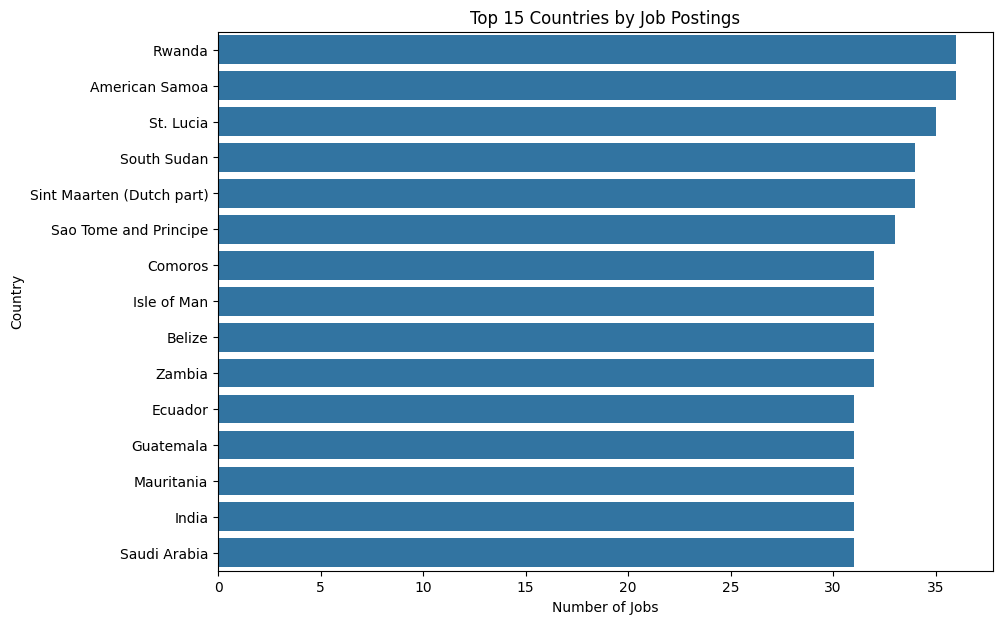

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 15 Countries by Job Postings")
plt.xlabel("Number of Jobs")
plt.ylabel("Country")

plt.show()

In [ ]:
#Company Size Analysis
df["company_size"].value_counts()

,count
company_size,
57916,3
110234,3
109030,2
86718,2
18433,2
...,...
124454,1
18232,1
49946,1


In [ ]:
#Moving to NLP Specific Processing
df[["job_title", "job_description", "skills"]].head(10)

,job_title,job_description,skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create ...","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain p...","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communicati...",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to t...",Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing"
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",Teaching pedagogy Classroom management Curriculum development Student assessment Differentiated instruction
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interf...","UI design principles and best practices Graphic design tools (e.g., Adobe Photoshop, Illustrator) Typography and color theory Visual design and layout Responsive design"
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",Wedding planning Vendor coordination Event management


In [ ]:
#Checking missing Values
print("Missing Job Descriptions:",
      df["job_description"].isna().sum())

print("Missing Skills:",
      df["skills"].isna().sum())

Missing Job Descriptions: 0
Missing Skills: 0


In [ ]:
df["job_description_clean"] = (
    df["job_description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

In [ ]:
#Character Count
df["description_char_count"] = (
    df["job_description_clean"].str.len()
)

In [ ]:
#Word Count
df["description_word_count"] = (
    df["job_description_clean"]
    .str.split()
    .str.len()
)

In [ ]:
#Sentence Approximation
df["description_sentence_count"] = (
    df["job_description_clean"]
    .str.count(r"[.!?]")
)

In [ ]:
df[
    [
        "description_char_count",
        "description_word_count",
        "description_sentence_count"
    ]
].describe()

,description_char_count,description_word_count,description_sentence_count
count,5000.000000,5000.000000,5000.000000
mean,185.914000,24.270800,1.630800
std,52.281386,7.492469,0.542725
min,81.000000,10.000000,1.000000
25%,157.000000,19.000000,1.000000
50%,178.000000,24.000000,2.000000
75%,213.000000,28.000000,2.000000
max,430.000000,62.000000,3.000000


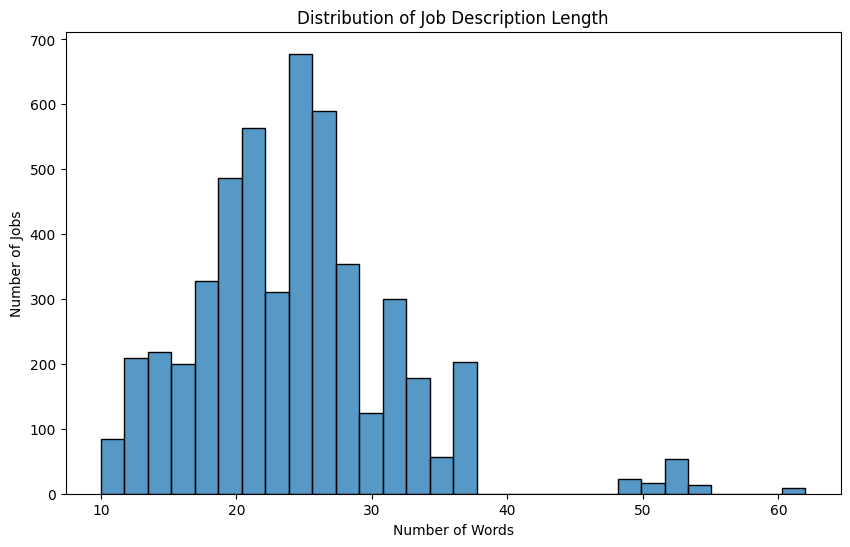

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="description_word_count",
    bins=30
)

plt.title("Distribution of Job Description Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Jobs")

plt.show()

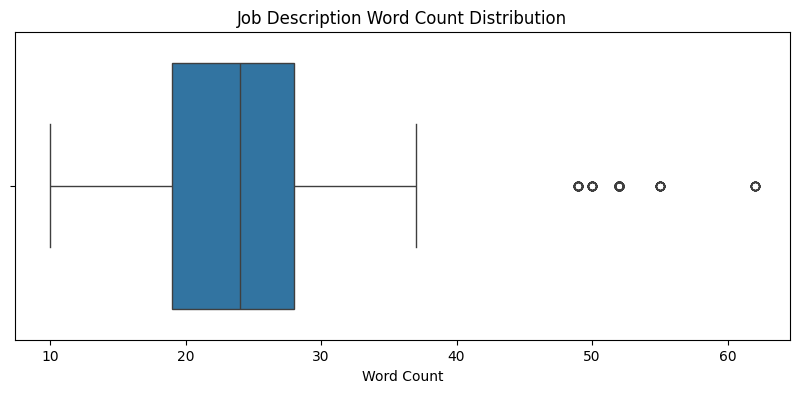

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["description_word_count"]
)

plt.title("Job Description Word Count Distribution")
plt.xlabel("Word Count")

plt.show()

In [ ]:
#Clean text for EDA
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s+#.-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
df["job_description_clean"] = (
    df["job_description_clean"]
    .apply(clean_text)
)

In [ ]:
df[
    ["job_description", "job_description_clean"]
].head()

,job_description,job_description_clean
0,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...",social media managers oversee an organizations social media presence. they create and schedule content engage with followers and analyze social media metrics to drive brand awareness and engagement.
1,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create ...",frontend web developers design and implement user interfaces for websites ensuring they are visually appealing and user-friendly. they collaborate with designers and backend developers to create s...
2,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain p...",quality control managers establish and enforce quality standards within an organization. they develop quality control processes perform inspections and implement corrective actions to maintain pro...
3,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communicati...",wireless network engineers design implement and maintain wireless network solutions. they optimize wireless connectivity troubleshoot issues and ensure reliable and secure wireless communications.
4,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to t...",a conference manager coordinates and manages conferences meetings and events. they plan logistics handle budgeting liaise with vendors and ensure the smooth execution of events catering to the nee...


In [ ]:
#ALL COMMON WORDS
all_text = " ".join(
    df["job_description_clean"]
)

In [ ]:
#TOKENIZE WORDS
words = all_text.split()

len(words)

121498

In [ ]:
#COUNT
word_counts = Counter(words)

word_counts.most_common(30)

[('and', 11145),
 ('to', 3905),
 ('they', 2993),
 ('a', 1819),
 ('the', 1648),
 ('in', 1389),
 ('with', 1382),
 ('ensure', 998),
 ('data', 982),
 ('for', 981),
 ('of', 954),
 ('on', 917),
 ('user', 806),
 ('or', 789),
 ('support', 743),
 ('provide', 712),
 ('create', 695),
 ('design', 674),
 ('an', 647),
 ('ensuring', 626),
 ('manage', 608),
 ('develop', 604),
 ('financial', 586),
 ('work', 547),
 ('analyze', 512),
 ('marketing', 481),
 ('research', 469),
 ('maintain', 452),
 ('legal', 452),
 ('strategies', 448)]

In [ ]:
#NLP START
import nltk
import pandas as pd

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


sample_text = """
We are looking for candidates with strong experience in Python and SQL.
"""

tokens = word_tokenize(sample_text)

print(tokens)

#day6

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


['We', 'are', 'looking', 'for', 'candidates', 'with', 'strong', 'experience', 'in', 'Python', 'and', 'SQL', '.']


In [ ]:
sample_text = """
We are looking for candidates with strong experience in Python and SQL.
The candidate should have good knowledge of Power BI and AWS.
"""

print(sample_text)


We are looking for candidates with strong experience in Python and SQL.
The candidate should have good knowledge of Power BI and AWS.



In [ ]:
lower_text = sample_text.lower()

print("Original:")
print(sample_text)

print("\nLowercase:")
print(lower_text)

Original:

We are looking for candidates with strong experience in Python and SQL.
The candidate should have good knowledge of Power BI and AWS.


Lowercase:

we are looking for candidates with strong experience in python and sql.
the candidate should have good knowledge of power bi and aws.



In [ ]:
#tokenization
tokens = word_tokenize(lower_text)

print("Tokens:")
print(tokens)

Tokens:
['we', 'are', 'looking', 'for', 'candidates', 'with', 'strong', 'experience', 'in', 'python', 'and', 'sql', '.', 'the', 'candidate', 'should', 'have', 'good', 'knowledge', 'of', 'power', 'bi', 'and', 'aws', '.']


In [ ]:
#REMOVING COMMON STOPWORDS
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords


stop_words = set(stopwords.words("english"))

filtered_tokens = [
    word
    for word in tokens
    if word.isalpha() and word not in stop_words
]

print("After Stopword Removal:")
print(filtered_tokens)

After Stopword Removal:
['looking', 'candidates', 'strong', 'experience', 'python', 'sql', 'candidate', 'good', 'knowledge', 'power', 'bi', 'aws']


In [ ]:
#Creating Filtered Words
filtered_words = [
    word
    for word in words
    if word not in stop_words
]

In [ ]:
word_counts = Counter(filtered_words)

word_counts.most_common(30)

[('ensure', 998),
 ('data', 982),
 ('user', 806),
 ('support', 743),
 ('provide', 712),
 ('create', 695),
 ('design', 674),
 ('ensuring', 626),
 ('manage', 608),
 ('develop', 604),
 ('financial', 586),
 ('work', 547),
 ('analyze', 512),
 ('marketing', 481),
 ('research', 469),
 ('maintain', 452),
 ('legal', 452),
 ('strategies', 448),
 ('customer', 447),
 ('sales', 437),
 ('quality', 434),
 ('managers', 425),
 ('content', 425),
 ('oversee', 389),
 ('improve', 384),
 ('implement', 382),
 ('systems', 381),
 ('optimize', 376),
 ('including', 374),
 ('social', 365)]

In [ ]:
#Visualizing Top WOrds
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "frequency"]
)

top_words

,word,frequency
0,ensure,998
1,data,982
2,user,806
3,support,743
4,provide,712
5,create,695
6,design,674
7,ensuring,626
8,manage,608
9,develop,604


In [ ]:
# Lemmatizaton
lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

print("Lemmatized Words:")
print(lemmatized_words)

Lemmatized Words:
['looking', 'candidate', 'strong', 'experience', 'python', 'sql', 'candidate', 'good', 'knowledge', 'power', 'bi', 'aws']


In [ ]:
#Stemming
stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in filtered_tokens
]

print("Stemmed Words:")
print(stemmed_words)

Stemmed Words:
['look', 'candid', 'strong', 'experi', 'python', 'sql', 'candid', 'good', 'knowledg', 'power', 'bi', 'aw']


In [ ]:
#Stemming Vs Lemmitization
comparison_df = pd.DataFrame({
    "Original": filtered_tokens,
    "Stemmed": stemmed_words,
    "Lemmatized": lemmatized_words
})

display(comparison_df)

,Original,Stemmed,Lemmatized
0,looking,look,looking
1,candidates,candid,candidate
2,strong,strong,strong
3,experience,experi,experience
4,python,python,python
5,sql,sql,sql
6,candidate,candid,candidate
7,good,good,good
8,knowledge,knowledg,knowledge
9,power,power,power


In [ ]:
#Sentense Segmentation
sentences = sent_tokenize(sample_text)

print("Sentences:")

for i, sentence in enumerate(sentences, 1):
    print(f"Sentence {i}: {sentence}")

Sentences:
Sentence 1: 
We are looking for candidates with strong experience in Python and SQL.
Sentence 2: The candidate should have good knowledge of Power BI and AWS.


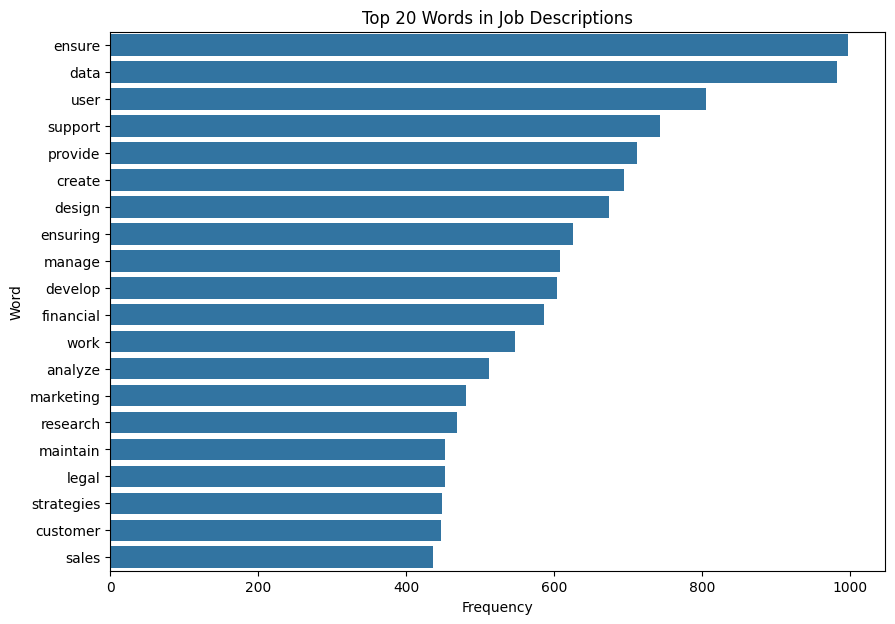

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_words,
    x="frequency",
    y="word"
)

plt.title("Top 20 Words in Job Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [ ]:
#WORD CLOUD
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(" ".join(filtered_words))

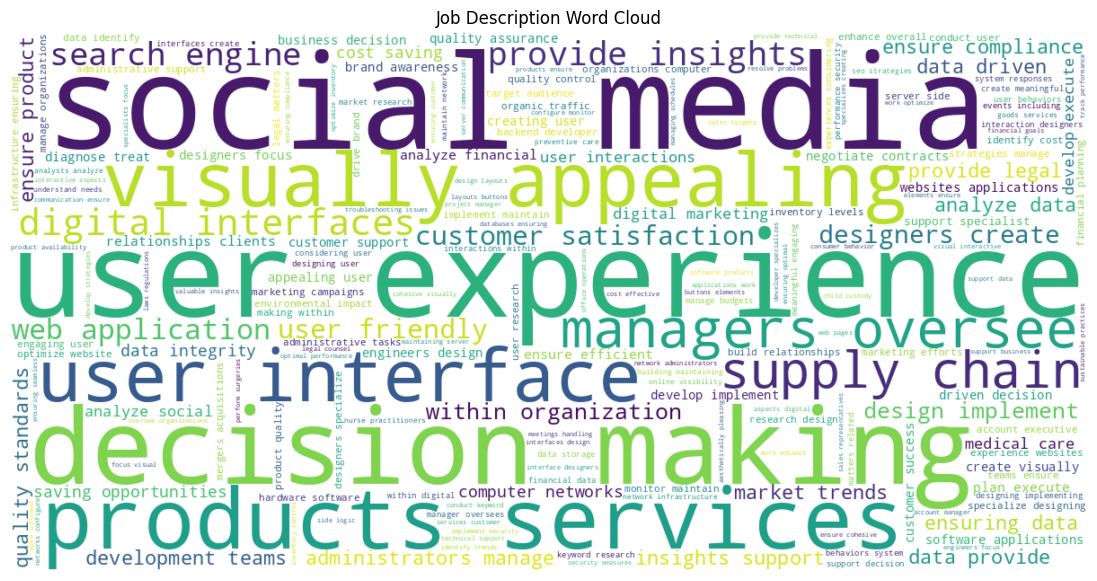

In [ ]:
plt.figure(figsize=(14, 7))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Job Description Word Cloud")

plt.show()

In [ ]:
#Analizing the Skills Column
df["skills"].head(20)

,skills
0,"Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising"
1,"HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)"
2,"Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge"
3,Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues
4,Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations
5,"Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing"
6,Teaching pedagogy Classroom management Curriculum development Student assessment Differentiated instruction
7,"UI design principles and best practices Graphic design tools (e.g., Adobe Photoshop, Illustrator) Typography and color theory Visual design and layout Responsive design"
8,Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes
9,Wedding planning Vendor coordination Event management


In [ ]:
print(df["skills"].iloc[0])

Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising


In [ ]:
print(type(df["skills"].iloc[0]))

<class 'str'>


In [ ]:
#Automatically Inspecting Skill Separator
for value in df["skills"].dropna().head(20):
    print(value)
    print("-" * 50)

Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising
--------------------------------------------------
HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)
--------------------------------------------------
Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge
--------------------------------------------------
Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues
--------------------------------------------------
Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations
------------------------------------

In [ ]:
df["skills_list"] = (
    df["skills"]
    .fillna("")
    .apply(
        lambda x: [
            skill.strip()
            for skill in x.split(",")
            if skill.strip()
        ]
    )
)

In [ ]:
#Skill Frequency
skill_counter = Counter()

for skills in df["skills_list"]:
    skill_counter.update(skills)

In [ ]:
#Creating Skill DataFrame
skill_frequency = pd.DataFrame(
    skill_counter.items(),
    columns=["skill", "frequency"]
).sort_values(
    "frequency",
    ascending=False
)

In [ ]:
skill_frequency.head(20)

,skill,frequency
46,Python,98
134,Google Analytics,86
45,Java,80
5,CSS,74
349,Sketch,73
175,AWS,64
20,Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes,61
66,Tableau,58
19,Illustrator) Typography and color theory Visual design and layout Responsive design,53
17,UI design principles and best practices Graphic design tools (e.g.,53


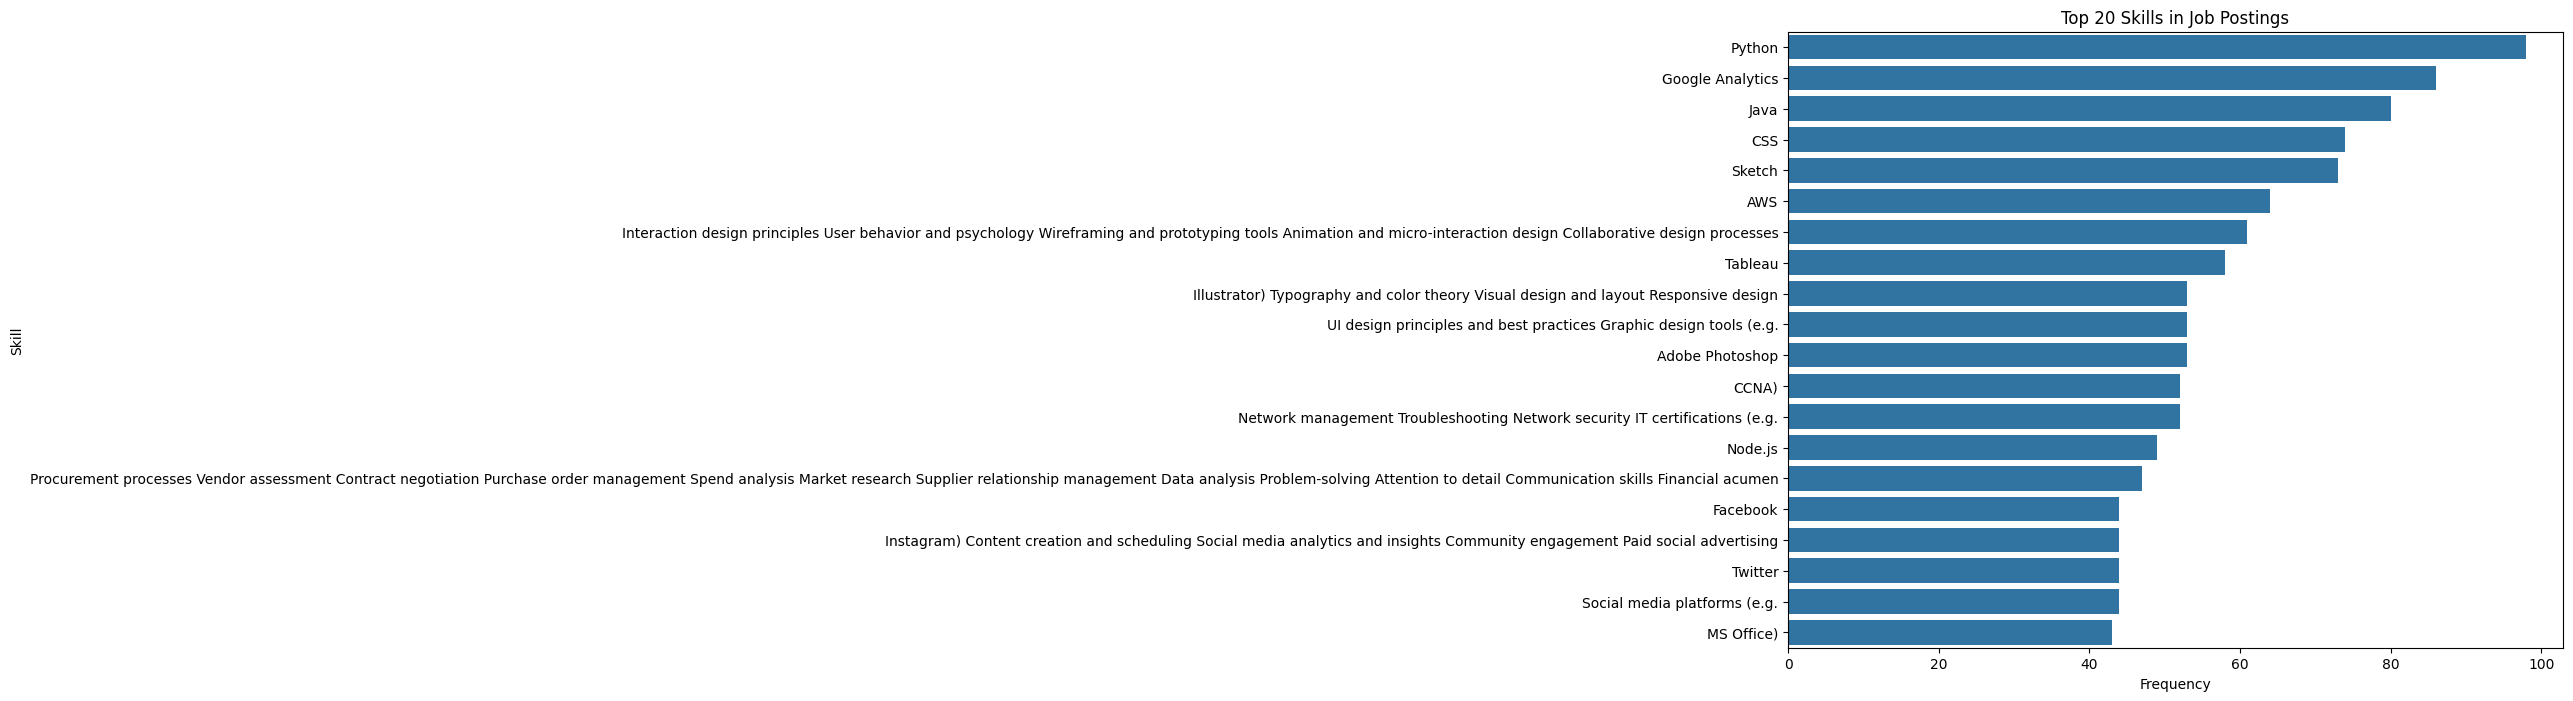

In [ ]:
top_skills = skill_frequency.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_skills,
    x="frequency",
    y="skill"
)

plt.title("Top 20 Skills in Job Postings")
plt.xlabel("Frequency")
plt.ylabel("Skill")

plt.show()

In [ ]:
#NUMBER OF SKILL PER JOb

df["skill_count"] = (
    df["skills_list"].str.len()
)

In [ ]:
df["skill_count"].describe()

,skill_count
count,5000.000000
mean,1.673400
std,1.324192
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,10.000000


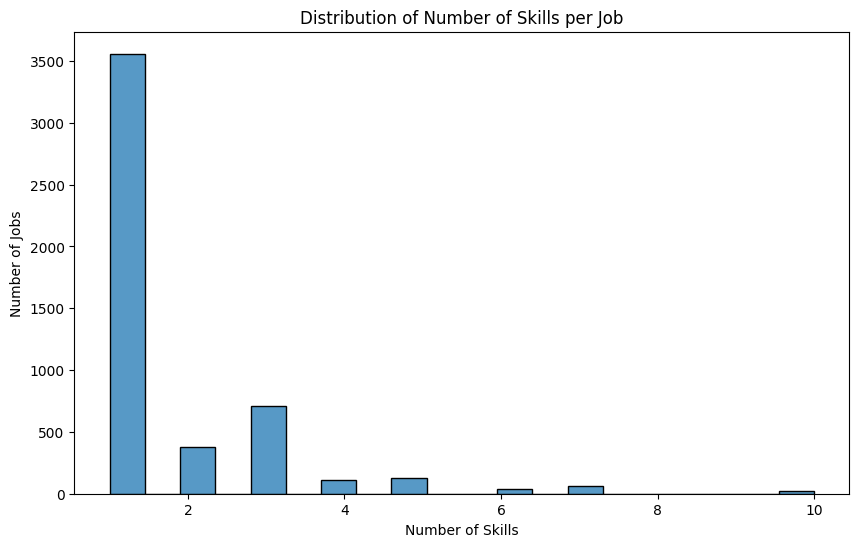

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="skill_count",
    bins=20
)

plt.title("Distribution of Number of Skills per Job")
plt.xlabel("Number of Skills")
plt.ylabel("Number of Jobs")

plt.show()

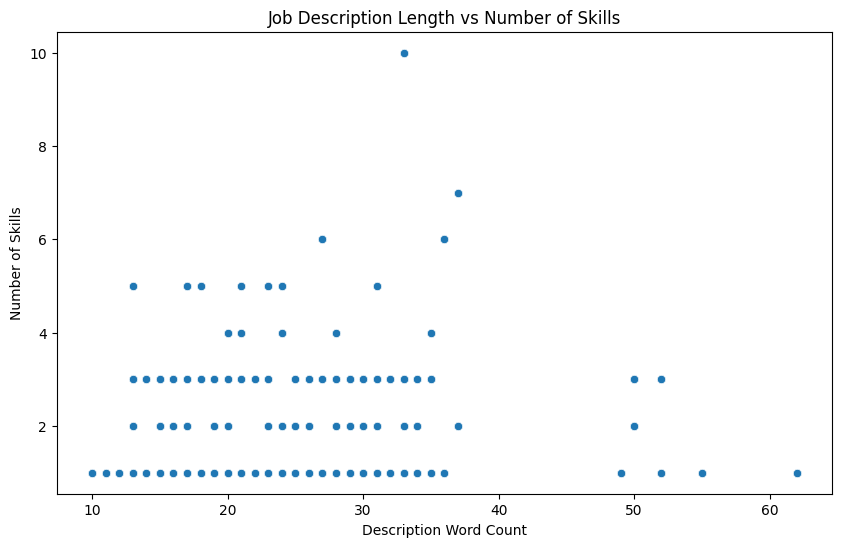

In [ ]:
#SKILLS VS JOB DESCRIPTION LENGTH
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="description_word_count",
    y="skill_count"
)

plt.title("Job Description Length vs Number of Skills")
plt.xlabel("Description Word Count")
plt.ylabel("Number of Skills")

plt.show()


In [ ]:
df[
    [
        "description_word_count",
        "skill_count"
    ]
].corr()

,description_word_count,skill_count
description_word_count,1.000000,0.174913
skill_count,0.174913,1.000000


In [ ]:
#SKILLS BY JOB ROLE
role_skill_counts = (
    df.explode("skills_list")
      .groupby("role")["skills_list"]
      .count()
      .sort_values(ascending=False)
)

role_skill_counts.head(15)

,skills_list
role,
Backend Developer,280
DevOps Engineer,210
Social Media Manager,176
User Interface Designer,159
Frontend Developer,156
Database Administrator,148
Data Scientist,140
Content Creator,120
User Experience Designer,120


In [ ]:
#TOP SKILL WITH EACH ROLE

df.explode("skills_list").groupby(
    ["role", "skills_list"]
).size().sort_values(
    ascending=False
).head(30)

role                      skills_list                                                                                                                                                                                                                                   
Interaction Designer      Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes                                                                                61
User Interface Designer   Illustrator) Typography and color theory Visual design and layout Responsive design                                                                                                                                                               53
                          UI design principles and best practices Graphic design tools (e.g.                                                                                                                                                                                53
                          Adobe Photoshop                                                                                                                                                                                                                                   53
Network Administrator     CCNA)                                                                                                                                                                                                                                             52
                          Network management Troubleshooting Network security IT certifications (e.g.                                                                                                                                                                       52
Procurement Analyst       Procurement processes Vendor assessment Contract negotiation Purchase order management Spend analysis Market research Supplier relationship management Data analysis Problem-solving Attention to detail Communication skills Financial acumen    47
Social Media Manager      Social media platforms (e.g.                                                                                                                                                                                                                      44
                          Twitter                                                                                                                                                                                                                                           44
                          Facebook                                                                                                                                                                                                                                          44
                          Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising                                                                                                                       44
Backend Developer         Ruby) API development Database management (SQL or NoSQL) Server management and deployment Security best practices Knowledge of web frameworks (e.g.                                                                                               40
                          Python                                                                                                                                                                                                                                            40
                          Proficiency in one or more backend programming languages (e.g.                                                                                                                            

In [ ]:
df.to_csv(
    "job_dataset_eda_5k.csv",
    index=False
)

print("Saved: job_dataset_eda_5k.csv")


Saved: job_dataset_eda_5k.csv


In [ ]:
print(df[["job_description", "skills"]].head())

                                                                                                                                                                                           job_description                                                                                                                                                                                                   skills
0  Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...                             Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising
1  Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to 

In [ ]:
#creating Normalize Text
import re
import pandas as pd

def parse_skills(value):

    if pd.isna(value):
        return []

    value = str(value).strip()

    # Handle list-like strings
    if value.startswith("[") and value.endswith("]"):
        try:
            import ast
            parsed = ast.literal_eval(value)

            if isinstance(parsed, list):
                return [
                    str(skill).strip()
                    for skill in parsed
                    if str(skill).strip()
                ]
        except:
            pass

    # Normalize line breaks
    value = value.replace("\r\n", "\n")
    value = value.replace("\r", "\n")

    # Split primarily by newline
    skills = re.split(r"\n+", value)

    return [
        skill.strip()
        for skill in skills
        if skill.strip()
    ]

#
def normalize_text(text):
    text = str(text).lower()

    # Normalize common symbols
    text = text.replace("&", " and ")

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep letters, numbers, #, +, ., -
    text = re.sub(r"[^a-z0-9+#.\-]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
text = "Python, PANDAS & SQL!"

print(normalize_text(text))

python pandas and sql


In [ ]:
#Normalize job description
df["description_normalized"] = (
    df["job_description"]
    .fillna("")
    .apply(normalize_text)
)

In [ ]:
df[
    ["job_description", "description_normalized"]
].head()

,job_description,description_normalized
0,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...",social media managers oversee an organizations social media presence. they create and schedule content engage with followers and analyze social media metrics to drive brand awareness and engagement.
1,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create ...",frontend web developers design and implement user interfaces for websites ensuring they are visually appealing and user-friendly. they collaborate with designers and backend developers to create s...
2,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain p...",quality control managers establish and enforce quality standards within an organization. they develop quality control processes perform inspections and implement corrective actions to maintain pro...
3,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communicati...",wireless network engineers design implement and maintain wireless network solutions. they optimize wireless connectivity troubleshoot issues and ensure reliable and secure wireless communications.
4,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to t...",a conference manager coordinates and manages conferences meetings and events. they plan logistics handle budgeting liaise with vendors and ensure the smooth execution of events catering to the nee...


In [ ]:
df["skills_list"]

,skills_list
0,"[Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising]"
1,"[HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)]"
2,"[Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowl..."
3,[Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues]
4,[Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations]
...,...
4995,"[Proficiency in one or more backend programming languages (e.g., Java, Python, Node.js, Ruby) API development Database management (SQL or NoSQL) Server management and deployment Security best prac..."
4996,[Frontend web development HTML/CSS Responsive design User interface (UI) design Adobe Creative Suite Collaboration skills]
4997,[Creative writing Copywriting Advertising copy Content creation Brand storytelling Marketing campaigns Proofreading and editing]
4998,"[Transportation engineering Traffic analysis and planning Civil engineering software (e.g., MicroStation, AutoCAD Civil 3D) Roadway design Public transportation knowledge]"


In [ ]:
df["skills_normalized"] = df["skills_list"].apply(
    lambda skills: [
        normalize_text(skill)
        for skill in skills
        if str(skill).strip()
    ]
)

In [ ]:
df[["skills_list", "skills_normalized"]].head()

,skills_list,skills_normalized
0,"[Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising]","[social media platforms e.g., facebook, twitter, instagram content creation and scheduling social media analytics and insights community engagement paid social advertising]"
1,"[HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)]","[html, css, javascript frontend frameworks e.g., react, angular user experience ux]"
2,"[Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowl...","[quality control processes and methodologies statistical process control spc root cause analysis and corrective action quality management systems e.g., iso 9001 compliance and regulatory knowledge]"
3,[Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues],[wireless network design and architecture wi-fi standards and protocols rf radio frequency planning and optimization wireless security protocols troubleshooting wireless network issues]
4,[Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations],[event planning conference logistics budget management vendor coordination marketing and promotion client relations]


In [ ]:
#Checking where each skills appear in JD
def find_skill_matches(description, skills):
    matched = []
    not_matched = []

    for skill in skills:
        if skill in description:
            matched.append(skill)
        else:
            not_matched.append(skill)

    return matched, not_matched

In [ ]:
description = "we are looking for a python developer with sql and aws experience"

skills = ["python", "sql", "aws", "docker"]

find_skill_matches(description, skills)

(['python', 'sql', 'aws'], ['docker'])

In [ ]:
# Applying skill matching to the 5K dataset
# This is kept for comparison/EDA; the taxonomy extractor later is optimized.
results = df.apply(
    lambda row: find_skill_matches(
        row['description_normalized'],
        row['skills_normalized']
    ),
    axis=1
)


In [ ]:
df["matched_skills"] = results.apply(lambda x: x[0])

df["unmatched_skills"] = results.apply(lambda x: x[1]) #Creating two columns matched vs unmatched

In [ ]:
df[
    [
        "job_title",
        "skills_list",
        "matched_skills",
        "unmatched_skills"
    ]
].head(10)

,job_title,skills_list,matched_skills,unmatched_skills
0,Digital Marketing Specialist,"[Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising]",[],"[social media platforms e.g., facebook, twitter, instagram content creation and scheduling social media analytics and insights community engagement paid social advertising]"
1,Web Developer,"[HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)]",[],"[html, css, javascript frontend frameworks e.g., react, angular user experience ux]"
2,Operations Manager,"[Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowl...",[],"[quality control processes and methodologies statistical process control spc root cause analysis and corrective action quality management systems e.g., iso 9001 compliance and regulatory knowledge]"
3,Network Engineer,[Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues],[],[wireless network design and architecture wi-fi standards and protocols rf radio frequency planning and optimization wireless security protocols troubleshooting wireless network issues]
4,Event Manager,[Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations],[],[event planning conference logistics budget management vendor coordination marketing and promotion client relations]
5,Software Tester,"[Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing]",[],"[quality assurance processes testing methodologies e.g., manual, automated bug tracking and reporting test case development regression testing]"
6,Teacher,[Teaching pedagogy Classroom management Curriculum development Student assessment Differentiated instruction],[],[teaching pedagogy classroom management curriculum development student assessment differentiated instruction]
7,UX/UI Designer,"[UI design principles and best practices Graphic design tools (e.g., Adobe Photoshop, Illustrator) Typography and color theory Visual design and layout Responsive design]",[],"[ui design principles and best practices graphic design tools e.g., adobe photoshop, illustrator typography and color theory visual design and layout responsive design]"
8,UX/UI Designer,[Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes],[],[interaction design principles user behavior and psychology wireframing and prototyping tools animation and micro-interaction design collaborative design processes]
9,Wedding Planner,[Wedding planning Vendor coordination Event management],[],[wedding planning vendor coordination event management]


In [ ]:
#Calculating Matched column
df["matched_skill_count"] = (
    df["matched_skills"].str.len()
)

df["total_skill_count"] = (
    df["skills_normalized"].str.len()
)

In [ ]:
df["skill_match_percentage"] = np.where(
    df["total_skill_count"] > 0,
    (
        df["matched_skill_count"]
        / df["total_skill_count"]
    ) * 100,
    0
)

In [ ]:
df[
    [
        "job_title",
        "total_skill_count",
        "matched_skill_count",
        "skill_match_percentage"
    ]
].head(2000)

,job_title,total_skill_count,matched_skill_count,skill_match_percentage
0,Digital Marketing Specialist,4,0,0.0
1,Web Developer,5,0,0.0
2,Operations Manager,2,0,0.0
3,Network Engineer,1,0,0.0
4,Event Manager,1,0,0.0
...,...,...,...,...
1995,Sales Consultant,1,0,0.0
1996,Registered Nurse,3,0,0.0
1997,Brand Manager,3,0,0.0
1998,Front-End Engineer,1,0,0.0


In [ ]:
overall_match = df[
    "skill_match_percentage"
].mean()

print(
    f"Average Skill Match: {overall_match:.2f}%"
)

Average Skill Match: 0.27%


In [ ]:
print("JOB DESCRIPTION:")
print(df["job_description"].iloc[0])

print("\nSKILLS:")
print(df["skills"].iloc[0])

print("\nSKILLS LIST:")
print(df["skills_list"].iloc[0])

print("\nNORMALIZED DESCRIPTION:")
print(df["description_normalized"].iloc[0])

print("\nNORMALIZED SKILLS:")
print(df["skills_normalized"].iloc[0])

JOB DESCRIPTION:
Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.

SKILLS:
Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising

SKILLS LIST:
['Social media platforms (e.g.', 'Facebook', 'Twitter', 'Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising']

NORMALIZED DESCRIPTION:
social media managers oversee an organizations social media presence. they create and schedule content engage with followers and analyze social media metrics to drive brand awareness and engagement.

NORMALIZED SKILLS:
['social media platforms e.g.', 'facebook', 'twitter', 'instagram content creation and scheduling social media analytics and insights community engagement paid

In [ ]:
print(type(df["skills"].iloc[0]))
print(type(df["skills_list"].iloc[0]))

<class 'str'>
<class 'list'>


In [ ]:
import re
import pandas as pd

def parse_skills(value):

    if pd.isna(value):
        return []

    value = str(value).strip()

    # Remove accidental list brackets if present
    value = value.strip("[]")

    # Handle the known skill pattern in this dataset.
    # Skills are separated by spaces but individual skills
    # are multi-word phrases.

    known_patterns = [
        r"Social media platforms \(e\.g\.,? Facebook, Twitter, Instagram\)",
        r"Content creation and scheduling",
        r"Social media analytics and insights",
        r"Community engagement",
        r"Paid social advertising"
    ]

    skills = []

    for pattern in known_patterns:
        match = re.search(
            pattern,
            value,
            flags=re.IGNORECASE
        )

        if match:
            skills.append(match.group().strip())

    return skills

In [ ]:
df["skills_list"] = df["skills"].apply(parse_skills)

In [ ]:
print(df["skills_list"].iloc[0])

['Social media platforms (e.g., Facebook, Twitter, Instagram)', 'Content creation and scheduling', 'Social media analytics and insights', 'Community engagement', 'Paid social advertising']


In [ ]:
print(repr(df["skills"].iloc[0]))

'Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising'


In [ ]:
print(df["skills"].iloc[0].replace("\n", "\\n"))

Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising


In [ ]:
for i in range(10):
    print(f"\nROW {i}")
    print(repr(df["skills"].iloc[i]))


ROW 0
'Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising'

ROW 1
'HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)'

ROW 2
'Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge'

ROW 3
'Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues'

ROW 4
'Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations'

ROW 5
'Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing'

ROW 6
'Teaching pedagogy Classroom manage

In [ ]:
df["skills_text"] = (
    df["skills"]
    .fillna("")
    .astype(str)
    .str.strip()
)

In [ ]:
df[["job_title", "skills_text"]].head(10)

,job_title,skills_text
0,Digital Marketing Specialist,"Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising"
1,Web Developer,"HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)"
2,Operations Manager,"Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge"
3,Network Engineer,Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues
4,Event Manager,Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations
5,Software Tester,"Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing"
6,Teacher,Teaching pedagogy Classroom management Curriculum development Student assessment Differentiated instruction
7,UX/UI Designer,"UI design principles and best practices Graphic design tools (e.g., Adobe Photoshop, Illustrator) Typography and color theory Visual design and layout Responsive design"
8,UX/UI Designer,Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes
9,Wedding Planner,Wedding planning Vendor coordination Event management


In [ ]:
df["skills_char_count"] = df["skills_text"].str.len()

df["skills_word_count"] = (
    df["skills_text"]
    .str.split()
    .str.len()
)

In [ ]:
df[
    [
        "skills_char_count",
        "skills_word_count"
    ]
].describe()

,skills_char_count,skills_word_count
count,5000.000000,5000.000000
mean,139.272800,16.128200
std,59.196595,7.137868
min,49.000000,6.000000
25%,92.000000,10.000000
50%,125.000000,14.000000
75%,172.000000,21.000000
max,300.000000,35.000000


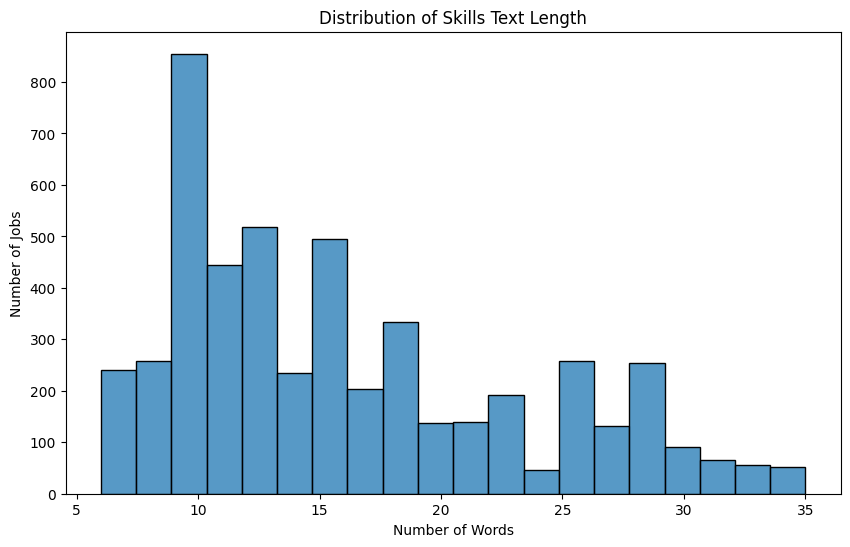

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="skills_word_count",
    bins=20
)

plt.title("Distribution of Skills Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Jobs")

plt.show()

In [ ]:
df["skills_to_description_ratio"] = np.where(
    df["description_word_count"] > 0,
    df["skills_word_count"] /
    df["description_word_count"],
    0
)

In [ ]:
df["skills_to_description_ratio"].describe()

,skills_to_description_ratio
count,5000.000000
mean,0.735810
std,0.470373
min,0.225806
25%,0.454545
50%,0.571429
75%,0.800000
max,2.500000


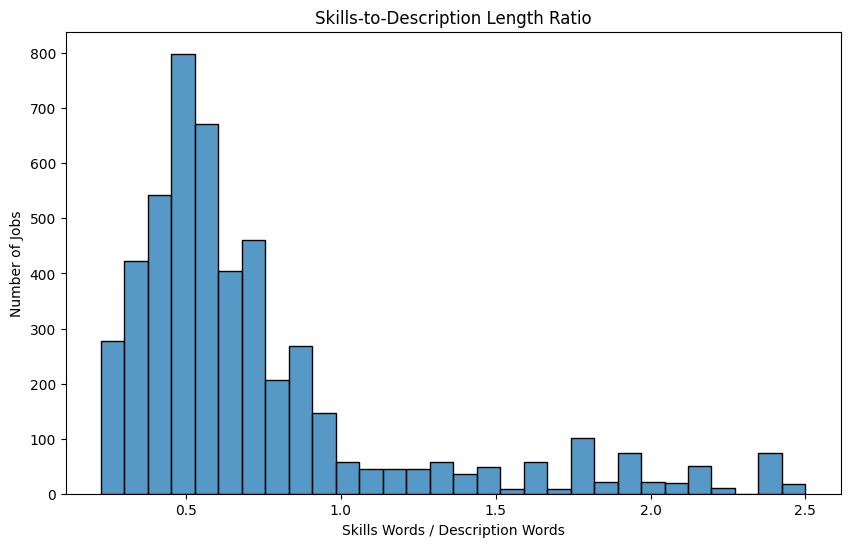

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="skills_to_description_ratio",
    bins=30
)

plt.title("Skills-to-Description Length Ratio")
plt.xlabel("Skills Words / Description Words")
plt.ylabel("Number of Jobs")

plt.show()

In [ ]:
# ============================================================
# JOB SKILL TAXONOMY + SYNONYMS / ALIASES
# ============================================================
skill_taxonomy = {

    # ============================================================
    # 1. PROGRAMMING
    # ============================================================
    "Programming": {

        "Python": [
            "python",
            "python programming",
            "python development",
            "python scripting",
            "python language"
        ],

        "Java": [
            "java",
            "java programming",
            "java development",
            "java language"
        ],

        "C": [
            "c",
            "c programming",
            "c language"
        ],

        "C++": [
            "c++",
            "cpp",
            "c plus plus",
            "c++ programming"
        ],

        "C#": [
            "c#",
            "c sharp",
            "csharp",
            "c# programming"
        ],

        "JavaScript": [
            "javascript",
            "java script",
            "js",
            "javascript programming"
        ],

        "TypeScript": [
            "typescript",
            "type script",
            "ts"
        ],

        "Go": [
            "go",
            "golang",
            "go programming",
            "go language"
        ],

        "Rust": [
            "rust",
            "rust programming",
            "rust language"
        ],

        "PHP": [
            "php",
            "php programming",
            "php development"
        ],

        "Ruby": [
            "ruby",
            "ruby programming",
            "ruby development"
        ],

        "Kotlin": [
            "kotlin",
            "kotlin programming",
            "kotlin development"
        ],

        "Swift": [
            "swift",
            "swift programming",
            "swift development"
        ],

        "R": [
            "r",
            "r programming",
            "r language"
        ],

        "Scala": [
            "scala",
            "scala programming",
            "scala language"
        ],

        "MATLAB": [
            "matlab",
            "mat lab"
        ],

        "Dart": [
            "dart",
            "dart programming"
        ],

        "Perl": [
            "perl",
            "perl programming"
        ]
    },


    # ============================================================
    # 2. DATABASE
    # ============================================================
    "Database": {

        "SQL": [
            "sql",
            "structured query language",
            "sql programming",
            "sql queries",
            "sql database"
        ],

        "MySQL": [
            "mysql",
            "mysql database",
            "mysql server"
        ],

        "PostgreSQL": [
            "postgresql",
            "postgres",
            "postgres db",
            "postgres database"
        ],

        "SQL Server": [
            "sql server",
            "microsoft sql server",
            "mssql",
            "ms sql"
        ],

        "Oracle": [
            "oracle",
            "oracle database",
            "oracle db"
        ],

        "MongoDB": [
            "mongodb",
            "mongo",
            "mongo db"
        ],

        "Redis": [
            "redis",
            "redis database",
            "redis cache"
        ],

        "Cassandra": [
            "cassandra",
            "apache cassandra"
        ],

        "DynamoDB": [
            "dynamodb",
            "dynamo db",
            "amazon dynamodb"
        ],

        "SQLite": [
            "sqlite",
            "sqlite3"
        ],

        "MariaDB": [
            "mariadb",
            "maria db"
        ],

        "NoSQL": [
            "nosql",
            "no sql",
            "non relational database",
            "non-relational database"
        ],

        "Microsoft Access": [
            "microsoft access",
            "ms access",
            "access database"
        ],

        "Firebase": [
            "firebase",
            "firebase database",
            "firestore"
        ]
    },


    # ============================================================
    # 3. MACHINE LEARNING
    # ============================================================
    "Machine Learning": {

        "Machine Learning": [
            "machine learning",
            "machine-learning",
            "ml",
            "machine learning algorithms"
        ],

        "Supervised Learning": [
            "supervised learning",
            "supervised machine learning"
        ],

        "Unsupervised Learning": [
            "unsupervised learning",
            "unsupervised machine learning"
        ],

        "Deep Learning": [
            "deep learning",
            "deep-learning",
            "dl"
        ],

        "Scikit-learn": [
            "scikit-learn",
            "sklearn",
            "scikit learn"
        ],

        "TensorFlow": [
            "tensorflow",
            "tensor flow"
        ],

        "Keras": [
            "keras",
            "tensorflow keras",
            "tf keras"
        ],

        "PyTorch": [
            "pytorch",
            "py torch"
        ],

        "XGBoost": [
            "xgboost",
            "xg boost"
        ],

        "LightGBM": [
            "lightgbm",
            "light gbm"
        ],

        "CatBoost": [
            "catboost",
            "cat boost"
        ],

        "Regression": [
            "regression",
            "linear regression",
            "logistic regression",
            "regression analysis"
        ],

        "Classification": [
            "classification",
            "classification algorithms",
            "classification modeling"
        ],

        "Clustering": [
            "clustering",
            "cluster analysis",
            "clustering algorithms"
        ],

        "Natural Language Processing": [
            "natural language processing",
            "natural language processing nlp",
            "nlp",
            "text processing"
        ],

        "Computer Vision": [
            "computer vision",
            "cv",
            "image processing",
            "image recognition"
        ],

        "Reinforcement Learning": [
            "reinforcement learning",
            "rl"
        ],

        "Time Series": [
            "time series",
            "time series analysis",
            "time series forecasting"
        ]
    },


    # ============================================================
    # 4. ARTIFICIAL INTELLIGENCE / GENERATIVE AI
    # ============================================================
    "Artificial Intelligence": {

        "Artificial Intelligence": [
            "artificial intelligence",
            "artificial intelligence ai",
            "ai",
            "ai technology"
        ],

        "Generative AI": [
            "generative ai",
            "gen ai",
            "genai",
            "generative artificial intelligence"
        ],

        "Large Language Models": [
            "large language models",
            "large language model",
            "llm",
            "llms"
        ],

        "OpenAI": [
            "openai",
            "openai api",
            "open ai"
        ],

        "GPT": [
            "gpt",
            "gpt models",
            "gpt-4",
            "gpt-4o",
            "gpt-5"
        ],

        "Prompt Engineering": [
            "prompt engineering",
            "prompt design",
            "prompting"
        ],

        "RAG": [
            "rag",
            "retrieval augmented generation",
            "retrieval-augmented generation"
        ],

        "LangChain": [
            "langchain",
            "lang chain"
        ],

        "LangGraph": [
            "langgraph",
            "lang graph"
        ],

        "Vector Database": [
            "vector database",
            "vector databases",
            "vector db",
            "vector store",
            "vector stores"
        ],

        "FAISS": [
            "faiss",
            "facebook ai similarity search"
        ],

        "ChromaDB": [
            "chromadb",
            "chroma db",
            "chroma"
        ],

        "AI Agents": [
            "ai agents",
            "ai agent",
            "intelligent agents",
            "agentic ai",
            "agentic artificial intelligence"
        ]
    },


    # ============================================================
    # 5. CLOUD
    # ============================================================
    "Cloud": {

        "AWS": [
            "aws",
            "amazon web services",
            "amazon aws"
        ],

        "Microsoft Azure": [
            "azure",
            "microsoft azure",
            "azure cloud"
        ],

        "Google Cloud": [
            "google cloud",
            "google cloud platform",
            "gcp"
        ],

        "AWS EC2": [
            "ec2",
            "amazon ec2",
            "aws ec2"
        ],

        "AWS S3": [
            "s3",
            "amazon s3",
            "aws s3",
            "simple storage service"
        ],

        "AWS Lambda": [
            "lambda",
            "aws lambda",
            "amazon lambda"
        ],

        "AWS Glue": [
            "aws glue",
            "amazon glue",
            "glue"
        ],

        "AWS RDS": [
            "rds",
            "aws rds",
            "amazon rds"
        ],

        "AWS Redshift": [
            "redshift",
            "aws redshift",
            "amazon redshift"
        ],

        "Azure Data Factory": [
            "azure data factory",
            "adf"
        ],

        "Google BigQuery": [
            "bigquery",
            "google bigquery",
            "big query"
        ]
    },


    # ============================================================
    # 6. DATA ANALYTICS
    # ============================================================
    "Data Analytics": {

        "Data Analysis": [
              "data analysis",
              "data analytics",
              "data analyst",
              "data analysts",
              "business intelligence analyst",
              "business intelligence analysts",
              "analyze data",
              "analyzing data",
              "data analysis skills"
],

        "Exploratory Data Analysis": [
            "exploratory data analysis",
            "exploratory analysis",
            "eda"
        ],

        "Data Cleaning": [
            "data cleaning",
            "data cleansing",
            "data preprocessing",
            "data preparation"
        ],

        "Data Visualization": [
               "data visualization",
               "data visualisation",
               "data visualizations",
               "data visualisations",
               "data viz",
               "data visualization techniques",
               "visualize data",
              "data visualization tools"
],

        "Statistical Analysis": [
            "statistical analysis",
            "statistics",
            "statistical modeling"
        ],

        "Hypothesis Testing": [
            "hypothesis testing",
            "statistical hypothesis testing"
        ],

        "A/B Testing": [
            "a/b testing",
            "ab testing",
            "split testing",
            "a b testing"
        ],

        "Data Storytelling": [
            "data storytelling",
            "data story",
            "data-driven storytelling"
        ],

        "Ad Hoc Analysis": [
            "ad hoc analysis",
            "ad-hoc analysis",
            "adhoc analysis"
        ]
    },


    # ============================================================
    # 7. DATA ENGINEERING
    # ============================================================
    "Data Engineering": {

        "Data Architecture": [
              "data architecture",
              "data architect",
              "data infrastructure",
              "data infrastructure design"
          ],

         "Big Data": [
              "big data",
               "big data engineering",
               "big data solutions",
               "big data platforms"
        ],

        "ETL": [
            "etl",
            "extract transform load",
            "extract-transform-load"
        ],

        "ELT": [
            "elt",
            "extract load transform"
        ],

        "Data Pipeline": [
            "data pipeline",
            "data pipelines",
            "data pipeline development"
        ],

        "Apache Spark": [
            "apache spark",
            "spark",
            "spark sql"
        ],

        "PySpark": [
            "pyspark",
            "python spark",
            "py spark"
        ],

        "Apache Kafka": [
            "apache kafka",
            "kafka",
            "kafka streaming"
        ],

        "Apache Airflow": [
            "apache airflow",
            "airflow",
            "workflow orchestration"
        ],

        "Databricks": [
            "databricks",
            "databricks platform"
        ],

        "Delta Lake": [
            "delta lake",
            "delta tables",
            "delta"
        ],

        "Hadoop": [
            "hadoop",
            "apache hadoop"
        ],

        "Hive": [
            "hive",
            "apache hive",
            "hive sql"
        ],

        "Parquet": [
            "parquet",
            "apache parquet"
        ]
    },


    # ============================================================
    # 8. BUSINESS INTELLIGENCE
    # ============================================================
    "Business Intelligence": {

        "Power BI": [
            "power bi",
            "powerbi",
            "microsoft power bi"
        ],

        "Tableau": [
            "tableau",
            "tableau desktop",
            "tableau server"
        ],

        "QlikView": [
            "qlikview",
            "qlik view"
        ],

        "Qlik Sense": [
            "qlik sense",
            "qliksense"
        ],

        "Looker": [
            "looker",
            "google looker"
        ],

        "DAX": [
            "dax",
            "data analysis expressions"
        ],

        "Power Query": [
            "power query",
            "powerquery",
            "m language"
        ],

        "Dashboard Development": [
            "dashboard development",
            "dashboard creation",
            "dashboard design",
            "business dashboards"
        ]
    },


    # ============================================================
    # 9. EXCEL / OFFICE
    # ============================================================
    "Excel & Office": {

        "Microsoft Excel": [
            "excel",
            "microsoft excel",
            "ms excel",
            "advanced excel"
        ],

        "Excel VBA": [
            "excel vba",
            "vba",
            "visual basic for applications"
        ],

        "Pivot Tables": [
            "pivot tables",
            "pivot table"
        ],

        "Excel Formulas": [
            "excel formulas",
            "excel functions",
            "advanced excel formulas"
        ],

        "Microsoft PowerPoint": [
            "powerpoint",
            "microsoft powerpoint",
            "ms powerpoint"
        ],

        "Microsoft Word": [
            "word",
            "microsoft word",
            "ms word"
        ]
    },


    # ============================================================
    # 10. WEB DEVELOPMENT
    # ============================================================
    "Web Development": {



        "Web Development": [
            "web development",
            "web developer",
            "web developers",
            "frontend web development",
            "frontend development",
            "backend development",
            "full stack development",
            "full-stack development"
    ],

        "HTML": [
            "html",
            "html5",
            "hypertext markup language"
        ],

        "CSS": [
            "css",
            "css3",
            "cascading style sheets"
        ],

        "React": [
            "react",
            "react.js",
            "reactjs"
        ],

        "Angular": [
            "angular",
            "angular.js",
            "angularjs"
        ],

        "Vue.js": [
            "vue",
            "vue.js",
            "vuejs"
        ],

        "Node.js": [
            "node",
            "node.js",
            "nodejs"
        ],

        "Express.js": [
            "express",
            "express.js",
            "expressjs"
        ],

        "Django": [
            "django",
            "django framework"
        ],

        "Flask": [
            "flask",
            "flask framework"
        ],

        "FastAPI": [
            "fastapi",
            "fast api"
        ],

        "REST API": [
            "rest api",
            "restful api",
            "restful apis",
            "rest services"
        ],

        "GraphQL": [
            "graphql",
            "graph ql"
        ],

        "Bootstrap": [
            "bootstrap",
            "bootstrap css"
        ],

        "Tailwind CSS": [
            "tailwind",
            "tailwind css",
            "tailwindcss"
        ]
    },


    # ============================================================
    # 11. MOBILE DEVELOPMENT
    # ============================================================
    "Mobile Development": {


        "Mobile Applications": [
                "mobile application",
                "mobile applications",
                "mobile app",
                "mobile apps",
                "mobile application development",
                "mobile app development"
          ],
        "Android": [
            "android",
            "android development",
            "android sdk"
        ],

        "iOS": [
            "ios",
            "ios development",
            "iphone development"
        ],

        "React Native": [
            "react native",
            "react-native"
        ],

        "Flutter": [
            "flutter",
            "flutter development"
        ],

        "Android Studio": [
            "android studio"
        ]
    },


    # ============================================================
    # 12. DEVOPS
    # ============================================================
    "DevOps": {

        "DevOps": [
            "devops",
            "dev ops",
            "development operations"
        ],

        "Git": [
            "git",
            "git version control",
            "version control"
        ],

        "GitHub": [
            "github",
            "github actions",
            "github workflows"
        ],

        "GitLab": [
            "gitlab",
            "gitlab ci"
        ],

        "Docker": [
            "docker",
            "docker containers",
            "containerization",
            "containerisation"
        ],

        "Kubernetes": [
            "kubernetes",
            "k8s",
            "container orchestration"
        ],

        "Jenkins": [
            "jenkins",
            "jenkins ci"
        ],

        "Terraform": [
            "terraform",
            "hashicorp terraform",
            "infrastructure as code"
        ],

        "Ansible": [
            "ansible",
            "ansible automation"
        ],

        "ArgoCD": [
            "argocd",
            "argo cd",
            "argo"
        ],

        "CI/CD": [
            "ci/cd",
            "cicd",
            "continuous integration",
            "continuous delivery",
            "continuous deployment"
        ],

        "Linux": [
            "linux",
            "linux administration",
            "linux operating system"
        ],

        "Bash": [
            "bash",
            "bash scripting",
            "shell scripting"
        ]
    },


    # ============================================================
    # 13. DATA SCIENCE
    # ============================================================
    "Data Science": {

        "Data Science": [
            "data science",
            "data scientist",
            "data science methods"
        ],

        "NumPy": [
            "numpy",
            "num py"
        ],

        "Pandas": [
            "pandas",
            "python pandas"
        ],

        "Matplotlib": [
            "matplotlib",
            "mat plot lib"
        ],

        "Seaborn": [
            "seaborn",
            "sea born"
        ],

        "SciPy": [
            "scipy",
            "sci py"
        ],

        "Jupyter": [
            "jupyter",
            "jupyter notebook",
            "jupyter notebooks"
        ]
    },


    # ============================================================
    # 14. DIGITAL MARKETING
    # ============================================================
    "Digital Marketing": {

        "Social Media": [
            "social media",
            "social media management",
            "social media marketing",
            "social media platforms",
            "social media strategy",
            "social media analytics",
            "social media advertising",
            "social networking",
            "social media management skills"
        ],

        "Content Marketing": [
            "content marketing",
            "content creation",
            "content strategy",
            "content development",
            "content management",
            "content marketing strategy"
        ],

        "Content Writing": [
            "content writing",
            "content writer",
            "content writers",
            "content creation",
             "written content",
             "web content",
              "web content writing",
              "copywriting",
               "copy writer",
               "copy writing",
               "creative writing",
             "article writing",
             "blog writing"
],
        "Technical Writing": [
            "technical writing",
             "technical writer",
              "technical writers",
             "technical documentation",
             "technical documents",
             "documentation writing"
],

        "SEO": [
            "seo",
            "search engine optimization",
            "search engine optimisation",
            "seo optimization",
            "seo optimisation"
        ],

        "SEM": [
            "sem",
            "search engine marketing",
            "search marketing"
        ],

        "Google Ads": [
            "google ads",
            "google adwords",
            "adwords"
        ],

        "Digital Advertising": [
            "digital advertising",
            "online advertising",
            "internet advertising",
            "paid advertising",
            "paid media"
        ],

        "Paid Social Advertising": [
            "paid social",
            "paid social advertising",
            "social advertising",
            "social media ads"
        ],

        "Email Marketing": [
            "email marketing",
            "email campaigns",
            "email campaign management",
            "email automation",
            "email marketing automation",
            "email marketing automation",
            "email deliverability",
            "email delivery",
            "email delivery rates",
            "email list",
            "email list management",
            "email marketing specialist"

        ],

        "Influencer Marketing": [
            "influencer marketing",
            "influencer management",
            "influencer campaigns"
        ],

        "Affiliate Marketing": [
            "affiliate marketing",
            "affiliate management",
            "affiliate programs"
        ],

        "Google Analytics": [
            "google analytics",
            "ga4",
            "google analytics 4",
            "google analytics 4"
        ],

        "Marketing Analytics": [
            "marketing analytics",
            "marketing analysis",
            "digital marketing analytics"
        ],

        "Brand Marketing": [
               "brand marketing",
                "brand management",
               "brand manager",
               "brand managers",
              "brand strategy",
               "brand identity",
               "brand identities",
               "brand awareness",
               "product branding",
              "product brand",
              "brand promotion"
],

        "Campaign Management": [
            "campaign management",
            "marketing campaign management",
            "campaign planning",
            "campaign execution",
            "campaign strategist",
            "campaign strategy",
            "campaign strategies"
        ],

        "Lead Generation": [
            "lead generation",
            "lead gen",
            "lead generation campaigns"
        ],

        "Customer Acquisition": [
            "customer acquisition",
            "user acquisition",
            "acquisition marketing"
        ],

        "Market Research": [
            "market research",
            "market analysis",
            "marketing research"
        ]

    },


    # ============================================================
    # 15. SALES
    # ============================================================
    "Sales": {

        "Sales": [
            "sales",
            "sales management",
            "sales operations"
        ],

        "Business Development": [
            "business development",
            "business development management",
            "bd"
        ],

        "Lead Generation": [
            "lead generation",
            "lead qualification",
            "prospecting"
        ],

        "Cold Calling": [
            "cold calling",
            "cold calling sales",
            "outbound calling"
        ],

        "Account Management": [
            "account management",
            "key account management",
            "account management skills"
        ],

        "CRM": [
            "crm",
            "customer relationship management",
            "crm management"
        ],

        "Salesforce": [
            "salesforce",
            "salesforce crm"
        ],

        "Negotiation": [
            "negotiation",
            "sales negotiation",
            "negotiation skills"
        ],
        "Account Management": [
            "account management",
            "key account management",
            "strategic account management",
            "account manager",
             "key account manager",
            "strategic account manager",
             "account executive",
             "account strategy",
             "client relationship management",
             "client relationships",
            "customer relationship management"
        ],

        "Strategic Partnerships": [
            "strategic partnerships",
            "strategic partnership",
            "partnership management",
            "partnership development",
            "partnerships and alliances",
            "strategic alliances"
        ],

        "Sales Strategy": [
            "sales strategy",
            "sales planning",
            "sales development"
        ]
    },


    # ============================================================
    # 16. PROJECT MANAGEMENT
    # ============================================================
    "Project Management": {

        "Project Management": [
            "project management",
            "project manager",
            "project planning"
        ],

        "Agile": [
            "agile",
            "agile methodology",
            "agile development"
        ],

        "Scrum": [
            "scrum",
            "scrum methodology",
            "scrum framework"
        ],

        "Kanban": [
            "kanban",
            "kanban methodology"
        ],

        "Jira": [
            "jira",
            "atlassian jira"
        ],

        "Confluence": [
            "confluence",
            "atlassian confluence"
        ],

        "Risk Management": [
            "risk management",
            "project risk management"
        ],

        "Stakeholder Management": [
            "stakeholder management",
            "stakeholder engagement"
        ]
    },


    # ============================================================
    # 17. CYBERSECURITY
    # ============================================================
    "Cybersecurity": {

        "Cybersecurity": [
            "cybersecurity",
            "cyber security",
            "information security",
            "infosec"
        ],

        "Network Security": [
            "network security",
            "network cybersecurity"
        ],

        "Application Security": [
            "application security",
            "app security"
        ],

        "Cloud Security": [
            "cloud security",
            "cloud cybersecurity"
        ],

        "Ethical Hacking": [
            "ethical hacking",
            "ethical hacker",
            "penetration testing",
            "penetration test",
            "pentesting"
        ],

        "Vulnerability Assessment": [
            "vulnerability assessment",
            "vulnerability scanning"
        ],

        "Firewall": [
            "firewall",
            "firewall administration",
            "firewall management"
        ],

        "SIEM": [
            "siem",
            "security information and event management"
        ],

        "Incident Response": [
            "incident response",
            "security incident response"
        ]
    },


    # ============================================================
    # 18. SOFTWARE ENGINEERING
    # ============================================================
    "Software Engineering": {

        "Software Development": [
            "software development",
            "software engineering",
            "software developer",
            "software developers",
            "software development lifecycle",
            "application development"
        ],

        "Object Oriented Programming": [
            "object oriented programming",
            "object-oriented programming",
            "oop"
        ],

        "Data Structures": [
            "data structures",
            "data structure"
        ],

        "Algorithms": [
            "algorithms",
            "algorithm development",
            "algorithm design"
        ],

        "System Design": [
            "system design",
            "software architecture",
            "system architecture"
        ],

        "Design Patterns": [
            "design patterns",
            "software design patterns"
        ],

        "Unit Testing": [
            "unit testing",
            "unit tests",
            "unit test"
        ],

        "Test Automation": [
            "test automation",
            "automated testing",
            "automation testing"
        ],

        "API Development": [
            "api development",
            "api design",
            "web api development"
        ],
        "Systems Integration": [
             "systems integration",
             "system integration",
             "systems integration specialist",
             "integration specialist",
             "software integration"
         ],

        "Backend Development": [
            "backend development",
             "back-end development",
            "backend developer",
             "back-end developer",
             "server-side development",
             "server side development",
              "server developer",
              "server-side applications"
]
    },


    # ============================================================
    # 19. UI/UX & DESIGN
    # ============================================================
    # ============================================================
# UI/UX & DESIGN
# ============================================================
"UI/UX Design": {

    "UI Design": [
        "ui design",
        "ui designer",
        "ui designers",
        "user interface design",
        "user interface designer",
        "user interface designers",
        "interface design",
        "interface designer",
        "interface designers",
        "digital interface design",
        "digital interfaces"
    ],

    "UX Design": [
        "ux design",
        "ux designer",
        "ux designers",
        "user experience design",
        "user experience designer",
        "user experience designers",
        "user experience",
        "user experiences",
        "user interactions",
        "user interaction design",
        "interaction design",
        "interaction designer",
        "interaction designers"
    ],

    "Visual Design": [
        "visual design",
        "visual designer",
        "visual designers",
        "visual aspects",
        "visual design principles"
    ],

    "Figma": [
        "figma",
        "figma design"
    ],

    "Adobe Photoshop": [
        "photoshop",
        "adobe photoshop"
    ],

    "Adobe Illustrator": [
        "illustrator",
        "adobe illustrator"
    ],

    "Wireframing": [
        "wireframing",
        "wireframes",
        "wireframe",
        "wireframe design"
    ],

    "Prototyping": [
        "prototyping",
        "prototype design",
        "ui prototyping",
        "prototypes"
    ],

    "Graphic Design": [
        "graphic design",
        "graphics design",
        "visual design"
    ],

    "Lighting Design": [
        "lighting design",
        "lighting designer",
        "lighting designers",
        "lighting plans",
        "lighting effects"
    ],

    "Art Curation": [
        "art curation",
        "art curator",
        "art curators",
        "curate exhibitions",
        "curating exhibitions",
        "exhibition curation"
    ]
},


    # ============================================================
    # 20. ERP / BUSINESS SOFTWARE
    # ============================================================
    "ERP & Business Software": {

        "SAP": [
            "sap",
            "sap erp",
            "sap systems"
        ],

        "SAP S/4HANA": [
            "s/4hana",
            "sap s/4hana",
            "s4hana"
        ],

        "Oracle ERP": [
            "oracle erp",
            "oracle enterprise resource planning"
        ],

        "Microsoft Dynamics": [
            "microsoft dynamics",
            "dynamics 365",
            "microsoft dynamics 365"
        ],

        "Workday": [
            "workday",
            "workday hcm"
        ]
    },


    # ============================================================
    # 21. HUMAN RESOURCES
    # ============================================================
    "Human Resources": {

        "Recruitment": [
            "recruitment",
            "recruiting",
            "talent acquisition"
        ],

        "Talent Management": [
            "talent management",
            "talent development"
        ],

        "Employee Relations": [
            "employee relations",
            "employee engagement"
        ],

        "HRIS": [
            "hris",
            "human resources information system",
            "human resource information system"
        ],

        "Payroll": [
            "payroll",
            "payroll management"
        ],

        "Performance Management": [
            "performance management",
            "employee performance management"
        ],

        "Onboarding": [
            "onboarding",
            "employee onboarding"
        ]
    },


    # ============================================================
    # 22. FINANCE & ACCOUNTING
    # ============================================================
    "Finance & Accounting": {

        "Accounting": [
            "accounting",
            "financial accounting"
        ],
        "Account Management": [
            "account management",
            "key account management",
            "strategic account management",
            "account manager",
            "key account manager",
            "strategic account manager",
            "account executive",
            "account strategy",
            "client relationship management",
            "client relationships",
            "customer relationship management"
       ],

        "Financial Analysis": [
            "financial analysis",
            "finance analysis"
        ],

        "Financial Modeling": [
            "financial modeling",
            "financial modelling"
        ],

        "Financial Reporting": [
            "financial reporting",
            "financial reports"
        ],

        "Budgeting": [
            "budgeting",
            "budget management",
            "budget planning"
        ],

        "Forecasting": [
            "forecasting",
            "financial forecasting"
        ],

        "Accounts Payable": [
            "accounts payable",
            "ap",
            "payables"
        ],

        "Accounts Receivable": [
            "accounts receivable",
            "ar",
            "receivables"
        ],

        "Auditing": [
            "auditing",
            "audit",
            "financial audit"
        ],

        "Tax Planning": [
            "tax planning",
            "tax strategy",
            "tax strategies",
            "tax planning strategies"
],

        "Taxation": [
            "taxation",
            "tax laws",
            "tax law",
            "tax regulations",
            "tax liabilities"
],

        "Financial Planning": [
           "financial planning",
          "financial planner",
           "financial planners",
           "personal financial planning",
           "financial advisory"
]
    },


    # ============================================================
    # 23. OPERATIONS
    # ============================================================
    "Operations": {

        "Operations Management": [
            "operations management",
            "operations",
            "business operations"
        ],

        "Supply Chain": [
            "supply chain",
            "supply chain management"
        ],

        "Procurement": [
            "procurement",
            "procurement management",
            "purchasing"
        ],

        "Inventory Management": [
            "inventory management",
            "inventory control"
        ],

        "Quality Control": [
            "quality control",
            "qc",
            "quality assurance"
        ],

        "Process Improvement": [
            "process improvement",
            "process optimization",
            "process optimisation"
        ],

        "Lean": [
            "lean",
            "lean management",
            "lean methodology"
        ],

        "Six Sigma": [
            "six sigma",
            "six-sigma",
            "lean six sigma"
        ]
    },
    # ============================================================
# 24. NETWORKING
# ============================================================
"Networking": {

    "Computer Networking": [
        "computer networking",
        "computer networks",
        "networking",
        "network technologies",
        "network infrastructure"
    ],

    "Network Administration": [
        "network administration",
        "network administrator",
        "network management",
        "network operations"
    ],

    "Network Engineering": [
        "network engineering",
        "network engineer",
        "network design",
        "network implementation"
    ],

    "Wireless Networking": [
        "wireless networking",
        "wireless network",
        "wireless networks",
        "wireless communication",
        "wireless connectivity"
    ],

    "Network Monitoring": [
        "network monitoring",
        "network monitoring tools",
        "network performance monitoring"
    ],

    "Network Troubleshooting": [
        "network troubleshooting",
        "network diagnostics",
        "troubleshooting network issues"
    ],

    "TCP/IP": [
        "tcp/ip",
        "tcp ip",
        "tcp",
        "ip networking"
    ],

    "Routing": [
        "routing",
        "network routing",
        "routing protocols"
    ],

    "Switching": [
        "switching",
        "network switching",
        "switch configuration"
    ],

    "DNS": [
        "dns",
        "domain name system"
    ],

    "DHCP": [
        "dhcp",
        "dynamic host configuration protocol"
    ]
},


# ============================================================
# 25. SOFTWARE TESTING & QA
# ============================================================
"Software Testing & QA": {

    "Software Testing": [
        "software testing",
        "software test",
        "software quality testing"
    ],

    "Quality Assurance": [
        "quality assurance",
        "quality assurance testing",
        "qa"
    ],

    "Quality Control": [
        "quality control",
        "qc"
    ],

    "Manual Testing": [
        "manual testing",
        "manual test",
        "manual software testing"
    ],

    "Automated Testing": [
        "automated testing",
        "automation testing",
        "test automation"
    ],

    "Performance Testing": [
        "performance testing",
        "performance test",
        "performance testing tools"
    ],

    "Load Testing": [
        "load testing",
        "load test",
        "load testing tools"
    ],

    "Stress Testing": [
        "stress testing",
        "stress test"
    ],

    "Regression Testing": [
        "regression testing",
        "regression test"
    ],

    "Integration Testing": [
        "integration testing",
        "integration test"
    ],

    "System Testing": [
        "system testing",
        "system test"
    ],

    "Test Case Design": [
        "test case design",
        "test case development",
        "test cases"
    ],

    "Test Automation": [
        "test automation",
        "automated testing",
        "automation testing",
        "automated test",
        "automated tests",
        "automated test scripts",
        "test scripts",
        "test frameworks"
],

    "Selenium": [
        "selenium",
        "selenium webdriver",
        "selenium testing"
    ],

    "API Testing": [
        "api testing",
        "api test",
        "rest api testing"
    ]
},


# ============================================================
# 26. ENGINEERING
# ============================================================
"Engineering": {

    "Mechanical Engineering": [
        "mechanical engineering",
        "mechanical engineer",
        "mechanical systems",
        "mechanical design"
    ],

    "Civil Engineering": [
        "civil engineering",
        "civil engineer",
        "civil construction"
    ],

    "Electrical Engineering": [
        "electrical engineering",
        "electrical engineer",
        "electrical systems"
    ],

    "Electronics Engineering": [
        "electronics engineering",
        "electronics engineer",
        "electronic engineering"
    ],

    "Structural Engineering": [
        "structural engineering",
        "structural engineer",
        "structural design",
        "structural integrity"
    ],

    "Electrical Design": [
        "electrical design",
        "electrical system design",
        "electrical systems design"
    ],

    "Mechanical Design": [
        "mechanical design",
        "mechanical system design",
        "product design engineering"
    ],

    "CAD": [
        "cad",
        "computer aided design",
        "computer-aided design"
    ],

    "AutoCAD": [
        "autocad",
        "auto cad"
    ],

    "SolidWorks": [
        "solidworks",
        "solid works"
    ],

    "Control Systems": [
        "control systems",
        "control system",
        "control engineering"
    ],

    "Power Systems": [
        "power systems",
        "power system engineering",
        "electrical power systems"
    ],

    "Manufacturing": [
        "manufacturing",
        "manufacturing engineering",
        "manufacturing processes"
    ],

    "Engineering Design": [
        "engineering design",
        "design engineering"
    ]
},


# ============================================================
# 27. EDUCATION & TEACHING
# ============================================================
"Education & Teaching": {

    "Teaching": [
        "teaching",
        "teacher",
        "instruction",
        "classroom teaching"
    ],

    "Lesson Planning": [
        "lesson planning",
        "lesson plans",
        "lesson plan development"
    ],

    "Curriculum Development": [
        "curriculum development",
        "curriculum design",
        "curriculum planning"
    ],

    "Student Assessment": [
        "student assessment",
        "student assessments",
        "assessment",
        "educational assessment"
    ],

    "Classroom Management": [
        "classroom management",
        "classroom discipline"
    ],

    "Training": [
        "training",
        "employee training",
        "training development"
    ],

    "Instructional Design": [
        "instructional design",
        "instructional development",
        "learning design"
    ],

    "E-Learning": [
        "e-learning",
        "elearning",
        "online learning",
        "digital learning"
    ]
},


# ============================================================
# 28. HEALTHCARE
# ============================================================
"Healthcare": {

    "Healthcare": [
        "healthcare",
        "health care",
        "healthcare services"
    ],

    "Patient Care": [
        "patient care",
        "patient support",
        "patient services"
    ],

    "Clinical Care": [
        "clinical care",
        "clinical services"
    ],

    "Medical Assessment": [
        "medical assessment",
        "clinical assessment",
        "patient assessment"
    ],

    "Mental Health": [
        "mental health",
        "mental health care",
        "mental healthcare"
    ],

    "Psychology": [
        "psychology",
        "psychological services",
        "psychological assessment"
    ],

    "Counseling": [
        "counseling",
        "counselling",
        "mental health counseling",
        "mental health counselling"
    ],

    "Research": [
        "research",
        "clinical research",
        "healthcare research"
    ]
},


# ============================================================
# 29. EVENT MANAGEMENT
# ============================================================
"Event Management": {

    "Event Planning": [
        "event planning",
        "event planner",
        "event planning and coordination"
    ],

    "Event Management": [
        "event management",
        "event manager",
        "event coordination"
    ],

    "Event Coordination": [
        "event coordination",
        "event coordinator",
        "event organizing",
        "event organisation"
    ],

    "Logistics": [
        "logistics",
        "event logistics",
        "logistics management"
    ],

    "Vendor Management": [
        "vendor management",
        "vendor relationships",
        "vendor coordination"
    ],

    "Conference Management": [
        "conference management",
        "conference planning",
        "conference coordination"
    ],

    "Budget Management": [
        "budget management",
        "event budgeting",
        "event budget"
    ]
},


# ============================================================
# 30. LEGAL
# ============================================================
"Legal": {

    "Legal Research": [
        "legal research",
        "legal research skills"
    ],

    "Legal Writing": [
        "legal writing",
        "legal documentation",
        "legal documents"
    ],

    "Litigation": [
        "litigation",
        "litigation management",
        "litigation support"
    ],

    "Family Law": [
        "family law",
        "family legal matters"
    ],

    "Contract Law": [
        "contract law",
        "contracts",
        "contract management"
    ],

    "Legal Compliance": [
        "legal compliance",
        "regulatory compliance",
        "compliance"
    ],

    "Case Management": [
        "case management",
        "legal case management",
        "case handling"
    ],

    "Legal Documentation": [
        "legal documentation",
        "legal documents",
        "document drafting"
    ],

    "Legal Support": [
        "legal support",
        "legal assistant",
        "legal assistants",
        "administrative support to legal professionals"
    ],

    "Legal Administration": [
        "legal administration",
        "legal administrative support",
        "legal office administration"
    ],

    "Legal Research": [
        "legal research"
    ],
},


# ============================================================
# 31. CUSTOMER SERVICE
# ============================================================
"Customer Service": {

    "Customer Service": [
        "customer service",
        "customer support",
        "customer care",
        "client service"
    ],

    "Customer Support": [
        "customer support",
        "technical support",
        "customer assistance"
    ],

    "Client Relations": [
        "client relations",
        "client relationship",
        "client management"
    ],

    "Complaint Resolution": [
        "complaint resolution",
        "complaint handling",
        "customer complaints"
    ],

    "Call Center": [
        "call center",
        "call centre",
        "contact center",
        "contact centre"
    ]
},


# ============================================================
# 32. SUPPLY CHAIN & LOGISTICS
# ============================================================
"Supply Chain & Logistics": {

    "Supply Chain Management": [
        "supply chain management",
        "supply chain",
        "supply chain operations"
    ],

    "Logistics Management": [
        "logistics management",
        "logistics operations"
    ],

    "Warehouse Management": [
        "warehouse management",
        "warehouse operations"
    ],

    "Inventory Management": [
        "inventory management",
        "inventory control",
        "inventory planning"
    ],

    "Procurement": [
        "procurement",
        "procurement management",
        "purchasing"
    ],

    "Vendor Management": [
        "vendor management",
        "supplier management",
        "vendor relations"
    ],

    "Demand Planning": [
        "demand planning",
        "demand forecasting"
    ]
},


# ============================================================
# 33. HUMAN SERVICES & SOCIAL WORK
# ============================================================
"Social Services": {

    "Social Work": [
        "social work",
        "social worker",
        "social services"
    ],

    "Community Outreach": [
        "community outreach",
        "community engagement",
        "community services"
    ],

    "Case Management": [
        "case management",
        "social case management"
    ],

    "Family Support": [
        "family support",
        "family services"
    ],

    "Child Welfare": [
        "child welfare",
        "child protection",
        "child services"
    ]
},

    # ============================================================
    # 34. COMMUNICATION / SOFT SKILLS
    # ============================================================
    "Soft Skills": {

        "Communication": [
            "communication",
            "communication skills",
            "verbal communication",
            "written communication"
        ],

        "Leadership": [
            "leadership",
            "leadership skills",
            "team leadership"
        ],

        "Teamwork": [
            "teamwork",
            "team work",
            "collaboration",
            "team collaboration"
        ],

        "Problem Solving": [
            "problem solving",
            "problem-solving",
            "analytical problem solving"
        ],

        "Critical Thinking": [
            "critical thinking",
            "critical-thinking"
        ],

        "Time Management": [
            "time management",
            "time-management"
        ],

        "Adaptability": [
            "adaptability",
            "adaptable",
            "flexibility"
        ],

        "Creativity": [
            "creativity",
            "creative thinking"
        ],

        "Attention to Detail": [
            "attention to detail",
            "detail oriented",
            "detail-oriented"
        ]
    },

    # ============================================================
# SOCIAL SERVICES
# ============================================================
"Social Services": {

    "Social Work": [
        "social work",
        "social worker",
        "social workers",
        "social services"
    ],

    "Student Support": [
        "student support",
        "student wellbeing",
        "student well-being",
        "student welfare"
    ],

    "Emotional Well-being": [
        "emotional well-being",
        "emotional wellbeing",
        "social and emotional well-being",
        "social and emotional wellbeing"
    ],

    "Community Outreach": [
        "community outreach",
        "community engagement",
        "community services"
    ],

    "Family Support": [
        "family support",
        "family services",
        "support families",
        "connect families with resources"
    ],

    "Case Management": [
        "case management",
        "social case management"
    ]
},
    # ============================================================
# DATA MANAGEMENT
# ============================================================
"Data Management": {

    "Data Entry": [
        "data entry",
        "data entry clerk",
        "data entry specialist",
        "data entry operations"
    ],

    "Records Management": [
        "records management",
        "record management",
        "record keeping",
        "record keeper",
        "maintaining records",
        "maintaining accurate records"
    ],

    "Data Integrity": [
        "data integrity",
        "maintain data integrity",
        "data quality"
    ],

    "Data Retrieval": [
        "data retrieval",
        "record retrieval",
        "data access"
    ],

    "Database Management": [
        "database management",
        "database administration",
        "database maintenance"
    ]
},

    # ============================================================
# IT SUPPORT
# ============================================================
"IT Support": {

    "IT Support": [
        "it support",
        "it support specialist",
        "it support specialists",
        "technical support",
        "technical assistance"
    ],

    "Desktop Support": [
        "desktop support",
        "desktop support technician",
        "desktop support technicians"
    ],

    "Hardware Troubleshooting": [
        "hardware troubleshooting",
        "hardware problems",
        "hardware support"
    ],

    "Software Troubleshooting": [
        "software troubleshooting",
        "software problems",
        "software support"
    ],

    "IT Infrastructure": [
        "it infrastructure",
        "information technology infrastructure"
    ],

    "Systems Administration": [
        "systems administration",
        "system administration",
        "systems administrator",
        "system administrator"
    ]
},

    # ============================================================
# ARCHITECTURE & URBAN PLANNING
# ============================================================
"Architecture & Urban Planning": {

    "Urban Planning": [
        "urban planning",
        "urban planner",
        "urban planning strategies",
        "city planning",
        "city development"
    ],

    "Land Use Planning": [
        "land use",
        "land use planning",
        "land-use planning"
    ],

    "Sustainable Development": [
        "sustainable development",
        "sustainable city development",
        "sustainable urban development"
    ],

    "Landscape Architecture": [
        "landscape architecture",
        "landscape architect",
        "landscape architects"
    ]
}
}



# ============================================================
# VERIFY TAXONOMY
# ============================================================

# Number of categories
print("Number of Categories:", len(skill_taxonomy))

# Number of canonical skills
total_skills = sum(
    len(skills)
    for skills in skill_taxonomy.values()
)

print("Number of Canonical Skills:", total_skills)


# ============================================================
# CONVERT TAXONOMY TO DATAFRAME
# ============================================================

taxonomy_rows = []

for category, skills in skill_taxonomy.items():

    for canonical_skill, synonyms in skills.items():

        for synonym in synonyms:

            taxonomy_rows.append({
                "category": category,
                "canonical_skill": canonical_skill,
                "synonym": synonym
            })


taxonomy_df = pd.DataFrame(taxonomy_rows)


# ============================================================
# VIEW TAXONOMY
# ============================================================

print("\nTaxonomy Shape:")
print(taxonomy_df.shape)

print("\nFirst 20 Rows:")
display(taxonomy_df.head(20))


# ============================================================
# CHECK DUPLICATE SYNONYMS
# ============================================================

duplicate_synonyms = (
    taxonomy_df[
        taxonomy_df["synonym"].duplicated(
            keep=False
        )
    ]
    .sort_values("synonym")
)

print("\nDuplicate Synonyms:")
display(duplicate_synonyms)


# ============================================================
# CREATE SYNONYM → CANONICAL SKILL MAPPING
# ============================================================

synonym_to_skill = {}

for category, skills in skill_taxonomy.items():

    for canonical_skill, synonyms in skills.items():

        for synonym in synonyms:

            synonym_normalized = synonym.lower().strip()

            synonym_to_skill[synonym_normalized] = {
                "canonical_skill": canonical_skill,
                "category": category
            }


# ============================================================
# TEST THE MAPPING
# ============================================================

test_skills = [
    "python",
    "sklearn",
    "mysql",
    "amazon web services",
    "aws",
    "pytorch",
    "xg boost",
    "powerbi",
    "gcp",
    "k8s",
    "reactjs"
    "social media"
]


print("\nTEST RESULTS:\n")

for skill in test_skills:

    result = synonym_to_skill.get(
        skill.lower().strip()
    )

    print(
        f"{skill:30} → {result}"
    )

Number of Categories: 37
Number of Canonical Skills: 368

Taxonomy Shape:
(1210, 3)

First 20 Rows:


,category,canonical_skill,synonym
0,Programming,Python,python
1,Programming,Python,python programming
2,Programming,Python,python development
3,Programming,Python,python scripting
4,Programming,Python,python language
5,Programming,Java,java
6,Programming,Java,java programming
7,Programming,Java,java development
8,Programming,Java,java language
9,Programming,C,c



Duplicate Synonyms:


,category,canonical_skill,synonym
790,Finance & Accounting,Account Management,account executive
590,Sales,Account Management,account executive
784,Finance & Accounting,Account Management,account management
584,Sales,Account Management,account management
787,Finance & Accounting,Account Management,account manager
...,...,...,...
902,Software Testing & QA,Automated Testing,test automation
1038,Event Management,Vendor Management,vendor management
1105,Supply Chain & Logistics,Vendor Management,vendor management
741,UI/UX Design,Graphic Design,visual design



TEST RESULTS:

python                         → {'canonical_skill': 'Python', 'category': 'Programming'}
sklearn                        → {'canonical_skill': 'Scikit-learn', 'category': 'Machine Learning'}
mysql                          → {'canonical_skill': 'MySQL', 'category': 'Database'}
amazon web services            → {'canonical_skill': 'AWS', 'category': 'Cloud'}
aws                            → {'canonical_skill': 'AWS', 'category': 'Cloud'}
pytorch                        → {'canonical_skill': 'PyTorch', 'category': 'Machine Learning'}
xg boost                       → {'canonical_skill': 'XGBoost', 'category': 'Machine Learning'}
powerbi                        → {'canonical_skill': 'Power BI', 'category': 'Business Intelligence'}
gcp                            → {'canonical_skill': 'Google Cloud', 'category': 'Cloud'}
k8s                            → {'canonical_skill': 'Kubernetes', 'category': 'DevOps'}
reactjssocial media            → None


In [ ]:
#Day 8
!pip install -q spacy

import spacy
from spacy.matcher import PhraseMatcher

nlp = spacy.blank("en")

In [ ]:
#PhraseMaker
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

patterns = []

for synonym in synonym_to_skill.keys():
    patterns.append(nlp.make_doc(synonym))

matcher.add("SKILLS", patterns)

print("Total skill patterns:", len(patterns))

Total skill patterns: 1166


In [ ]:
def extract_skills_spacy(text):

    if not isinstance(text, str) or not text.strip():
        return []

    # Normalize text
    text = text.lower()

    # Python version variants
    text = text.replace("python 3", "python")
    text = text.replace("python3", "python")

    doc = nlp(text)

    matches = matcher(doc)

    found = []
    seen = set()

    for match_id, start, end in matches:

        matched_text = doc[start:end].text.lower().strip()

        skill_info = synonym_to_skill.get(matched_text)

        if skill_info is None:
            continue

        canonical_skill = skill_info["canonical_skill"]
        category = skill_info["category"]

        # Avoid duplicate canonical skills
        if canonical_skill in seen:
            continue

        found.append({
            "category": category,
            "canonical_skill": canonical_skill,
            "matched_synonym": matched_text
        })

        seen.add(canonical_skill)

    return found

In [ ]:
test_text = """
We are looking for a candidate with Python 3,
Python programming, SQL, Power BI, machine learning,
and natural language processing experience.
"""

doc = nlp(test_text)

matches = matcher(doc)

for match_id, start, end in matches:
    print(doc[start:end].text)

Python
Python
Python programming
SQL
Power BI
machine learning
natural language processing


In [ ]:
result = extract_skills_spacy(test_text)

for skill in result:
    print(
        skill["canonical_skill"],
        "→",
        skill["category"],
        "→ matched:",
        skill["matched_synonym"]
    )

Python → Programming → matched: python
SQL → Database → matched: sql
Power BI → Business Intelligence → matched: power bi
Machine Learning → Machine Learning → matched: machine learning
Natural Language Processing → Machine Learning → matched: natural language processing


In [ ]:
import re
import pandas as pd
import numpy as np


def normalize_for_skill_matching(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Normalize different dash characters
    text = re.sub(r"[–—−]", "-", text)

    # Normalize multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
test = """
Experience with Python, Scikit-learn, AWS,
Azure Data Factory and C++.
"""

print(normalize_for_skill_matching(test))

experience with python, scikit-learn, aws, azure data factory and c++.


In [ ]:
df["job_description_matching"] = (
    df["job_description"]
    .fillna("")
    .apply(normalize_for_skill_matching)
)

In [ ]:
df[
    [
        "job_description",
        "job_description_matching"
    ]
].head()

,job_description,job_description_matching
0,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...","social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem..."
1,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create ...","frontend web developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. they collaborate with designers and backend developers to create ..."
2,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain p...","quality control managers establish and enforce quality standards within an organization. they develop quality control processes, perform inspections, and implement corrective actions to maintain p..."
3,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communicati...","wireless network engineers design, implement, and maintain wireless network solutions. they optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communicati..."
4,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to t...","a conference manager coordinates and manages conferences, meetings, and events. they plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to t..."


In [ ]:
skill_patterns = []

for category, skills in skill_taxonomy.items():

    for canonical_skill, synonyms in skills.items():

        for synonym in synonyms:

            skill_patterns.append({
                "category": category,
                "canonical_skill": canonical_skill,
                "synonym": synonym.lower().strip()
            })

In [ ]:
skill_patterns_df = pd.DataFrame(skill_patterns)

skill_patterns_df.head(20)

,category,canonical_skill,synonym
0,Programming,Python,python
1,Programming,Python,python programming
2,Programming,Python,python development
3,Programming,Python,python scripting
4,Programming,Python,python language
5,Programming,Java,java
6,Programming,Java,java programming
7,Programming,Java,java development
8,Programming,Java,java language
9,Programming,C,c


In [ ]:
skill_patterns_df["synonym_length"] = (
    skill_patterns_df["synonym"]
    .str.len()
)

skill_patterns_df = (
    skill_patterns_df
    .sort_values(
        "synonym_length",
        ascending=False
    )
    .reset_index(drop=True)
)

In [ ]:
# ============================================================
# FAST SKILL EXTRACTION
# ============================================================
# Compile all taxonomy synonyms once instead of running re.search
# for every synonym on every row.

skill_lookup = {}

for _, row in skill_patterns_df.iterrows():
    synonym = row['synonym'].strip().lower()
    if synonym:
        skill_lookup.setdefault(synonym, []).append({
            'category': row['category'],
            'canonical_skill': row['canonical_skill'],
            'matched_synonym': synonym
        })

# Longest phrases first prevents shorter alternatives from taking priority.
synonyms = sorted(skill_lookup.keys(), key=len, reverse=True)

if not synonyms:
    raise ValueError('No skill synonyms found in skill_taxonomy.')

SKILL_REGEX = re.compile(
    r'(?<!\w)(?:' + '|'.join(re.escape(s) for s in synonyms) + r')(?!\w)',
    flags=re.IGNORECASE
)

def extract_skills(text):
    text = normalize_for_skill_matching(text)
    extracted = []
    seen = set()

    for match in SKILL_REGEX.finditer(text):
        synonym = match.group(0).lower()

        for skill in skill_lookup.get(synonym, []):
            key = (skill['category'], skill['canonical_skill'])
            if key not in seen:
                extracted.append(skill.copy())
                seen.add(key)

    return extracted

print(f'Compiled {len(synonyms):,} skill synonyms into one regex.')


Compiled 1,166 skill synonyms into one regex.


In [ ]:
test_text = """
We are looking for a data scientist with Python,
Scikit-learn, XGBoost, SQL, MySQL and AWS experience.
"""

result = extract_skills(test_text)

result

[{'category': 'Data Science',
  'canonical_skill': 'Data Science',
  'matched_synonym': 'data scientist'},
 {'category': 'Programming',
  'canonical_skill': 'Python',
  'matched_synonym': 'python'},
 {'category': 'Machine Learning',
  'canonical_skill': 'Scikit-learn',
  'matched_synonym': 'scikit-learn'},
 {'category': 'Machine Learning',
  'canonical_skill': 'XGBoost',
  'matched_synonym': 'xgboost'},
 {'category': 'Database', 'canonical_skill': 'SQL', 'matched_synonym': 'sql'},
 {'category': 'Database',
  'canonical_skill': 'MySQL',
  'matched_synonym': 'mysql'},
 {'category': 'Cloud', 'canonical_skill': 'AWS', 'matched_synonym': 'aws'}]

In [ ]:
# ============================================================
# EXTRACT SKILLS FROM 5K JOB DESCRIPTIONS
# ============================================================
df['extracted_skills'] = [
    extract_skills(text)
    for text in df['job_description_matching'].fillna('')
]

print('Skill extraction completed.')
display(df[['job_title', 'extracted_skills']].head(10))


Skill extraction completed.


,job_title,extracted_skills
0,Digital Marketing Specialist,"[{'category': 'Digital Marketing', 'canonical_skill': 'Social Media', 'matched_synonym': 'social media'}, {'category': 'Digital Marketing', 'canonical_skill': 'Brand Marketing', 'matched_synonym':..."
1,Web Developer,"[{'category': 'Web Development', 'canonical_skill': 'Web Development', 'matched_synonym': 'web developers'}]"
2,Operations Manager,"[{'category': 'Operations', 'canonical_skill': 'Quality Control', 'matched_synonym': 'quality control'}, {'category': 'Software Testing & QA', 'canonical_skill': 'Quality Control', 'matched_synony..."
3,Network Engineer,"[{'category': 'Networking', 'canonical_skill': 'Wireless Networking', 'matched_synonym': 'wireless network'}]"
4,Event Manager,"[{'category': 'Event Management', 'canonical_skill': 'Logistics', 'matched_synonym': 'logistics'}, {'category': 'Finance & Accounting', 'canonical_skill': 'Budgeting', 'matched_synonym': 'budgetin..."
5,Software Tester,"[{'category': 'Operations', 'canonical_skill': 'Quality Control', 'matched_synonym': 'quality assurance'}, {'category': 'Software Testing & QA', 'canonical_skill': 'Quality Assurance', 'matched_sy..."
6,Teacher,"[{'category': 'Education & Teaching', 'canonical_skill': 'Teaching', 'matched_synonym': 'teacher'}, {'category': 'Education & Teaching', 'canonical_skill': 'Lesson Planning', 'matched_synonym': 'l..."
7,UX/UI Designer,"[{'category': 'UI/UX Design', 'canonical_skill': 'UI Design', 'matched_synonym': 'user interface designers'}]"
8,UX/UI Designer,"[{'category': 'UI/UX Design', 'canonical_skill': 'UX Design', 'matched_synonym': 'interaction designers'}, {'category': 'UI/UX Design', 'canonical_skill': 'UI Design', 'matched_synonym': 'digital ..."
9,Wedding Planner,"[{'category': 'Event Management', 'canonical_skill': 'Budget Management', 'matched_synonym': 'budget management'}, {'category': 'Finance & Accounting', 'canonical_skill': 'Budgeting', 'matched_syn..."


In [ ]:
df[
    [
        "job_title",
        "extracted_skills"
    ]
].head(10)

,job_title,extracted_skills
0,Digital Marketing Specialist,"[{'category': 'Digital Marketing', 'canonical_skill': 'Social Media', 'matched_synonym': 'social media'}, {'category': 'Digital Marketing', 'canonical_skill': 'Brand Marketing', 'matched_synonym':..."
1,Web Developer,"[{'category': 'Web Development', 'canonical_skill': 'Web Development', 'matched_synonym': 'web developers'}]"
2,Operations Manager,"[{'category': 'Operations', 'canonical_skill': 'Quality Control', 'matched_synonym': 'quality control'}, {'category': 'Software Testing & QA', 'canonical_skill': 'Quality Control', 'matched_synony..."
3,Network Engineer,"[{'category': 'Networking', 'canonical_skill': 'Wireless Networking', 'matched_synonym': 'wireless network'}]"
4,Event Manager,"[{'category': 'Event Management', 'canonical_skill': 'Logistics', 'matched_synonym': 'logistics'}, {'category': 'Finance & Accounting', 'canonical_skill': 'Budgeting', 'matched_synonym': 'budgetin..."
5,Software Tester,"[{'category': 'Operations', 'canonical_skill': 'Quality Control', 'matched_synonym': 'quality assurance'}, {'category': 'Software Testing & QA', 'canonical_skill': 'Quality Assurance', 'matched_sy..."
6,Teacher,"[{'category': 'Education & Teaching', 'canonical_skill': 'Teaching', 'matched_synonym': 'teacher'}, {'category': 'Education & Teaching', 'canonical_skill': 'Lesson Planning', 'matched_synonym': 'l..."
7,UX/UI Designer,"[{'category': 'UI/UX Design', 'canonical_skill': 'UI Design', 'matched_synonym': 'user interface designers'}]"
8,UX/UI Designer,"[{'category': 'UI/UX Design', 'canonical_skill': 'UX Design', 'matched_synonym': 'interaction designers'}, {'category': 'UI/UX Design', 'canonical_skill': 'UI Design', 'matched_synonym': 'digital ..."
9,Wedding Planner,"[{'category': 'Event Management', 'canonical_skill': 'Budget Management', 'matched_synonym': 'budget management'}, {'category': 'Finance & Accounting', 'canonical_skill': 'Budgeting', 'matched_syn..."


In [ ]:
def get_canonical_skills(extracted):

    return list(
        dict.fromkeys(
            item["canonical_skill"]
            for item in extracted
        )
    )

In [ ]:
df["canonical_skills"] = (
    df["extracted_skills"]
    .apply(get_canonical_skills)
)

In [ ]:
df[
    [
        "job_title",
        "canonical_skills"
    ]
].head(10)

,job_title,canonical_skills
0,Digital Marketing Specialist,"[Social Media, Brand Marketing]"
1,Web Developer,[Web Development]
2,Operations Manager,[Quality Control]
3,Network Engineer,[Wireless Networking]
4,Event Manager,"[Logistics, Budgeting]"
5,Software Tester,"[Quality Control, Quality Assurance]"
6,Teacher,"[Teaching, Lesson Planning]"
7,UX/UI Designer,[UI Design]
8,UX/UI Designer,"[UX Design, UI Design]"
9,Wedding Planner,"[Budget Management, Budgeting]"


In [ ]:
df["skill_count"] = (
    df["canonical_skills"]
    .str.len()
)

In [ ]:
df["skill_count"].describe()

,skill_count
count,5000.00000
mean,1.29060
std,1.09105
min,0.00000
25%,1.00000
50%,1.00000
75%,2.00000
max,7.00000


In [ ]:
def get_skill_categories(extracted):

    categories = {}

    for item in extracted:

        category = item["category"]
        skill = item["canonical_skill"]

        if category not in categories:
            categories[category] = []

        if skill not in categories[category]:
            categories[category].append(skill)

    return categories

In [ ]:
df["skills_by_category"] = (
    df["extracted_skills"]
    .apply(get_skill_categories)
)

In [ ]:
df[
    [
        "job_title",
        "skills_by_category"
    ]
].head()

,job_title,skills_by_category
0,Digital Marketing Specialist,"{'Digital Marketing': ['Social Media', 'Brand Marketing']}"
1,Web Developer,{'Web Development': ['Web Development']}
2,Operations Manager,"{'Operations': ['Quality Control'], 'Software Testing & QA': ['Quality Control']}"
3,Network Engineer,{'Networking': ['Wireless Networking']}
4,Event Manager,"{'Event Management': ['Logistics'], 'Finance & Accounting': ['Budgeting']}"


In [ ]:
row = df.iloc[0]

print("JOB TITLE:")
print(row["job_title"])

print("\nJOB DESCRIPTION:")
print(row["job_description"])

print("\nEXTRACTED SKILLS:")
print(row["canonical_skills"])

print("\nSKILLS BY CATEGORY:")
print(row["skills_by_category"])

JOB TITLE:
Digital Marketing Specialist

JOB DESCRIPTION:
Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.

EXTRACTED SKILLS:
['Social Media', 'Brand Marketing']

SKILLS BY CATEGORY:
{'Digital Marketing': ['Social Media', 'Brand Marketing']}


In [ ]:
skill_records = []

for job_index, row in df.iterrows():

    for item in row["extracted_skills"]:

        skill_records.append({
            "job_index": job_index,
            "job_id": row["job_id"],
            "job_title": row["job_title"],
            "category": item["category"],
            "canonical_skill": item["canonical_skill"],
            "matched_synonym": item["matched_synonym"]
        })

In [ ]:
job_skills_df = pd.DataFrame(skill_records)

In [ ]:
job_skills_df.head(20)

,job_index,job_id,job_title,category,canonical_skill,matched_synonym
0,0,1.089840e+15,Digital Marketing Specialist,Digital Marketing,Social Media,social media
1,0,1.089840e+15,Digital Marketing Specialist,Digital Marketing,Brand Marketing,brand awareness
2,1,3.984540e+14,Web Developer,Web Development,Web Development,web developers
3,2,4.816400e+14,Operations Manager,Operations,Quality Control,quality control
4,2,4.816400e+14,Operations Manager,Software Testing & QA,Quality Control,quality control
5,3,6.881930e+14,Network Engineer,Networking,Wireless Networking,wireless network
6,4,1.170580e+14,Event Manager,Event Management,Logistics,logistics
7,4,1.170580e+14,Event Manager,Finance & Accounting,Budgeting,budgeting
8,5,1.168310e+14,Software Tester,Operations,Quality Control,quality assurance
9,5,1.168310e+14,Software Tester,Software Testing & QA,Quality Assurance,quality assurance


Now that we have extracted and organized the skills into `job_skills_df`, let's examine the most frequently occurring canonical skills and skill categories.

Top 20 Canonical Skills:


,canonical_skill,frequency
0,Legal Compliance,310
1,Research,295
2,UX Design,273
3,Communication,260
4,Procurement,258
5,Operations Management,240
6,Sales,230
7,Account Management,196
8,UI Design,184
9,Data Analysis,161


/tmp/ipykernel_529/1625103785.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


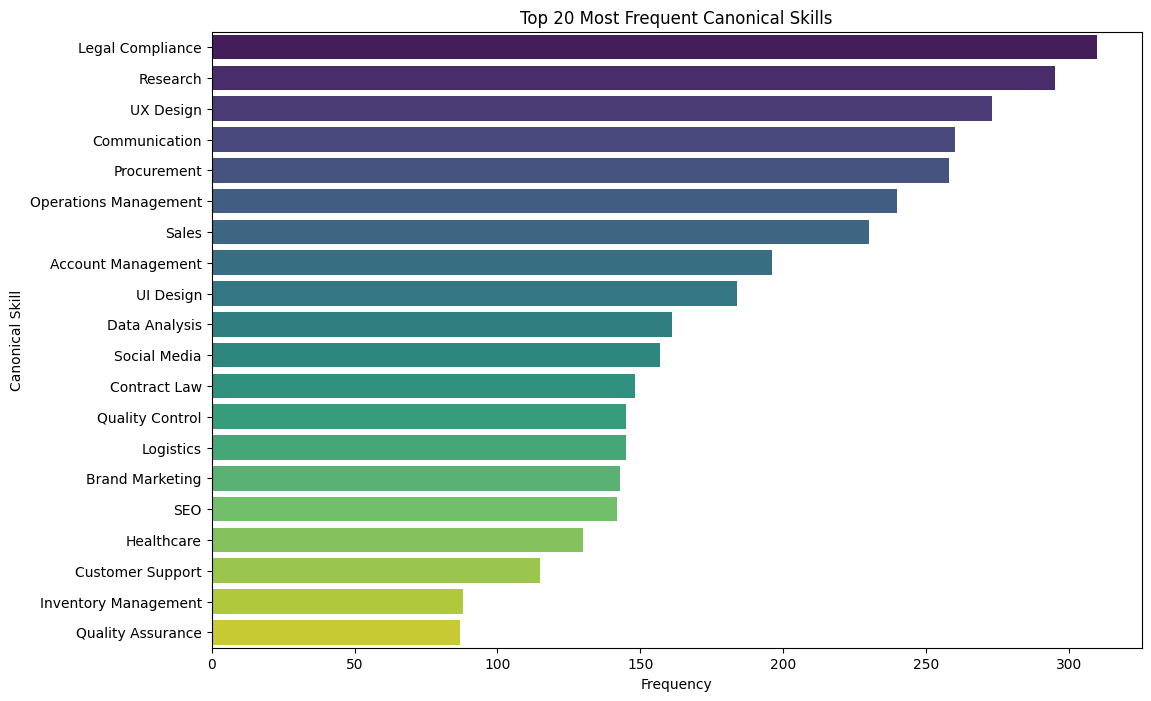

In [ ]:
# Calculate the frequency of each canonical skill
skill_frequency = (
    job_skills_df["canonical_skill"]
    .value_counts()
    .reset_index()
)
skill_frequency.columns = ["canonical_skill", "frequency"]

print("Top 20 Canonical Skills:")
display(skill_frequency.head(20))

# Plot the top 20 canonical skills
plt.figure(figsize=(12, 8))
sns.barplot(
    x="frequency",
    y="canonical_skill",
    data=skill_frequency.head(20),
    palette="viridis"
)
plt.title("Top 20 Most Frequent Canonical Skills")
plt.xlabel("Frequency")
plt.ylabel("Canonical Skill")
plt.show()

Next, let's look at the frequency of the broader skill categories.

Skill Category Frequencies:


,category,frequency
0,Digital Marketing,731
1,Legal,680
2,Operations,599
3,UI/UX Design,578
4,Healthcare,530
5,Finance & Accounting,442
6,Sales,364
7,Soft Skills,331
8,Supply Chain & Logistics,254
9,Software Testing & QA,239


/tmp/ipykernel_529/1106625699.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


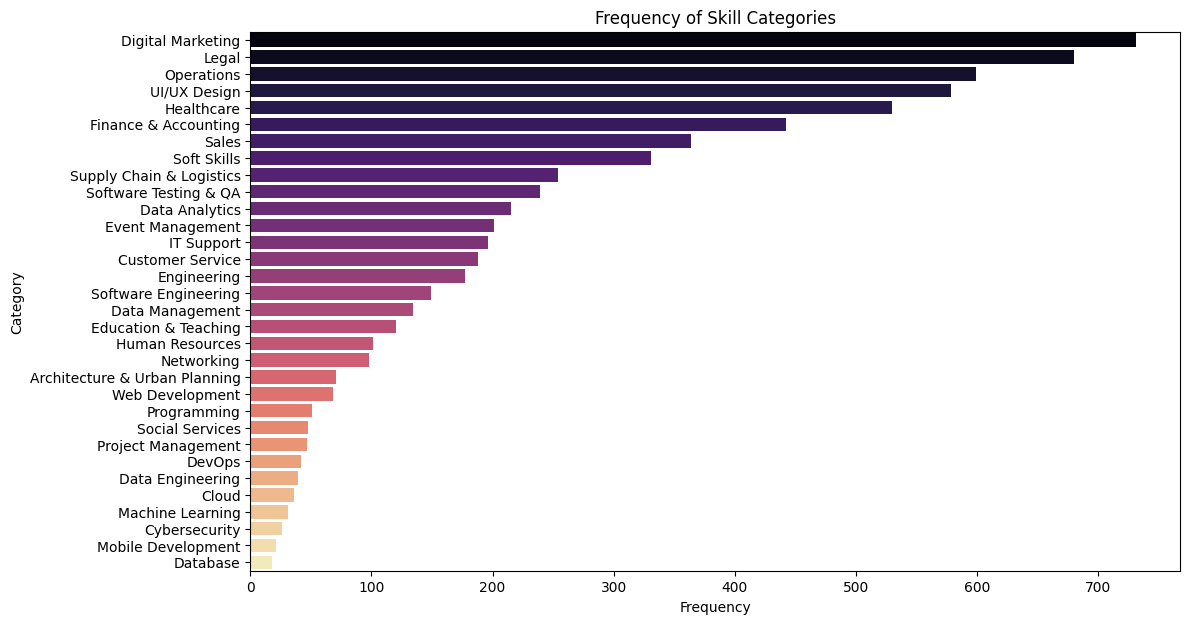

In [ ]:
# Calculate the frequency of each skill category
category_frequency = (
    job_skills_df["category"]
    .value_counts()
    .reset_index()
)
category_frequency.columns = ["category", "frequency"]

print("Skill Category Frequencies:")
display(category_frequency)

# Plot the skill category frequencies
plt.figure(figsize=(12, 7))
sns.barplot(
    x="frequency",
    y="category",
    data=category_frequency,
    palette="magma"
)
plt.title("Frequency of Skill Categories")
plt.xlabel("Frequency")
plt.ylabel("Category")
plt.show()

In [ ]:
#Most Occuring Canonical Skills
skill_frequency = (
    job_skills_df["canonical_skill"]
    .value_counts()
    .reset_index()
)

skill_frequency.columns = ["skill", "frequency"]

print("Top Skills:")
display(skill_frequency.head(20))

Top Skills:


,skill,frequency
0,Legal Compliance,310
1,Research,295
2,UX Design,273
3,Communication,260
4,Procurement,258
5,Operations Management,240
6,Sales,230
7,Account Management,196
8,UI Design,184
9,Data Analysis,161


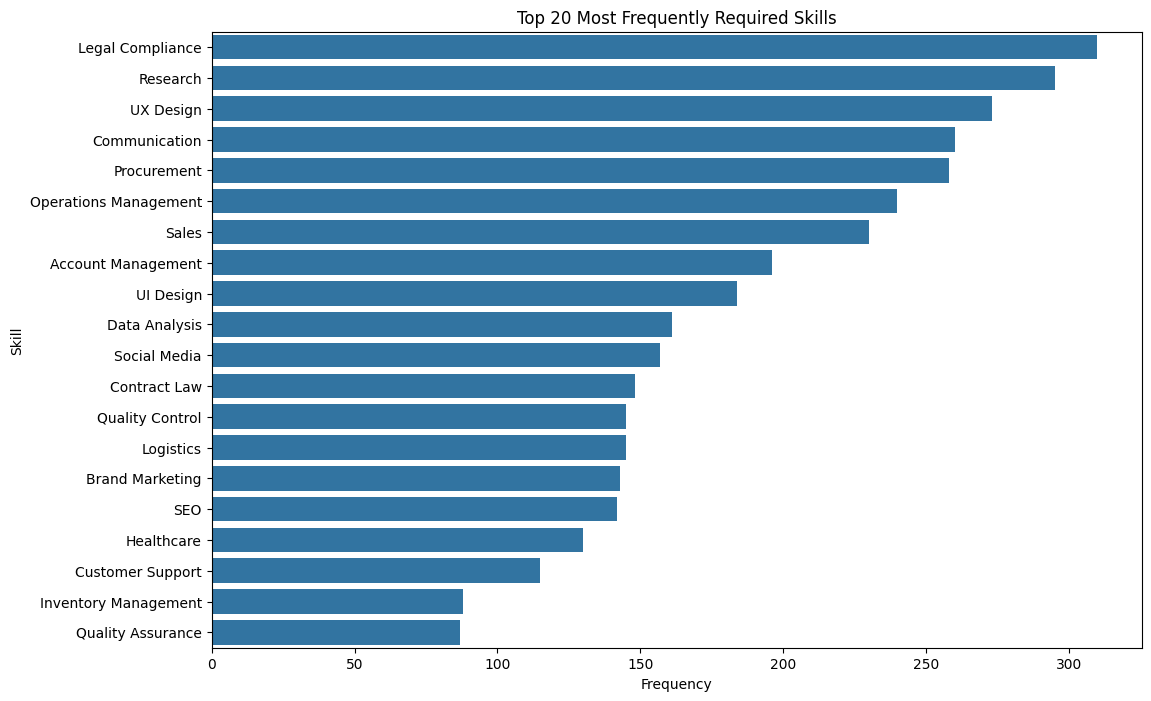

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x="frequency",
    y="skill",
    data=skill_frequency.head(20)
)

plt.title("Top 20 Most Frequently Required Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.show()

In [ ]:
category_skill_frequency = (
    job_skills_df
    .groupby(["category", "canonical_skill"])
    .size()
    .reset_index(name="frequency")
    .sort_values(["category", "frequency"], ascending=[True, False])
)

display(category_skill_frequency.head(30))

,category,canonical_skill,frequency
0,Architecture & Urban Planning,Land Use Planning,25
3,Architecture & Urban Planning,Urban Planning,25
2,Architecture & Urban Planning,Sustainable Development,13
1,Architecture & Urban Planning,Landscape Architecture,8
4,Cloud,AWS,12
5,Cloud,Google Cloud,12
6,Cloud,Microsoft Azure,12
9,Customer Service,Customer Support,115
8,Customer Service,Customer Service,64
7,Customer Service,Call Center,9


In [ ]:
#Checking how many job actually received skills
jobs_with_skills = df["extracted_skills"].apply(len).gt(0).sum()
total_jobs = len(df)

coverage = (jobs_with_skills / total_jobs) * 100

print("Total Jobs:", total_jobs)
print("Jobs with at least one skill:", jobs_with_skills)
print("Skill Extraction Coverage:", round(coverage, 2), "%")

Total Jobs: 5000
Jobs with at least one skill: 3835
Skill Extraction Coverage: 76.7 %


In [ ]:
jobs_without_skills = total_jobs - jobs_with_skills

print("Jobs without extracted skills:", jobs_without_skills)

Jobs without extracted skills: 1165


In [ ]:
no_skill_jobs = df[
    df["extracted_skills"].apply(len) == 0
]

display(
    no_skill_jobs[
        ["job_title", "job_description_matching"]
    ].head(20)
)

,job_title,job_description_matching
55,Key Account Manager,"strategic account managers nurture relationships with key clients. they develop account strategies, address client needs, and seek opportunities for business growth and expansion."
75,Technical Writer,"documentation specialists create and manage documents, manuals, or technical materials. they ensure accuracy, consistency, and accessibility of documentation."
78,Key Account Manager,"strategic account managers nurture relationships with key clients. they develop account strategies, address client needs, and seek opportunities for business growth and expansion."
84,Environmental Consultant,"sustainability consultants advise organizations on sustainable practices and strategies. they assess environmental impact, recommend sustainability initiatives, and assist in the development and i..."
89,Nurse Practitioner,"acute care nurse practitioners focus on managing acute and critical medical conditions, often working in hospitals or emergency care settings."
101,Nurse Practitioner,"acute care nurse practitioners focus on managing acute and critical medical conditions, often working in hospitals or emergency care settings."
113,Technical Writer,instructional designers develop educational materials and curricula. they design engaging and effective learning experiences for students or employees.
124,Wedding Planner,"a wedding designer specializes in creating visually appealing wedding designs and décor, transforming wedding venues into beautiful and memorable spaces."
127,Investment Analyst,"a portfolio manager oversees investment portfolios, making decisions to maximize returns and minimize risks. they analyze financial markets and adjust asset allocations accordingly."
133,Urban Planner,"transportation planners design and manage transportation systems. they optimize traffic flow, plan public transit routes, and enhance overall transportation efficiency."


In [ ]:
#DAY 9
# ============================================================
# DAY 9 — TF-IDF ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

from IPython.display import display

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset Shape: (5000, 48)

Columns:
['job_id', 'experience', 'qualifications', 'salary_range', 'location', 'country', 'latitude', 'longitude', 'work_type', 'company_size', 'job_posting_date', 'preference', 'contact_person', 'contact', 'job_title', 'role', 'job_portal', 'job_description', 'benefits', 'skills', 'responsibilities', 'company', 'company_profile', 'posting_year', 'posting_month', 'posting_day', 'posting_day_name', 'job_description_clean', 'description_char_count', 'description_word_count', 'description_sentence_count', 'skills_list', 'skill_count', 'description_normalized', 'skills_normalized', 'matched_skills', 'unmatched_skills', 'matched_skill_count', 'total_skill_count', 'skill_match_percentage', 'skills_text', 'skills_char_count', 'skills_word_count', 'skills_to_description_ratio', 'job_description_matching', 'extracted_skills', 'canonical_skills', 'skills_by_category']


,job_id,experience,qualifications,salary_range,location,country,latitude,longitude,work_type,company_size,job_posting_date,preference,contact_person,contact,job_title,role,job_portal,job_description,benefits,skills,responsibilities,company,company_profile,posting_year,posting_month,posting_day,posting_day_name,job_description_clean,description_char_count,description_word_count,description_sentence_count,skills_list,skill_count,description_normalized,skills_normalized,matched_skills,unmatched_skills,matched_skill_count,total_skill_count,skill_match_percentage,skills_text,skills_char_count,skills_word_count,skills_to_description_ratio,job_description_matching,extracted_skills,canonical_skills,skills_by_category
0,1.089840e+15,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,2022-04-24,Female,Brandon Cunningham,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...","{'Flexible Spending Accounts (FSAs), Relocation Assistance, Legal Assistance, Employee Recognition Programs, Financial Counseling'}","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising","Manage and grow social media accounts, create engaging content, and interact with the online community. Develop social media content calendars and strategies. Monitor social media trends and engag...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversified Financials"",""City"":""Sunny Isles Beach"",""State"":""Florida"",""Zip"":""33160"",""Website"":""www.ielp.com"",""Ticker"":""IEP"",""CEO"":""David Willetts""}",2022,4,24,Sunday,social media managers oversee an organizations social media presence. they create and schedule content engage with followers and analyze social media metrics to drive brand awareness and engagement.,200,28,2,"[Social media platforms (e.g., Facebook, Twitter, Instagram), Content creation and scheduling, Social media analytics and insights, Community engagement, Paid social advertising]",2,social media managers oversee an organizations social media presence. they create and schedule content engage with followers and analyze social media metrics to drive brand awareness and engagement.,"[social media platforms e.g., facebook, twitter, instagram content creation and scheduling social media analytics and insights community engagement paid social advertising]",[],"[social media platforms e.g., facebook, twitter, instagram content creation and scheduling social media analytics and insights community engagement paid social advertising]",0,4,0.0,"Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising",172,21,0.750000,"social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...","[{'category': 'Digital Marketing', 'canonical_skill': 'Social Media', 'matched_synonym': 'social media'}, {'category': 'Digital Marketing', 'canonical_skill': 'Brand Marketing', 'matched_synonym':...","[Social Media, Brand Marketing]","{'Digital Marketing': ['Social Media', 'Brand Marketing']}"
1,3.984540e+14,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,2022-12-19,Female,Francisco Larsen,461-509-4216,Web Developer,Frontend Web Developer,Idealist,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create ...","{'Health Insurance, Retirement Plans, Paid Time Off (PTO), Flexible Wo

In [ ]:
if "clean_description" in df.columns:
    print("clean_description exists.")
else:
    print("clean_description does NOT exist.")

clean_description does NOT exist.


In [ ]:
df["clean_description"] = (
    df["job_description_matching"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

In [ ]:
display(
    df[["job_description_matching", "clean_description"]].head()
)

,job_description_matching,clean_description
0,"social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...","social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem..."
1,"frontend web developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. they collaborate with designers and backend developers to create ...","frontend web developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. they collaborate with designers and backend developers to create ..."
2,"quality control managers establish and enforce quality standards within an organization. they develop quality control processes, perform inspections, and implement corrective actions to maintain p...","quality control managers establish and enforce quality standards within an organization. they develop quality control processes, perform inspections, and implement corrective actions to maintain p..."
3,"wireless network engineers design, implement, and maintain wireless network solutions. they optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communicati...","wireless network engineers design, implement, and maintain wireless network solutions. they optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communicati..."
4,"a conference manager coordinates and manages conferences, meetings, and events. they plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to t...","a conference manager coordinates and manages conferences, meetings, and events. they plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to t..."


In [ ]:
print("Missing clean descriptions:")

print(
    df["clean_description"]
    .isna()
    .sum()
)

Missing clean descriptions:
0


In [ ]:
df["clean_description"] = (
    df["clean_description"]
    .fillna("")
    .astype(str)
)

In [ ]:
#Creating TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

In [ ]:
# ============================================================
# TF-IDF VECTORIZER
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

print("TF-IDF Vectorizer created successfully.")

TF-IDF Vectorizer created successfully.


In [ ]:
# ============================================================
# CREATE TF-IDF MATRIX
# ============================================================

X = vectorizer.fit_transform(
    df["clean_description"]
)

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (5000, 1000)


In [ ]:
# ============================================================
# GET TF-IDF FEATURES
# ============================================================

feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 1000

First 50 features:
['academic' 'access' 'accessibility' 'accessible' 'accordingly' 'account'
 'accountants' 'accounting' 'accounts' 'accuracy' 'accurate' 'accurately'
 'achieve' 'acquiring' 'acquisition' 'acquisitions' 'activities' 'acute'
 'addiction' 'address' 'addressing' 'adhering' 'adjust' 'administer'
 'administers' 'administrative' 'administrators' 'adolescents' 'adoption'
 'adult' 'adults' 'advertising' 'advice' 'advise' 'advisors'
 'aesthetically' 'aesthetics' 'affecting' 'age' 'agencies' 'agent' 'ages'
 'agile' 'agreements' 'aid' 'aided' 'aiding' 'air' 'aircraft' 'align']


In [ ]:
# ============================================================
# CALCULATE OVERALL TF-IDF SCORES
# ============================================================

tfidf_scores = np.asarray(X.sum(axis=0)).flatten()

tfidf_df = pd.DataFrame({
    "term": feature_names,
    "tfidf_score": tfidf_scores
})

tfidf_df = (
    tfidf_df
    .sort_values(
        "tfidf_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(tfidf_df.head(30))

,term,tfidf_score
0,data,157.252389
1,user,152.629633
2,ensure,119.226168
3,support,111.928281
4,provide,100.423081
5,design,100.095128
6,manage,99.649016
7,financial,98.527670
8,create,96.854600
9,ensuring,91.975143


In [ ]:
# ============================================================
# TOP 20 TF-IDF KEYWORDS
# ============================================================

top_20_tfidf = tfidf_df.head(20)

print("Top 20 TF-IDF Keywords:")

display(top_20_tfidf)

Top 20 TF-IDF Keywords:


,term,tfidf_score
0,data,157.252389
1,user,152.629633
2,ensure,119.226168
3,support,111.928281
4,provide,100.423081
5,design,100.095128
6,manage,99.649016
7,financial,98.527670
8,create,96.854600
9,ensuring,91.975143


In [ ]:
# ============================================================
# TOP 50 TF-IDF KEYWORDS
# ============================================================

top_50_tfidf = tfidf_df.head(50)

display(top_50_tfidf)

,term,tfidf_score
0,data,157.252389
1,user,152.629633
2,ensure,119.226168
3,support,111.928281
4,provide,100.423081
5,design,100.095128
6,manage,99.649016
7,financial,98.527670
8,create,96.854600
9,ensuring,91.975143


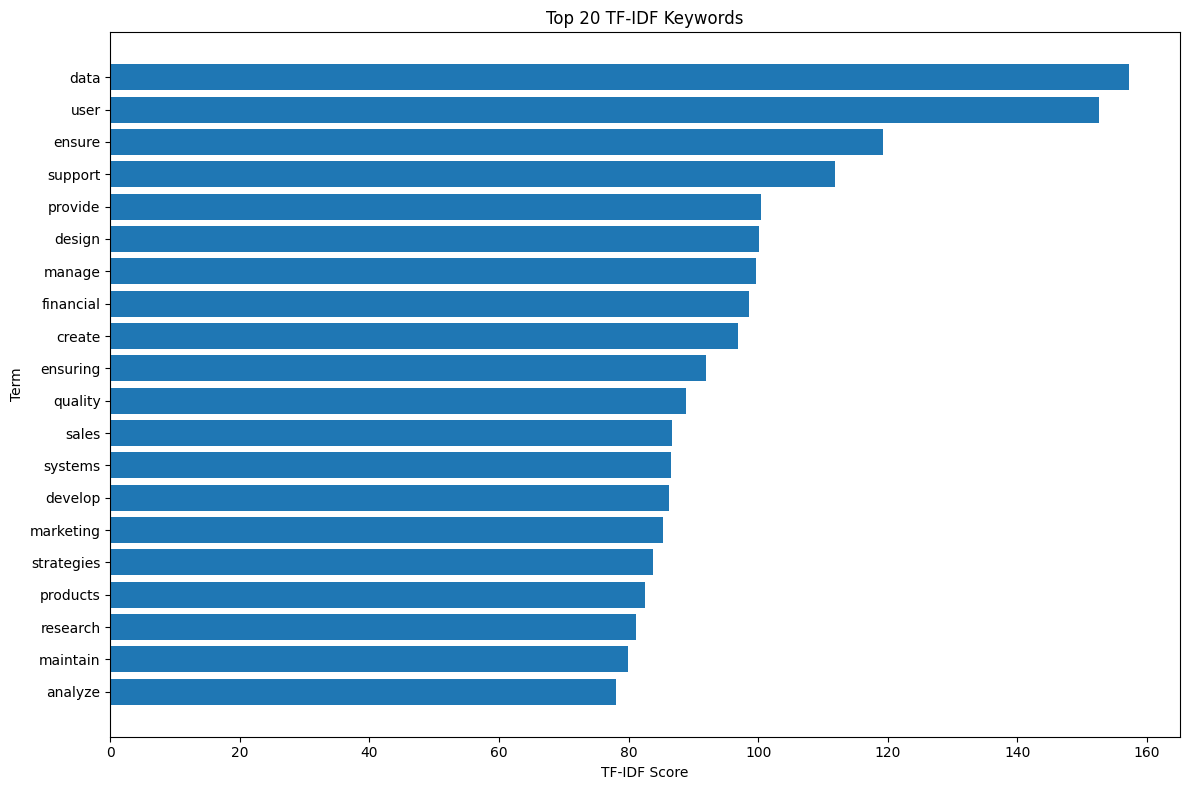

In [ ]:
# ============================================================
# VISUALIZE TOP 20 TF-IDF KEYWORDS
# ============================================================

top_20 = tfidf_df.head(20).sort_values(
    "tfidf_score"
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_20["term"],
    top_20["tfidf_score"]
)

plt.title("Top 20 TF-IDF Keywords")
plt.xlabel("TF-IDF Score")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TF-IDF KEYWORDS FOR A SINGLE JOB
# ============================================================

job_number = 0

row = X[job_number]

scores = row.toarray().flatten()

single_job_tfidf = pd.DataFrame({
    "term": feature_names,
    "tfidf_score": scores
})

single_job_tfidf = (
    single_job_tfidf[
        single_job_tfidf["tfidf_score"] > 0
    ]
    .sort_values(
        "tfidf_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Job Title:")
print(df.iloc[job_number]["job_title"])

print("\nTop TF-IDF Terms:")

display(
    single_job_tfidf.head(20)
)

Job Title:
Digital Marketing Specialist

Top TF-IDF Terms:


,term,tfidf_score
0,media,0.517391
1,social,0.514750
2,followers,0.227458
3,schedule,0.227458
4,presence,0.204046
5,awareness,0.200295
6,engagement,0.194865
7,metrics,0.194476
8,engage,0.181407
9,drive,0.177942


In [ ]:
# ============================================================
# FUNCTION TO GET TOP TF-IDF TERMS FOR A JOB
# ============================================================

def get_top_tfidf_terms(job_index, top_n=10):

    scores = X[job_index].toarray().flatten()

    result = pd.DataFrame({
        "term": feature_names,
        "tfidf_score": scores
    })

    result = (
        result[
            result["tfidf_score"] > 0
        ]
        .sort_values(
            "tfidf_score",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return result

In [ ]:
display(
    get_top_tfidf_terms(0, top_n=10)
)

,term,tfidf_score
0,media,0.517391
1,social,0.514750
2,followers,0.227458
3,schedule,0.227458
4,presence,0.204046
5,awareness,0.200295
6,engagement,0.194865
7,metrics,0.194476
8,engage,0.181407
9,drive,0.177942


In [ ]:
# ============================================================
# COMPARE TF-IDF TERMS FOR MULTIPLE JOBS
# ============================================================

for i in range(5):

    print("=" * 60)

    print("Job:", i)
    print("Title:", df.iloc[i]["job_title"])

    print("\nTop TF-IDF Terms:")

    display(
        get_top_tfidf_terms(i, top_n=10)
    )

Job: 0
Title: Digital Marketing Specialist

Top TF-IDF Terms:


,term,tfidf_score
0,media,0.517391
1,social,0.514750
2,followers,0.227458
3,schedule,0.227458
4,presence,0.204046
5,awareness,0.200295
6,engagement,0.194865
7,metrics,0.194476
8,engage,0.181407
9,drive,0.177942


Job: 1
Title: Web Developer

Top TF-IDF Terms:


,term,tfidf_score
0,developers,0.430541
1,web,0.387384
2,user,0.310463
3,frontend,0.242856
4,backend,0.226239
5,experiences,0.216056
6,users,0.207751
7,seamless,0.207751
8,friendly,0.200177
9,collaborate,0.197470


Job: 2
Title: Operations Manager

Top TF-IDF Terms:


,term,tfidf_score
0,quality,0.622575
1,control,0.375749
2,establish,0.270947
3,enforce,0.250621
4,service,0.249060
5,inspections,0.247558
6,perform,0.186900
7,organization,0.167091
8,standards,0.164450
9,processes,0.157593


Job: 3
Title: Network Engineer

Top TF-IDF Terms:


,term,tfidf_score
0,wireless,0.825639
1,network,0.267998
2,connectivity,0.195143
3,secure,0.190791
4,communications,0.188207
5,reliable,0.159088
6,troubleshoot,0.157288
7,engineers,0.119723
8,solutions,0.115590
9,optimize,0.109245


Job: 4
Title: Event Manager

Top TF-IDF Terms:


,term,tfidf_score
0,events,0.436870
1,vendors,0.282468
2,attendees,0.280649
3,catering,0.271064
4,execution,0.268278
5,conferences,0.245517
6,coordinates,0.240179
7,smooth,0.238073
8,budgeting,0.234139
9,meetings,0.217561


In [ ]:
# ============================================================
# SPACY SKILL EXTRACTION
# ============================================================

import spacy
from spacy.matcher import PhraseMatcher

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Create PhraseMatcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

# Create patterns from taxonomy synonyms
patterns = []

for category, skills in skill_taxonomy.items():
    for canonical_skill, synonyms in skills.items():
        for synonym in synonyms:
            patterns.append(
                (category, canonical_skill, synonym)
            )

# Add patterns
for category, canonical_skill, synonym in patterns:
    pattern = nlp.make_doc(synonym)

    matcher.add(
        f"{category}|||{canonical_skill}",
        [pattern]
    )

print("SpaCy PhraseMatcher created successfully.")
print("Total patterns:", len(patterns))

SpaCy PhraseMatcher created successfully.
Total patterns: 1210


In [ ]:
# ============================================================
# SPACY PHRASE MATCHING FUNCTION
# ============================================================

def extract_skills_spacy(text):

    if pd.isna(text):
        return []

    doc = nlp(str(text).lower())

    matches = matcher(doc)

    found = []

    for match_id, start, end in matches:

        match_name = nlp.vocab.strings[match_id]

        category, canonical_skill = match_name.split("|||")

        found.append({
            "category": category,
            "canonical_skill": canonical_skill,
            "matched_text": doc[start:end].text
        })

    # Remove duplicate skills
    unique_skills = {}

    for item in found:

        key = (
            item["category"],
            item["canonical_skill"]
        )

        unique_skills[key] = item

    return list(unique_skills.values())

In [ ]:
# ============================================================
# APPLY SPACY EXTRACTION
# ============================================================

df["extracted_skills_spacy"] = (
    df["job_description_matching"]
    .apply(extract_skills_spacy)
)

print("SpaCy extraction completed.")

SpaCy extraction completed.


In [ ]:
# ============================================================
# CHECK DICTIONARY / TAXONOMY SKILLS
# ============================================================

display(
    df[
        [
            "job_title",
            "extracted_skills_spacy"
        ]
    ].head(10)
)

,job_title,extracted_skills_spacy
0,Digital Marketing Specialist,"[{'category': 'Digital Marketing', 'canonical_skill': 'Social Media', 'matched_text': 'social media'}, {'category': 'Digital Marketing', 'canonical_skill': 'Brand Marketing', 'matched_text': 'bran..."
1,Web Developer,"[{'category': 'Web Development', 'canonical_skill': 'Web Development', 'matched_text': 'web developers'}]"
2,Operations Manager,"[{'category': 'Software Testing & QA', 'canonical_skill': 'Quality Control', 'matched_text': 'quality control'}, {'category': 'Operations', 'canonical_skill': 'Quality Control', 'matched_text': 'q..."
3,Network Engineer,"[{'category': 'Networking', 'canonical_skill': 'Wireless Networking', 'matched_text': 'wireless connectivity'}]"
4,Event Manager,"[{'category': 'Event Management', 'canonical_skill': 'Logistics', 'matched_text': 'logistics'}, {'category': 'Finance & Accounting', 'canonical_skill': 'Budgeting', 'matched_text': 'budgeting'}]"
5,Software Tester,"[{'category': 'Software Testing & QA', 'canonical_skill': 'Quality Assurance', 'matched_text': 'quality assurance'}, {'category': 'Operations', 'canonical_skill': 'Quality Control', 'matched_text'..."
6,Teacher,"[{'category': 'Education & Teaching', 'canonical_skill': 'Teaching', 'matched_text': 'instruction'}, {'category': 'Education & Teaching', 'canonical_skill': 'Lesson Planning', 'matched_text': 'les..."
7,UX/UI Designer,"[{'category': 'UI/UX Design', 'canonical_skill': 'UI Design', 'matched_text': 'digital interfaces'}]"
8,UX/UI Designer,"[{'category': 'UI/UX Design', 'canonical_skill': 'UX Design', 'matched_text': 'user experiences'}, {'category': 'UI/UX Design', 'canonical_skill': 'UI Design', 'matched_text': 'digital interfaces'}]"
9,Wedding Planner,"[{'category': 'Finance & Accounting', 'canonical_skill': 'Budgeting', 'matched_text': 'budget management'}, {'category': 'Event Management', 'canonical_skill': 'Budget Management', 'matched_text':..."


In [ ]:
# ============================================================
# EXTRACT CANONICAL SKILL NAMES
# ============================================================

def get_canonical_skills(skill_list):

    if not isinstance(skill_list, list):
        return []

    result = []

    for item in skill_list:

        if isinstance(item, dict):

            skill = item.get("canonical_skill")

            if skill:
                result.append(skill)

        elif isinstance(item, str):

            result.append(item)

    return list(dict.fromkeys(result))

In [ ]:
df["dictionary_skills"] = (
    df["extracted_skills_spacy"]
    .apply(get_canonical_skills)
)

In [ ]:
display(
    df[
        [
            "job_title",
            "dictionary_skills"
        ]
    ].head(10)
)

,job_title,dictionary_skills
0,Digital Marketing Specialist,"[Social Media, Brand Marketing]"
1,Web Developer,[Web Development]
2,Operations Manager,[Quality Control]
3,Network Engineer,[Wireless Networking]
4,Event Manager,"[Logistics, Budgeting]"
5,Software Tester,"[Quality Assurance, Quality Control]"
6,Teacher,"[Teaching, Lesson Planning]"
7,UX/UI Designer,[UI Design]
8,UX/UI Designer,"[UX Design, UI Design]"
9,Wedding Planner,"[Budgeting, Budget Management]"


In [ ]:
# ============================================================
# DICTIONARY SKILLS VS TF-IDF KEYWORDS
# ============================================================

comparison_rows = []

for i in range(len(df)):

    dictionary_skills = df.iloc[i]["dictionary_skills"]

    tfidf_terms = (
        get_top_tfidf_terms(i, top_n=10)["term"]
        .tolist()
    )

    comparison_rows.append({
        "job_index": i,
        "job_title": df.iloc[i]["job_title"],
        "dictionary_skills": dictionary_skills,
        "tfidf_keywords": tfidf_terms
    })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df.head(20))

,job_index,job_title,dictionary_skills,tfidf_keywords
0,0,Digital Marketing Specialist,"[Social Media, Brand Marketing]","[media, social, followers, schedule, presence, awareness, engagement, metrics, engage, drive]"
1,1,Web Developer,[Web Development],"[developers, web, user, frontend, backend, experiences, users, seamless, friendly, collaborate]"
2,2,Operations Manager,[Quality Control],"[quality, control, establish, enforce, service, inspections, perform, organization, standards, processes]"
3,3,Network Engineer,[Wireless Networking],"[wireless, network, connectivity, secure, communications, reliable, troubleshoot, engineers, solutions, optimize]"
4,4,Event Manager,"[Logistics, Budgeting]","[events, vendors, attendees, catering, execution, conferences, coordinates, smooth, budgeting, meetings]"
5,5,Software Tester,"[Quality Assurance, Quality Control]","[quality, tests, report, assurance, defects, resolve, problems, analyst, standards, meet]"
6,6,Teacher,"[Teaching, Lesson Planning]","[foster, instruction, progress, subject, deliver, teacher, level, positive, specific, environment]"
7,7,UX/UI Designer,[UI Design],"[interface, user, buttons, interactive, cohesive, visual, elements, aspects, layouts, appealing]"
8,8,UX/UI Designer,"[UX Design, UI Design]","[user, interaction, meaningful, responses, behaviors, considering, interactions, experiences, engaging, designing]"
9,9,Wedding Planner,"[Budgeting, Budget Management]","[wedding, selection, couples, weddings, day, assists, coordinating, consultant, budget, helping]"


In [ ]:
# ============================================================
# VIEW ONE JOB COMPARISON
# ============================================================

job_index = 0

print("JOB TITLE:")
print(df.iloc[job_index]["job_title"])

print("\nDICTIONARY / TAXONOMY SKILLS:")
print(df.iloc[job_index]["dictionary_skills"])

print("\nTOP TF-IDF KEYWORDS:")
print(
    get_top_tfidf_terms(
        job_index,
        top_n=15
    )["term"].tolist()
)

JOB TITLE:
Digital Marketing Specialist

DICTIONARY / TAXONOMY SKILLS:
['Social Media', 'Brand Marketing']

TOP TF-IDF KEYWORDS:
['media', 'social', 'followers', 'schedule', 'presence', 'awareness', 'engagement', 'metrics', 'engage', 'drive', 'brand', 'content', 'organizations', 'oversee', 'managers']


In [ ]:
# ============================================================
# ALL CANONICAL SKILLS
# ============================================================

all_canonical_skills = set()

for category, skills in skill_taxonomy.items():

    for canonical_skill in skills.keys():

        all_canonical_skills.add(
            canonical_skill.lower()
        )

print(
    "Total canonical skills:",
    len(all_canonical_skills)
)

Total canonical skills: 360


In [ ]:
# ============================================================
# TF-IDF TERMS THAT MATCH CANONICAL SKILLS
# ============================================================

tfidf_skill_matches = []

for term in feature_names:

    if term.lower() in all_canonical_skills:

        score = tfidf_df.loc[
            tfidf_df["term"] == term,
            "tfidf_score"
        ].iloc[0]

        tfidf_skill_matches.append({
            "term": term,
            "tfidf_score": score
        })

tfidf_skill_matches_df = pd.DataFrame(
    tfidf_skill_matches
)

tfidf_skill_matches_df = (
    tfidf_skill_matches_df
    .sort_values(
        "tfidf_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tfidf_skill_matches_df.head(30)
)

,term,tfidf_score
0,sales,86.646981
1,research,81.191110
2,procurement,58.953213
3,communication,48.225881
4,seo,42.114578
5,logistics,35.710175
6,healthcare,31.649708
7,training,25.463662
8,manufacturing,24.321002
9,accounting,17.058333


In [ ]:
# ============================================================
# TF-IDF TERMS THAT MATCH TAXONOMY SYNONYMS
# ============================================================

taxonomy_synonyms = set(
    synonym_to_skill.keys()
)

matched_taxonomy_terms = []

for term in feature_names:

    if term.lower() in taxonomy_synonyms:

        info = synonym_to_skill[term.lower()]

        score = tfidf_df.loc[
            tfidf_df["term"] == term,
            "tfidf_score"
        ].iloc[0]

        matched_taxonomy_terms.append({

            "tfidf_term": term,

            "canonical_skill":
                info["canonical_skill"],

            "category":
                info["category"],

            "tfidf_score":
                score
        })

matched_taxonomy_df = pd.DataFrame(
    matched_taxonomy_terms
)

matched_taxonomy_df = (
    matched_taxonomy_df
    .sort_values(
        "tfidf_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    matched_taxonomy_df.head(30)
)

,tfidf_term,canonical_skill,category,tfidf_score
0,sales,Sales,Sales,86.646981
1,research,Research,Healthcare,81.191110
2,procurement,Procurement,Supply Chain & Logistics,58.953213
3,compliance,Legal Compliance,Legal,53.144046
4,operations,Operations Management,Operations,52.068889
5,communication,Communication,Soft Skills,48.225881
6,seo,SEO,Digital Marketing,42.114578
7,logistics,Logistics,Event Management,35.710175
8,healthcare,Healthcare,Healthcare,31.649708
9,contracts,Contract Law,Legal,30.428814


In [ ]:
# ============================================================
# TF-IDF TERMS NOT CURRENTLY IN TAXONOMY
# ============================================================

unknown_tfidf_terms = []

for _, row in tfidf_df.iterrows():

    term = row["term"]

    if term.lower() not in taxonomy_synonyms:

        unknown_tfidf_terms.append({
            "term": term,
            "tfidf_score": row["tfidf_score"]
        })

unknown_tfidf_df = pd.DataFrame(
    unknown_tfidf_terms
)

display(
    unknown_tfidf_df.head(50)
)

,term,tfidf_score
0,data,157.252389
1,user,152.629633
2,ensure,119.226168
3,support,111.928281
4,provide,100.423081
5,design,100.095128
6,manage,99.649016
7,financial,98.527670
8,create,96.854600
9,ensuring,91.975143


In [ ]:
# ============================================================
# POTENTIAL NEW SKILL CANDIDATES
# ============================================================

print("Potential terms missing from taxonomy:")

display(
    unknown_tfidf_df.head(30)
)

Potential terms missing from taxonomy:


,term,tfidf_score
0,data,157.252389
1,user,152.629633
2,ensure,119.226168
3,support,111.928281
4,provide,100.423081
5,design,100.095128
6,manage,99.649016
7,financial,98.527670
8,create,96.854600
9,ensuring,91.975143


In [ ]:
# ============================================================
# TF-IDF STATISTICS
# ============================================================

print("Number of Jobs:", X.shape[0])
print("Number of TF-IDF Features:", X.shape[1])

print(
    "Non-zero TF-IDF values:",
    X.nnz
)

print(
    "Matrix Sparsity:",
    round(
        1 - (X.nnz / (X.shape[0] * X.shape[1])),
        4
    )
)

Number of Jobs: 5000
Number of TF-IDF Features: 1000
Non-zero TF-IDF values: 76366
Matrix Sparsity: 0.9847


In [ ]:
# ============================================================
# FINAL TF-IDF RESULTS
# ============================================================

print("Top 30 TF-IDF Keywords in Job Descriptions")

display(
    tfidf_df.head(30)
)

Top 30 TF-IDF Keywords in Job Descriptions


,term,tfidf_score
0,data,157.252389
1,user,152.629633
2,ensure,119.226168
3,support,111.928281
4,provide,100.423081
5,design,100.095128
6,manage,99.649016
7,financial,98.527670
8,create,96.854600
9,ensuring,91.975143


## Conclusion

TF-IDF was applied to the 5,000 job descriptions to identify
important terms within the dataset.

The analysis showed that TF-IDF can automatically identify
frequently important terms and phrases in job descriptions.

However, TF-IDF does not understand whether a term is actually
a professional skill.

For example, TF-IDF may identify words such as "company",
"experience", "team", or "role", which may be important in the
documents but are not necessarily skills.

The dictionary/taxonomy-based approach provides more precise
skill identification because it maps detected terms to
canonical skills and categories.

Therefore:

Dictionary-based extraction:
- More precise for known skills
- Provides canonical skill names
- Provides skill categories
- Depends on taxonomy coverage

TF-IDF:
- Can discover important terms automatically
- Does not require a predefined skill list
- Can help identify potential missing skills
- Can produce non-skill keywords

TF-IDF can therefore complement the rule-based skill extractor
rather than completely replacing it.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer #DAY 10

In [ ]:
documents = (
    df["job_description_matching"]
    .fillna("")
    .astype(str)
)

print("Total Job Descriptions:", len(documents))

Total Job Descriptions: 5000


In [ ]:
# ============================================================
# N-GRAM ANALYSIS
# ============================================================

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()

print("Total N-Grams:", len(feature_names))

Total N-Grams: 12099


In [ ]:
mean_scores = np.asarray(
    tfidf_matrix.mean(axis=0)
).flatten()

ngram_df = pd.DataFrame({
    "ngram": feature_names,
    "tfidf_score": mean_scores
})

ngram_df = ngram_df.sort_values(
    "tfidf_score",
    ascending=False
).reset_index(drop=True)

display(ngram_df.head(30))

,ngram,tfidf_score
0,user,0.015555
1,data,0.015405
2,ensure,0.011868
3,support,0.010927
4,financial,0.010289
5,design,0.009758
6,create,0.009731
7,provide,0.009616
8,manage,0.009489
9,ensuring,0.009162


In [ ]:
#Separating Grams
ngram_df["word_count"] = (
    ngram_df["ngram"]
    .str.split()
    .str.len()
)

In [ ]:
#Unigram
unigrams = ngram_df[
    ngram_df["word_count"] == 1
]

display(unigrams.head(20))

,ngram,tfidf_score,word_count
0,user,0.015555,1
1,data,0.015405,1
2,ensure,0.011868,1
3,support,0.010927,1
4,financial,0.010289,1
5,design,0.009758,1
6,create,0.009731,1
7,provide,0.009616,1
8,manage,0.009489,1
9,ensuring,0.009162,1


In [ ]:
bigrams = ngram_df[
    ngram_df["word_count"] == 2
]

display(bigrams.head(20))

,ngram,tfidf_score,word_count
32,social media,0.006421,2
94,user experience,0.004098,2
97,visually appealing,0.004034,2
101,decision making,0.003944,2
104,products services,0.003911,2
121,supply chain,0.003631,2
126,digital interfaces,0.003600,2
133,user interface,0.003505,2
146,managers oversee,0.003311,2
158,administrators manage,0.003126,2


In [ ]:
trigrams = ngram_df[
    ngram_df["word_count"] == 3
]

display(trigrams.head(20))

,ngram,tfidf_score,word_count
212,cost saving opportunities,0.002555,3
247,organizations computer networks,0.002271,3
252,identify cost saving,0.002250,3
275,ensuring data integrity,0.002148,3
317,designers specialize designing,0.001970,3
323,analyze procurement data,0.001964,3
325,procurement data identify,0.001964,3
327,data identify cost,0.001964,3
328,opportunities support procurement,0.001964,3
330,saving opportunities support,0.001964,3


In [ ]:
multi_word_terms = ngram_df[
    ngram_df["word_count"].isin([2, 3])
]

display(multi_word_terms.head(50))

,ngram,tfidf_score,word_count
32,social media,0.006421,2
94,user experience,0.004098,2
97,visually appealing,0.004034,2
101,decision making,0.003944,2
104,products services,0.003911,2
121,supply chain,0.003631,2
126,digital interfaces,0.003600,2
133,user interface,0.003505,2
146,managers oversee,0.003311,2
158,administrators manage,0.003126,2


In [ ]:
taxonomy_terms = set()

for category, skills in skill_taxonomy.items():

    for canonical_skill, synonyms in skills.items():

        for synonym in synonyms:

            taxonomy_terms.add(
                synonym.lower().strip()
            )

In [ ]:
multi_word_terms["in_taxonomy"] = (
    multi_word_terms["ngram"]
    .str.lower()
    .isin(taxonomy_terms)
)

display(
    multi_word_terms.head(50)
)

/tmp/ipykernel_529/2538999238.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_word_terms["in_taxonomy"] = (


,ngram,tfidf_score,word_count,in_taxonomy
32,social media,0.006421,2,True
94,user experience,0.004098,2,True
97,visually appealing,0.004034,2,False
101,decision making,0.003944,2,False
104,products services,0.003911,2,False
121,supply chain,0.003631,2,True
126,digital interfaces,0.003600,2,True
133,user interface,0.003505,2,False
146,managers oversee,0.003311,2,False
158,administrators manage,0.003126,2,False


In [ ]:
new_candidates = multi_word_terms[
    multi_word_terms["in_taxonomy"] == False
]

display(new_candidates.head(50))

,ngram,tfidf_score,word_count,in_taxonomy
97,visually appealing,0.004034,2,False
101,decision making,0.003944,2,False
104,products services,0.003911,2,False
133,user interface,0.003505,2,False
146,managers oversee,0.003311,2,False
158,administrators manage,0.003126,2,False
177,provide insights,0.002939,2,False
198,ensuring data,0.002618,2,False
207,user friendly,0.002569,2,False
209,cost saving,0.002555,2,False


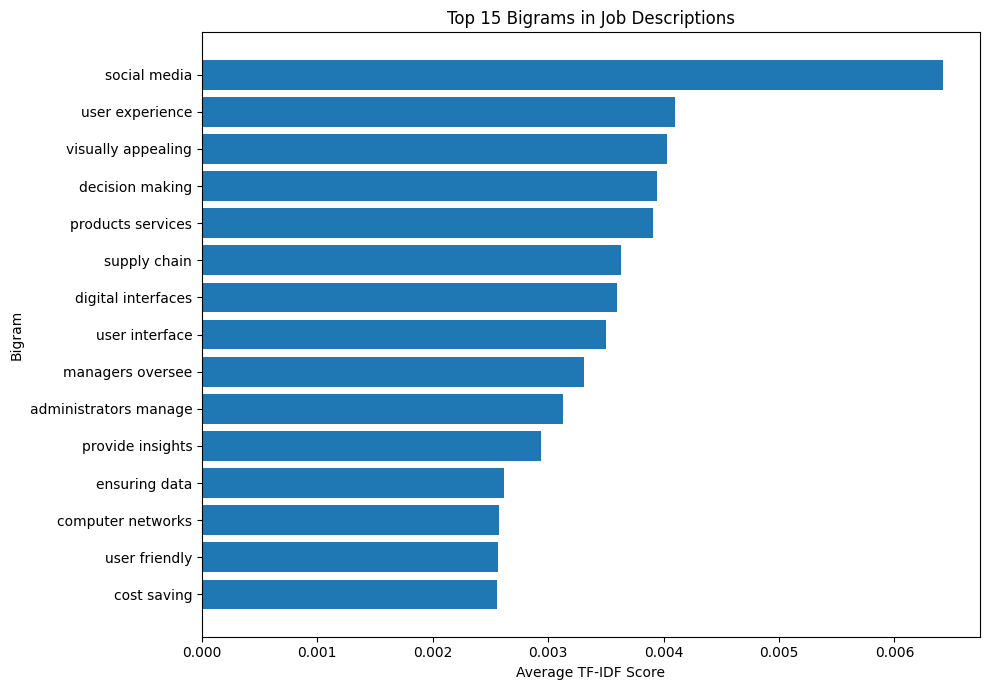

In [ ]:
#Visualizing Top Bigram
top_bigrams = bigrams.head(15).sort_values(
    "tfidf_score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_bigrams["ngram"],
    top_bigrams["tfidf_score"]
)

plt.title("Top 15 Bigrams in Job Descriptions")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Bigram")

plt.tight_layout()
plt.show()

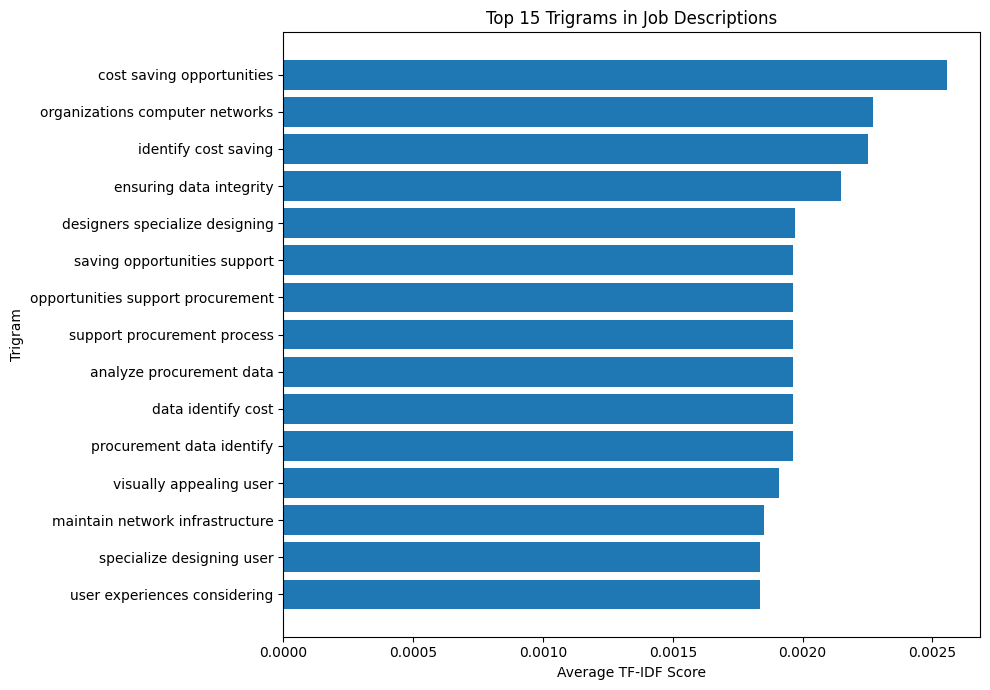

In [ ]:
#Visualizing Top Trigrams
top_trigrams = trigrams.head(15).sort_values(
    "tfidf_score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_trigrams["ngram"],
    top_trigrams["tfidf_score"]
)

plt.title("Top 15 Trigrams in Job Descriptions")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Trigram")

plt.tight_layout()
plt.show()

In [ ]:
ngram_df.to_csv(
    "ngram_analysis_results.csv",
    index=False
)

print("N-Gram analysis saved successfully.")

N-Gram analysis saved successfully.


In [ ]:
!pip install -q sentence-transformers #DAY 11

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded successfully.")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully.


In [ ]:
test_phrases = [
    "ML",
    "Machine Learning",
    "NLP",
    "Natural Language Processing",
    "AI",
    "Artificial Intelligence",
    "PowerBI",
    "Power BI"
]

embeddings = model.encode(test_phrases)

similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=test_phrases,
    columns=test_phrases
)

display(similarity_df.round(3))

,ML,Machine Learning,NLP,Natural Language Processing,AI,Artificial Intelligence,PowerBI,Power BI
ML,1.000,0.373,0.181,0.097,0.344,0.299,0.099,0.094
Machine Learning,0.373,1.000,0.416,0.482,0.546,0.703,0.234,0.198
NLP,0.181,0.416,1.000,0.602,0.402,0.413,0.183,0.123
Natural Language Processing,0.097,0.482,0.602,1.000,0.311,0.429,0.150,0.114
AI,0.344,0.546,0.402,0.311,1.000,0.791,0.231,0.204
Artificial Intelligence,0.299,0.703,0.413,0.429,0.791,1.000,0.205,0.169
PowerBI,0.099,0.234,0.183,0.150,0.231,0.205,1.000,0.682
Power BI,0.094,0.198,0.123,0.114,0.204,0.169,0.682,1.000


In [ ]:
pairs = [
    ("ML", "Machine Learning"),
    ("NLP", "Natural Language Processing"),
    ("AI", "Artificial Intelligence"),
    ("PowerBI", "Power BI"),
    ("AWS", "Amazon Web Services"),
    ("Python", "Java")
]

for phrase1, phrase2 in pairs:

    emb1 = model.encode([phrase1])
    emb2 = model.encode([phrase2])

    score = cosine_similarity(
        emb1,
        emb2
    )[0][0]

    print(
        f"{phrase1:30} ↔ {phrase2:35} = {score:.4f}"
    )

ML                             ↔ Machine Learning                    = 0.3727
NLP                            ↔ Natural Language Processing         = 0.6022
AI                             ↔ Artificial Intelligence             = 0.7912
PowerBI                        ↔ Power BI                            = 0.6816
AWS                            ↔ Amazon Web Services                 = 0.6605
Python                         ↔ Java                                = 0.4497


In [ ]:
canonical_skills = []

for category, skills in skill_taxonomy.items():

    for canonical_skill in skills.keys():

        canonical_skills.append({
            "category": category,
            "canonical_skill": canonical_skill
        })

skill_dictionary_df = pd.DataFrame(
    canonical_skills
)

print(
    "Total canonical skills:",
    len(skill_dictionary_df)
)

display(
    skill_dictionary_df.head(20)
)

Total canonical skills: 368


,category,canonical_skill
0,Programming,Python
1,Programming,Java
2,Programming,C
3,Programming,C++
4,Programming,C#
5,Programming,JavaScript
6,Programming,TypeScript
7,Programming,Go
8,Programming,Rust
9,Programming,PHP


In [ ]:
skill_names = (
    skill_dictionary_df["canonical_skill"]
    .tolist()
)

skill_embeddings = model.encode(
    skill_names,
    show_progress_bar=True
)

print(
    "Skill embeddings shape:",
    skill_embeddings.shape
)

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Skill embeddings shape: (368, 384)


In [ ]:
def semantic_skill_match(
    text,
    threshold=0.55,
    top_k=10
):

    if not text or str(text).strip() == "":
        return []

    text = str(text)

    text_embedding = model.encode(
        [text]
    )

    similarities = cosine_similarity(
        text_embedding,
        skill_embeddings
    )[0]

    top_indices = np.argsort(
        similarities
    )[::-1][:top_k]

    results = []

    for idx in top_indices:

        score = similarities[idx]

        if score >= threshold:

            results.append({
                "category": skill_dictionary_df.iloc[idx]["category"],
                "canonical_skill": skill_dictionary_df.iloc[idx]["canonical_skill"],
                "similarity": round(float(score), 4)
            })

    return results

In [ ]:
sample_text = df.iloc[0]["job_description_matching"]

result = semantic_skill_match(
    sample_text,
    threshold=0.55,
    top_k=10
)

display(
    pd.DataFrame(result)
)

""


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
def generate_phrases(text):

    if not text:
        return []

    vectorizer = CountVectorizer(
        ngram_range=(1, 3),
        stop_words="english"
    )

    matrix = vectorizer.fit_transform(
        [str(text)]
    )

    phrases = (
        vectorizer
        .get_feature_names_out()
        .tolist()
    )

    return phrases

In [ ]:
phrases = generate_phrases(
    df.iloc[0]["job_description_matching"]
)

print(phrases[:50])

['analyze', 'analyze social', 'analyze social media', 'awareness', 'awareness engagement', 'brand', 'brand awareness', 'brand awareness engagement', 'content', 'content engage', 'content engage followers', 'create', 'create schedule', 'create schedule content', 'drive', 'drive brand', 'drive brand awareness', 'engage', 'engage followers', 'engage followers analyze', 'engagement', 'followers', 'followers analyze', 'followers analyze social', 'managers', 'managers oversee', 'managers oversee organizations', 'media', 'media managers', 'media managers oversee', 'media metrics', 'media metrics drive', 'media presence', 'media presence create', 'metrics', 'metrics drive', 'metrics drive brand', 'organizations', 'organizations social', 'organizations social media', 'oversee', 'oversee organizations', 'oversee organizations social', 'presence', 'presence create', 'presence create schedule', 'schedule', 'schedule content', 'schedule content engage', 'social']


In [ ]:
def semantic_phrase_skill_match(
    text,
    threshold=0.60
):

    phrases = generate_phrases(text)

    if not phrases:
        return []

    phrase_embeddings = model.encode(
        phrases,
        show_progress_bar=False
    )

    similarity_matrix = cosine_similarity(
        phrase_embeddings,
        skill_embeddings
    )

    results = []

    for phrase_idx, phrase in enumerate(phrases):

        best_skill_idx = np.argmax(
            similarity_matrix[phrase_idx]
        )

        score = similarity_matrix[
            phrase_idx,
            best_skill_idx
        ]

        if score >= threshold:

            results.append({
                "matched_phrase": phrase,
                "canonical_skill":
                    skill_dictionary_df.iloc[
                        best_skill_idx
                    ]["canonical_skill"],

                "category":
                    skill_dictionary_df.iloc[
                        best_skill_idx
                    ]["category"],

                "similarity":
                    round(float(score), 4)
            })

    return results

In [ ]:
sample_text = df.iloc[0]["job_description_matching"]

semantic_results = semantic_phrase_skill_match(
    sample_text,
    threshold=0.60
)

display(
    pd.DataFrame(semantic_results)
)

,matched_phrase,canonical_skill,category,similarity
0,analyze,Data Analysis,Data Analytics,0.6135
1,analyze social,Social Work,Social Services,0.6036
2,analyze social media,Social Media,Digital Marketing,0.6764
3,brand,Brand Marketing,Digital Marketing,0.7262
4,brand awareness,Brand Marketing,Digital Marketing,0.7432
5,brand awareness engagement,Brand Marketing,Digital Marketing,0.6982
6,content,Content Writing,Digital Marketing,0.6786
7,drive brand awareness,Brand Marketing,Digital Marketing,0.6063
8,managers,Leadership,Soft Skills,0.6387
9,media,Social Media,Digital Marketing,0.6092


In [ ]:
def remove_duplicate_semantic_skills(results):

    best_results = {}

    for item in results:

        skill = item["canonical_skill"]

        if (
            skill not in best_results
            or
            item["similarity"]
            >
            best_results[skill]["similarity"]
        ):

            best_results[skill] = item

    return list(
        best_results.values()
    )

In [ ]:
semantic_results = remove_duplicate_semantic_skills(
    semantic_results
)

display(
    pd.DataFrame(semantic_results)
)

,matched_phrase,canonical_skill,category,similarity
0,analyze,Data Analysis,Data Analytics,0.6135
1,social,Social Work,Social Services,0.7093
2,social media,Social Media,Digital Marketing,1.0000
3,brand awareness,Brand Marketing,Digital Marketing,0.7432
4,content,Content Writing,Digital Marketing,0.6786
5,managers,Leadership,Soft Skills,0.6387


In [ ]:
test_df = df.head(100).copy()

In [ ]:
test_df["semantic_skills"] = (
    test_df["job_description_matching"]
    .fillna("")
    .apply(
        lambda x:
        remove_duplicate_semantic_skills(
            semantic_phrase_skill_match(
                x,
                threshold=0.60
            )
        )
    )
)

In [ ]:
comparison_df = test_df[
    [
        "job_title",
        "extracted_skills_spacy",
        "semantic_skills"
    ]
].copy()

display(comparison_df.head(20))

,job_title,extracted_skills_spacy,semantic_skills
0,Digital Marketing Specialist,"[{'category': 'Digital Marketing', 'canonical_skill': 'Social Media', 'matched_text': 'social media'}, {'category': 'Digital Marketing', 'canonical_skill': 'Brand Marketing', 'matched_text': 'bran...","[{'matched_phrase': 'analyze', 'canonical_skill': 'Data Analysis', 'category': 'Data Analytics', 'similarity': 0.6135}, {'matched_phrase': 'social', 'canonical_skill': 'Social Work', 'category': '..."
1,Web Developer,"[{'category': 'Web Development', 'canonical_skill': 'Web Development', 'matched_text': 'web developers'}]","[{'matched_phrase': 'backend developers', 'canonical_skill': 'Backend Development', 'category': 'Software Engineering', 'similarity': 0.9286}, {'matched_phrase': 'design', 'canonical_skill': 'UX D..."
2,Operations Manager,"[{'category': 'Software Testing & QA', 'canonical_skill': 'Quality Control', 'matched_text': 'quality control'}, {'category': 'Operations', 'canonical_skill': 'Quality Control', 'matched_text': 'q...","[{'matched_phrase': 'control', 'canonical_skill': 'Control Systems', 'category': 'Engineering', 'similarity': 0.7453}, {'matched_phrase': 'develop', 'canonical_skill': 'Business Development', 'cat..."
3,Network Engineer,"[{'category': 'Networking', 'canonical_skill': 'Wireless Networking', 'matched_text': 'wireless connectivity'}]","[{'matched_phrase': 'communications', 'canonical_skill': 'Communication', 'category': 'Soft Skills', 'similarity': 0.8736}, {'matched_phrase': 'connectivity troubleshoot issues', 'canonical_skill'..."
4,Event Manager,"[{'category': 'Event Management', 'canonical_skill': 'Logistics', 'matched_text': 'logistics'}, {'category': 'Finance & Accounting', 'canonical_skill': 'Budgeting', 'matched_text': 'budgeting'}]","[{'matched_phrase': 'budgeting', 'canonical_skill': 'Budgeting', 'category': 'Finance & Accounting', 'similarity': 1.0}, {'matched_phrase': 'vendors', 'canonical_skill': 'Vendor Management', 'cate..."
5,Software Tester,"[{'category': 'Software Testing & QA', 'canonical_skill': 'Quality Assurance', 'matched_text': 'quality assurance'}, {'category': 'Operations', 'canonical_skill': 'Quality Control', 'matched_text'...","[{'matched_phrase': 'tests', 'canonical_skill': 'Unit Testing', 'category': 'Software Engineering', 'similarity': 0.7484}, {'matched_phrase': 'tests software', 'canonical_skill': 'Software Testing..."
6,Teacher,"[{'category': 'Education & Teaching', 'canonical_skill': 'Teaching', 'matched_text': 'instruction'}, {'category': 'Education & Teaching', 'canonical_skill': 'Lesson Planning', 'matched_text': 'les...","[{'matched_phrase': 'assess student', 'canonical_skill': 'Student Assessment', 'category': 'Education & Teaching', 'similarity': 0.8683}, {'matched_phrase': 'classroom', 'canonical_skill': 'Classr..."
7,UX/UI Designer,"[{'category': 'UI/UX Design', 'canonical_skill': 'UI Design', 'matched_text': 'digital interfaces'}]","[{'matched_phrase': 'interfaces design', 'canonical_skill': 'UI Design', 'category': 'UI/UX Design', 'similarity': 0.702}, {'matched_phrase': 'design', 'canonical_skill': 'UX Design', 'category': ..."
8,UX/UI Designer,"[{'category': 'UI/UX Design', 'canonical_skill': 'UX Design', 'matched_text': 'user experiences'}, {'category': 'UI/UX Design', 'canonical_skill': 'UI Design', 'matched_text': 'digital interfaces'}]","[{'matched_phrase': 'designing', 'canonical_skill': 'UX Design', 'category': 'UI/UX Design', 'similarity': 0.7435}, {'matched_phrase': 'digital', 'canonical_skill': 'Digital Advertising', 'categor..."
9,Wedding Planner,"[{'category': 'Finance & Accounting', 'canonical_skill': 'Budgeting', 'matched_text': 'budget management'}, {'category': 'Event Management', 'canonical_skill': 'Budget Management', 'matched_text':...","[{'matched_phrase': 'budget', 'canonical_skill': 'Budgeting', 'category': 'Finance & Accounting', 'similarity': 0.8696}, {'matched_phrase': 'budget management', 'canonical_skill': 'Budget Manageme..."


In [ ]:
def get_canonical_skills(skill_list):

    if not isinstance(skill_list, list):
        return set()

    return {
        item["canonical_skill"]
        for item in skill_list
        if isinstance(item, dict)
        and "canonical_skill" in item
    }

In [ ]:
test_df["rule_based_set"] = (
    test_df["extracted_skills_spacy"]
    .apply(get_canonical_skills)
)

test_df["semantic_set"] = (
    test_df["semantic_skills"]
    .apply(get_canonical_skills)
)

In [ ]:
test_df["additional_semantic_skills"] = test_df.apply(
    lambda row:
        row["semantic_set"]
        -
        row["rule_based_set"],
    axis=1
)

In [ ]:
display(
    test_df[
        [
            "job_title",
            "additional_semantic_skills"
        ]
    ]
) #important for day11

,job_title,additional_semantic_skills
0,Digital Marketing Specialist,"{Content Writing, Leadership, Social Work, Data Analysis}"
1,Web Developer,"{UI Design, Software Development, Engineering Design, Backend Development, UX Design, Visual Design}"
2,Operations Manager,"{Quality Assurance, Process Improvement, Leadership, Customer Service, Legal Compliance, Control Systems, Business Development}"
3,Network Engineer,"{Software Troubleshooting, Communication, Engineering Design, Network Troubleshooting, Problem Solving, UX Design, Computer Networking, Cloud Security, Network Engineering, Electrical Engineering}"
4,Event Manager,"{Operations Management, Budget Management, Event Management, Event Planning, Vendor Management, Conference Management}"
...,...,...
95,Teacher,"{Instructional Design, Classroom Management, Student Support, Student Assessment, Training}"
96,Inventory Analyst,"{Performance Management, Demand Planning, Business Development, Control Systems}"
97,Legal Counsel,"{Family Law, Counseling, Litigation, Business Development, Legal Administration, Legal Support, Customer Acquisition}"
98,Database Developer,"{Performance Testing, LangGraph, Software Development, Database Management, Data Structures, Engineering Design, Network Security, Content Writing, SQL Server, UX Design, Big Data}"


In [ ]:
zero_skill_test = test_df[
    test_df["rule_based_set"].apply(len) == 0
].copy()

print(
    "Zero-skill jobs in test set:",
    len(zero_skill_test)
)

Zero-skill jobs in test set: 5


In [ ]:
zero_skill_test["semantic_skills"] = (
    zero_skill_test[
        "job_description_matching"
    ]
    .fillna("")
    .apply(
        lambda x:
        remove_duplicate_semantic_skills(
            semantic_phrase_skill_match(
                x,
                threshold=0.60
            )
        )
    )
)

In [ ]:
display(
    zero_skill_test[
        [
            "job_title",
            "job_description_matching",
            "semantic_skills"
        ]
    ].head(20)
)

,job_title,job_description_matching,semantic_skills
55,Key Account Manager,"strategic account managers nurture relationships with key clients. they develop account strategies, address client needs, and seek opportunities for business growth and expansion.","[{'matched_phrase': 'account managers', 'canonical_skill': 'Account Management', 'category': 'Sales', 'similarity': 0.9056}, {'matched_phrase': 'develop', 'canonical_skill': 'Business Development'..."
75,Technical Writer,"documentation specialists create and manage documents, manuals, or technical materials. they ensure accuracy, consistency, and accessibility of documentation.","[{'matched_phrase': 'documentation', 'canonical_skill': 'Legal Documentation', 'category': 'Legal', 'similarity': 0.789}, {'matched_phrase': 'manuals', 'canonical_skill': 'Manual Testing', 'catego..."
78,Key Account Manager,"strategic account managers nurture relationships with key clients. they develop account strategies, address client needs, and seek opportunities for business growth and expansion.","[{'matched_phrase': 'account managers', 'canonical_skill': 'Account Management', 'category': 'Sales', 'similarity': 0.9056}, {'matched_phrase': 'develop', 'canonical_skill': 'Business Development'..."
84,Environmental Consultant,"sustainability consultants advise organizations on sustainable practices and strategies. they assess environmental impact, recommend sustainability initiatives, and assist in the development and i...","[{'matched_phrase': 'assess', 'canonical_skill': 'Student Assessment', 'category': 'Education & Teaching', 'similarity': 0.6338}, {'matched_phrase': 'development', 'canonical_skill': 'Business Dev..."
89,Nurse Practitioner,"acute care nurse practitioners focus on managing acute and critical medical conditions, often working in hospitals or emergency care settings.","[{'matched_phrase': 'care nurse', 'canonical_skill': 'Patient Care', 'category': 'Healthcare', 'similarity': 0.7466}, {'matched_phrase': 'critical', 'canonical_skill': 'Critical Thinking', 'catego..."


In [ ]:
test_df.to_csv(
    "day11_semantic_similarity_results.csv",
    index=False
)

print(
    "Day 11 results saved successfully."
)

Day 11 results saved successfully.


In [ ]:
#DAY 12 NER
!pip install -q spacy

In [ ]:
import spacy
from spacy import displacy

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 107.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
#Testing Standard NER
sample_text = df.iloc[0]["job_description_matching"]

doc = nlp(sample_text)

for ent in doc.ents:
    print(
        ent.text,
        "→",
        ent.label_
    )

In [ ]:
displacy.render(
    doc,
    style="ent",
    jupyter=True
)

/usr/local/lib/python3.13/dist-packages/spacy/displacy/__init__.py:214: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


Important Exercise: Why Does Standard NER Fail?

Write this observation in your notebook:

Why standard NER does not recognize technical skills

spaCy's standard NER model is trained to recognize general entity types such as:

PERSON
ORG
GPE
LOC
DATE
MONEY
PRODUCT
EVENT

Technical skills such as:

Python
SQL
Power BI
AWS
PostgreSQL
TensorFlow
PyTorch

are generally not standard entity categories in the pretrained model.

Therefore:

Python

may not be recognized as:

SKILL

because the pretrained model was not specifically trained for that entity type.

This demonstrates an important real-world NLP concept:

A pretrained NER model may perform well on general entities but fail on domain-specific entities.

Therefore, we need custom NER for your Job Skills Extractor.

In [ ]:
#custom entity type
CUSTOM_ENTITIES = [
    "SKILL",
    "TOOL",
    "TECHNOLOGY",
    "DATABASE",
    "CLOUD_PLATFORM"
]

print(CUSTOM_ENTITIES)

['SKILL', 'TOOL', 'TECHNOLOGY', 'DATABASE', 'CLOUD_PLATFORM']


In [ ]:
TRAIN_DATA = []

for category, skills in skill_taxonomy.items():

    for canonical_skill, synonyms in skills.items():

        for synonym in synonyms:

            text = synonym

            start = text.lower().find(
                synonym.lower()
            )

            end = start + len(synonym)

            TRAIN_DATA.append(
                (
                    text,
                    {
                        "entities": [
                            (
                                start,
                                end,
                                "SKILL"
                            )
                        ]
                    }
                )
            )

print(
    "Training examples:",
    len(TRAIN_DATA)
)

In [ ]:
def get_entity_label(category, canonical_skill):

    if category == "Cloud":
        return "CLOUD_PLATFORM"

    if category == "Database":
        return "DATABASE"

    if category in [
        "Business Intelligence",
        "Data Science"
    ]:
        return "TOOL"

    if category in [
        "Programming",
        "Machine Learning",
        "Artificial Intelligence",
        "Data Analytics",
        "Data Engineering",
        "Web Development",
        "Mobile Development",
        "DevOps",
        "Software Engineering"
    ]:
        return "TECHNOLOGY"

    return "SKILL"

In [ ]:
test_categories = [
    ("Programming", "Python"),
    ("Cloud", "AWS"),
    ("Database", "PostgreSQL"),
    ("Business Intelligence", "Power BI")
]

for category, skill in test_categories:

    print(
        skill,
        "→",
        get_entity_label(category, skill)
    )

In [ ]:
#Generating Better Training data
TRAIN_DATA = []

for category, skills in skill_taxonomy.items():

    for canonical_skill, synonyms in skills.items():

        label = get_entity_label(
            category,
            canonical_skill
        )

        for synonym in synonyms:

            text = synonym

            start = 0
            end = len(text)

            TRAIN_DATA.append(
                (
                    text,
                    {
                        "entities": [
                            (
                                start,
                                end,
                                label
                            )
                        ]
                    }
                )
            )

print(
    "Total training examples:",
    len(TRAIN_DATA)
)

In [ ]:
for item in TRAIN_DATA[:30]:

    print(item)

In [ ]:
context_templates = [
    "Experience with {} is required.",
    "Candidates should have knowledge of {}.",
    "Strong skills in {} are preferred.",
    "The role requires experience using {}.",
    "Experience working with {} is desirable.",
    "Knowledge of {} is an advantage."
]

In [ ]:
import random

CONTEXT_TRAIN_DATA = []

for category, skills in skill_taxonomy.items():

    for canonical_skill, synonyms in skills.items():

        label = get_entity_label(
            category,
            canonical_skill
        )

        for synonym in synonyms[:3]:

            template = random.choice(
                context_templates
            )

            text = template.format(
                synonym
            )

            start = text.lower().find(
                synonym.lower()
            )

            end = start + len(synonym)

            CONTEXT_TRAIN_DATA.append(
                (
                    text,
                    {
                        "entities": [
                            (
                                start,
                                end,
                                label
                            )
                        ]
                    }
                )
            )

In [ ]:
for item in CONTEXT_TRAIN_DATA[:20]:
    print(item)

In [ ]:
#Combining Training data
TRAIN_DATA = (
    TRAIN_DATA +
    CONTEXT_TRAIN_DATA
)

print(
    "Total training examples:",
    len(TRAIN_DATA)
)

In [ ]:
nlp_custom = spacy.blank("en")

print("Blank spaCy model created.")

In [ ]:
#Creating NER PIpeline
ner = nlp_custom.add_pipe(
    "ner"
)

In [ ]:
for label in CUSTOM_ENTITIES:

    ner.add_label(label)

In [ ]:
#initializing the model
from spacy.training import Example

optimizer = nlp_custom.initialize(
    get_examples=lambda: [
        Example.from_dict(
            nlp_custom.make_doc(text),
            annotations
        )
        for text, annotations in TRAIN_DATA
    ]
)

print("NER model initialized.")

In [ ]:
#Training Custom NER
from spacy.util import minibatch, compounding

import random

n_iter = 20

for epoch in range(n_iter):

    random.shuffle(TRAIN_DATA)

    losses = {}

    batches = minibatch(
        TRAIN_DATA,
        size=compounding(
            4.0,
            32.0,
            1.5
        )
    )

    for batch in batches:

        examples = []

        for text, annotations in batch:

            doc = nlp_custom.make_doc(
                text
            )

            example = Example.from_dict(
                doc,
                annotations
            )

            examples.append(example)

        nlp_custom.update(
            examples,
            drop=0.2,
            losses=losses
        )

    print(
        f"Epoch {epoch + 1}/{n_iter}",
        losses
    )

In [ ]:
#Testing
test_text = """
We are looking for a Data Analyst with
Python, SQL, Power BI, PostgreSQL and AWS experience.
Knowledge of Machine Learning and TensorFlow is preferred.
"""

In [ ]:
doc = nlp_custom(test_text)

for ent in doc.ents:

    print(
        ent.text,
        "→",
        ent.label_
    )

In [ ]:
displacy.render(
    doc,
    style="ent",
    jupyter=True
)

In [ ]:
# ============================================================
# DAY 12 — CUSTOM NER USING SKILL TAXONOMY
# ============================================================

import spacy
from spacy.pipeline import EntityRuler

# Load blank English model
nlp_ner = spacy.blank("en")

# Create EntityRuler
ruler = nlp_ner.add_pipe("entity_ruler")

patterns = []

# Map taxonomy categories to NER labels
category_to_label = {
    "Programming": "SKILL",
    "Database": "DATABASE",
    "Machine Learning": "SKILL",
    "Artificial Intelligence": "TECHNOLOGY",
    "Cloud": "CLOUD_PLATFORM",
    "Data Analytics": "SKILL",
    "Data Engineering": "SKILL",
    "Business Intelligence": "TOOL",
    "Excel & Office": "TOOL",
    "Web Development": "TECHNOLOGY",
    "Mobile Development": "TECHNOLOGY",
    "DevOps": "TECHNOLOGY",
    "Data Science": "SKILL",
    "Digital Marketing": "SKILL",
    "Sales": "SKILL",
    "Project Management": "SKILL",
    "Cybersecurity": "SKILL",
    "Software Engineering": "SKILL",
    "UI/UX Design": "TOOL",
    "ERP & Business Software": "TOOL",
    "Human Resources": "SKILL",
    "Finance & Accounting": "SKILL",
    "Operations": "SKILL",
    "Soft Skills": "SKILL"
}

# Create patterns from taxonomy
for category, skills in skill_taxonomy.items():

    label = category_to_label.get(category, "SKILL")

    for canonical_skill, synonyms in skills.items():

        for synonym in synonyms:

            patterns.append({
                "label": label,
                "pattern": synonym
            })

# Add patterns
ruler.add_patterns(patterns)

print("Total NER patterns:", len(patterns))

In [ ]:
# ============================================================
# TEST CUSTOM NER
# ============================================================

text = df.iloc[1349]["job_description_matching"]

doc = nlp_ner(text)

print("JOB DESCRIPTION:")
print(text)

print("\nENTITIES:\n")

for ent in doc.ents:
    print(f"{ent.text} → {ent.label_}")

In [ ]:
# ============================================================
# APPLY CUSTOM NER TO ALL JOB DESCRIPTIONS
# ============================================================

def extract_custom_entities(text):

    if pd.isna(text):
        return []

    doc = nlp_ner(str(text))

    return [
        {
            "entity": ent.text,
            "label": ent.label_
        }
        for ent in doc.ents
    ]


df["custom_ner_entities"] = (
    df["job_description_matching"]
    .apply(extract_custom_entities)
)

print("Custom NER completed.")

In [ ]:
# ============================================================
# VIEW CUSTOM NER RESULTS
# ============================================================

display(
    df[
        [
            "job_title",
            "job_description_matching",
            "custom_ner_entities"
        ]
    ].head(100)
)

In [ ]:
# ============================================================
# CREATE READABLE NER OUTPUT
# ============================================================

def format_entities(entities):

    if not entities:
        return "No entities found"

    return " | ".join(
        f"{item['entity']} → {item['label']}"
        for item in entities
    )


df["custom_ner_readable"] = (
    df["custom_ner_entities"]
    .apply(format_entities)
)

display(
    df[
        [
            "job_title",
            "custom_ner_readable"
        ]
    ].head(20)
)

In [ ]:
# ============================================================
# ENTITY TYPE FREQUENCY
# ============================================================

from collections import Counter

entity_counter = Counter()

for entities in df["custom_ner_entities"]:

    for entity in entities:
        entity_counter[entity["label"]] += 1


entity_frequency = pd.DataFrame(
    entity_counter.items(),
    columns=["entity_type", "frequency"]
).sort_values(
    "frequency",
    ascending=False
)

display(entity_frequency)

In [ ]:
# ============================================================
# VISUALIZE ENTITY TYPE FREQUENCY
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    entity_frequency["entity_type"],
    entity_frequency["frequency"]
)

plt.title("Custom NER Entity Type Frequency")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# JOBS WITH NO CUSTOM NER ENTITIES
# ============================================================

no_entity_jobs = df[
    df["custom_ner_entities"].apply(len) == 0
]

print(
    "Jobs with no custom NER entities:",
    len(no_entity_jobs)
)

print(
    "Percentage:",
    round(
        len(no_entity_jobs) / len(df) * 100,
        2
    ),
    "%"
)

display(
    no_entity_jobs[
        [
            "job_title",
            "job_description_matching"
        ]
    ].head(20)
)

In [ ]:
# ============================================================
# COMPARE DICTIONARY EXTRACTION VS CUSTOM NER
# ============================================================

comparison_df = df[
    [
        "job_title",
        "extracted_skills",
        "custom_ner_entities"
    ]
].head(20)

display(comparison_df)

# ============================================================
# DAY 13 — MACHINE LEARNING SKILL CLASSIFIER
# ============================================================
#
# Objective:
# Build a supervised Machine Learning model that predicts
# the skill category from job-description text.
#
# Approach:
# Job Description
#       ↓
# TF-IDF Vectorization
#       ↓
# Logistic Regression
#       ↓
# Skill Category Prediction
#
# Dataset:
# 5,000 Job Description Records
# ============================================================

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [ ]:
print("Dataset Shape:", df.shape)

display(
    df[
        [

            "job_title",
            "job_description_matching"
        ]
    ].head()
)

In [ ]:
required_columns = [
    "job_title",
    "job_description_matching"
]

for col in required_columns:
    if col in df.columns:
        print(f"✓ {col} found")
    else:
        print(f"✗ {col} NOT found")

In [ ]:
print(df.columns.tolist())

In [ ]:
display(
    df[
        [
            "job_title",
            "extracted_skills"
        ]
    ].head(10)
)

In [ ]:
def get_primary_category(skills):

    if not isinstance(skills, list):
        return None

    if len(skills) == 0:
        return None

    first_skill = skills[0]

    if isinstance(first_skill, dict):
        return first_skill.get("category")

    return None

In [ ]:
df["skill_category"] = df["extracted_skills"].apply(
    get_primary_category
)

In [ ]:
#Check Category Distribution
category_counts = (
    df["skill_category"]
    .value_counts()
)

print("Skill Category Distribution:")

display(
    category_counts.reset_index()
)

In [ ]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Skill Category Distribution")
plt.xlabel("Number of Job Descriptions")
plt.ylabel("Skill Category")

plt.show()

In [ ]:
#Remove Jobs Without Labels
ml_df = df.dropna(
    subset=[
        "job_description_matching",
        "skill_category"
    ]
).copy()

In [ ]:
ml_df = ml_df[
    ml_df["job_description_matching"]
    .astype(str)
    .str.strip()
    .ne("")
]

In [ ]:
print("Original records:", len(df))
print("ML records:", len(ml_df))

In [ ]:
display(
    ml_df[
        [
            "job_title",
            "job_description_matching",
            "skill_category"
        ]
    ].head(20)
)

In [ ]:
#Remove Extremely Rare Categories
category_counts = ml_df["skill_category"].value_counts()

display(
    category_counts.reset_index()
)

In [ ]:
valid_categories = category_counts[
    category_counts >= 5
].index

ml_df = ml_df[
    ml_df["skill_category"].isin(valid_categories)
].copy()

In [ ]:
print("Final ML dataset:", ml_df.shape)

print("\nCategories:")
print(ml_df["skill_category"].value_counts())

In [ ]:
#Defining X and y
X = ml_df["job_description_matching"]

y = ml_df["skill_category"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

### Leakage check before splitting

The dataset is heavily templated — the same `job_description_matching` text
repeats verbatim across many rows (e.g. `UX/UI Designer` → 154 rows sharing
a handful of description strings). A plain random `train_test_split` can put
the *same sentence* in both train and test, letting the model memorize
text→label instead of learning to generalize. Check that first, then split
by **group** (the description text itself) so every duplicate of a template
stays entirely on one side.

In [ ]:
# ============================================================
# DUPLICATE-TEMPLATE DIAGNOSTIC
# ============================================================

n_rows = len(ml_df)
n_unique_desc = ml_df["job_description_matching"].nunique()

print("Total rows:", n_rows)
print("Unique job_description_matching strings:", n_unique_desc)
print(f"Average duplicates per unique description: {n_rows / n_unique_desc:.1f}")

top_repeated = (
    ml_df["job_description_matching"]
    .value_counts()
    .head(10)
)
print("\nMost-repeated description templates:")
display(top_repeated)


In [ ]:
# ============================================================
# GROUP-AWARE TRAIN/TEST SPLIT (fixes leakage)
# ============================================================
# groups=job_description_matching guarantees every row sharing the
# same template text ends up entirely in train OR entirely in test.

from sklearn.model_selection import GroupShuffleSplit

X = ml_df["job_description_matching"]
y = ml_df["skill_category"]
groups = ml_df["job_description_matching"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


In [ ]:
# ============================================================
# VERIFY: ZERO TEXT OVERLAP BETWEEN TRAIN AND TEST
# ============================================================

overlap = set(X_train) & set(X_test)

print("Description templates present in BOTH train and test:", len(overlap))

if len(overlap) == 0:
    print("No leakage: train and test share no identical description text.")
else:
    print("Leakage still present — investigate the group key.")


In [ ]:
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

In [ ]:
# from sklearn.linear_model import LogisticRegression

# # ============================================================
# # DAY 13 — TRAIN JOB TITLE CLASSIFIER
# # ============================================================

# classifier = LogisticRegression(
#     max_iter=1000,
#     random_state=42
# )

# classifier.fit(
#     X_train_tfidf,
#     y_train
# )

# print("Classifier trained successfully.")

In [ ]:
#TF-IDF Vectorization
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression

# ============================================================
# DAY 13 — TRAIN JOB TITLE CLASSIFIER
# ============================================================

classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

classifier.fit(
    X_train_tfidf,
    y_train
)

print("Classifier trained successfully.")

In [ ]:
#Training Logistic Regression
classifier = LogisticRegression(
    max_iter=2000,
    random_state=42
)

classifier.fit(
    X_train_tfidf,
    y_train
)

In [ ]:
y_pred = classifier.predict(
    X_test_tfidf
)

In [ ]:
print("Predictions:")
print(y_pred[:20])

In [ ]:
#Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Model Accuracy: {accuracy:.2%}"
)

In [ ]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

In [ ]:
labels = sorted(
    y_test.unique()
)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Skill Category Classification — Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#Testing With New Job Descriptions
new_jobs = [
    "We are looking for a Python developer with experience in Django and REST API.",

    "The candidate should have strong SQL, MySQL and PostgreSQL database experience.",

    "Experience with AWS, EC2, S3 and cloud infrastructure is required.",

    "We need a data analyst with Power BI, Excel and data visualization skills.",

    "Experience with machine learning, TensorFlow and scikit-learn is preferred."
]

In [ ]:
new_jobs_tfidf = tfidf.transform(
    new_jobs
)

In [ ]:
predictions = classifier.predict(
    new_jobs_tfidf
)

In [ ]:
for text, prediction in zip(
    new_jobs,
    predictions
):

    print("=" * 80)

    print("JOB DESCRIPTION:")
    print(text)

    print("\nPREDICTED CATEGORY:")
    print(prediction)

In [ ]:
probabilities = classifier.predict_proba(
    new_jobs_tfidf
)

classes = classifier.classes_

for text, prediction, probs in zip(
    new_jobs,
    predictions,
    probabilities
):

    confidence = probs.max()

    print("=" * 80)
    print("Text:", text)
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2%}")

In [ ]:
def predict_skill_category(text):

    text_tfidf = tfidf.transform([text])

    prediction = classifier.predict(
        text_tfidf
    )[0]

    probability = classifier.predict_proba(
        text_tfidf
    ).max()

    return prediction, probability

In [ ]:
text = """
Looking for a Data Analyst with experience
in Python, SQL, Power BI and Excel.
"""

category, confidence = predict_skill_category(text)

print("Predicted Category:", category)
print(f"Confidence: {confidence:.2%}")

In [ ]:
#Save the Model
model_package = {
    "tfidf": tfidf,
    "classifier": classifier
}

joblib.dump(
    model_package,
    "skill_classifier.pkl"
)

print("Model saved successfully!")

In [ ]:
#Loading Saved Model
loaded_model = joblib.load(
    "skill_classifier.pkl"
)

loaded_tfidf = loaded_model["tfidf"]
loaded_classifier = loaded_model["classifier"]

In [ ]:
test_text = """
Experience required in Python,
Pandas and machine learning.
"""

test_vector = loaded_tfidf.transform(
    [test_text]
)

result = loaded_classifier.predict(
    test_vector
)[0]

print("Predicted Category:", result)

In [ ]:
results_df = pd.DataFrame({
    "job_description": X_test.values,
    "actual_category": y_test.values,
    "predicted_category": y_pred
})

display(
    results_df.head(20)
)

In [ ]:
#Correct Prediction
results_df["correct"] = (
    results_df["actual_category"]
    ==
    results_df["predicted_category"]
)

print(
    "Correct Predictions:",
    results_df["correct"].sum()
)

print(
    "Incorrect Predictions:",
    (~results_df["correct"]).sum()
)

In [ ]:
print("=" * 60)
print("DAY 13 — MODEL SUMMARY")
print("=" * 60)

print("Dataset Size:", len(ml_df))
print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))

print("Number of Categories:", y.nunique())

print(
    f"Accuracy: {accuracy:.2%}"
)

print("\nModel:")
print("TF-IDF + Logistic Regression")

print("\nSaved File:")
print("skill_classifier.pkl")

## DAY 13B (optional upgrade) — Multi-label skill-category classification

`skill_category` above is only the *first* extracted skill's category —
most descriptions actually mention several categories, and reducing them to
one throws information away and makes the task artificially easy. This
version predicts *all* categories present in each description, which is a
more honest reflection of the real task and a better foundation for the
app (a user's job description will usually map to more than one skill
category).

In [ ]:
# ============================================================
# BUILD MULTI-LABEL TARGETS FROM ALL EXTRACTED SKILLS
# ============================================================

def get_all_categories(skills):
    if not isinstance(skills, list):
        return []
    categories = []
    for item in skills:
        if isinstance(item, dict):
            cat = item.get("category")
            if cat:
                categories.append(cat)
    return list(dict.fromkeys(categories))


ml_df["skill_categories_multi"] = ml_df["extracted_skills"].apply(get_all_categories)

ml_multi_df = ml_df[ml_df["skill_categories_multi"].apply(len) > 0].copy()

print("Rows with at least one category:", len(ml_multi_df))
print("Average categories per row:",
      ml_multi_df["skill_categories_multi"].apply(len).mean().round(2))


In [ ]:
# ============================================================
# MULTI-LABEL TRAIN/TEST SPLIT (still group-aware) + VECTORIZE
# ============================================================

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier

X_multi = ml_multi_df["job_description_matching"]
groups_multi = ml_multi_df["job_description_matching"]

mlb = MultiLabelBinarizer()
Y_multi = mlb.fit_transform(ml_multi_df["skill_categories_multi"])

gss_multi = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx_m, test_idx_m = next(gss_multi.split(X_multi, Y_multi, groups=groups_multi))

X_train_m, X_test_m = X_multi.iloc[train_idx_m], X_multi.iloc[test_idx_m]
Y_train_m, Y_test_m = Y_multi[train_idx_m], Y_multi[test_idx_m]

tfidf_multi = TfidfVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1, 3), min_df=2, max_df=0.95, sublinear_tf=True
)
X_train_m_tfidf = tfidf_multi.fit_transform(X_train_m)
X_test_m_tfidf = tfidf_multi.transform(X_test_m)

print("Training records:", X_train_m_tfidf.shape[0])
print("Testing records:", X_test_m_tfidf.shape[0])
print("Number of categories (labels):", len(mlb.classes_))


In [ ]:
# ============================================================
# TRAIN MULTI-LABEL CLASSIFIER
# ============================================================

multi_classifier = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, random_state=42)
)
multi_classifier.fit(X_train_m_tfidf, Y_train_m)

print("Multi-label classifier trained successfully.")


In [ ]:
# ============================================================
# EVALUATE MULTI-LABEL CLASSIFIER
# ============================================================

from sklearn.metrics import f1_score, hamming_loss, classification_report

Y_pred_m = multi_classifier.predict(X_test_m_tfidf)

print("Micro F1  :", f1_score(Y_test_m, Y_pred_m, average="micro", zero_division=0))
print("Macro F1  :", f1_score(Y_test_m, Y_pred_m, average="macro", zero_division=0))
print("Hamming Loss:", hamming_loss(Y_test_m, Y_pred_m))
print()
print(classification_report(
    Y_test_m, Y_pred_m, target_names=mlb.classes_, zero_division=0
))


In [ ]:
# ============================================================
# SAVE MULTI-LABEL MODEL
# ============================================================

multi_model_package = {
    "tfidf": tfidf_multi,
    "classifier": multi_classifier,
    "label_binarizer": mlb
}

joblib.dump(multi_model_package, "skill_category_multilabel_classifier.pkl")
print("Multi-label model saved successfully!")


DAY 14 — Skill Extraction Evaluation & Error Analysis

Since Day 13 was job-title classification using TF-IDF, Day 14 should focus on checking how well your NLP pipeline performs and where it makes mistakes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
print("Dataset Shape:", df.shape)

display(
    df[
        [

            "job_title",
            "job_description_matching"
        ]
    ].head()
)

In [ ]:
# ============================================================
# DAY 14 — GENERATE PREDICTIONS
# ============================================================

y_pred = classifier.predict(X_test_tfidf)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.2%}")

In [ ]:
report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)

print(report)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix Shape:", cm.shape)

In [ ]:
labels = classifier.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(18, 16))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Skill Category Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import display

In [ ]:
error_df = pd.DataFrame({
    "job_description": X_test.values,
    "actual_job_title": y_test.values,
    "predicted_job_title": y_pred
})

error_df["correct"] = (
    error_df["actual_job_title"] #Create Error Analysis DataFrame
    == error_df["predicted_job_title"]
)

print("Total Test Records:", len(error_df))
print("Correct Predictions:", error_df["correct"].sum())
print("Incorrect Predictions:", (~error_df["correct"]).sum())

In [ ]:
#DAY 14 Transformer Start Bert etc........
#==============================================
!pip install -q transformers torch

In [ ]:
import pandas as pd
import torch

from transformers import pipeline

In [ ]:
print("Dataset Shape:", df.shape)

display(
    df[
        [

            "job_title",
            "job_description_matching"
        ]
    ].head()
)

In [ ]:
ner_pipeline = pipeline(
    "ner",
    model="dslim/distilbert-NER",
    aggregation_strategy="simple"
)

print("Transformer NER model loaded successfully.")

In [ ]:
text = "Experience with Python, SQL and AWS."

entities = ner_pipeline(text)

display(pd.DataFrame(entities))

In [ ]:
test_texts = [
    "Experience with Python, SQL and AWS.",

    "The candidate should know Power BI, Excel and Tableau.",

    "Experience with TensorFlow, PyTorch and scikit-learn.",

    "Strong knowledge of PostgreSQL, MongoDB and Redis.",

    "Experience with machine learning and natural language processing."
]

for text in test_texts:

    print("\nTEXT:")
    print(text)

    entities = ner_pipeline(text)

    if entities:
        for entity in entities:
            print(
                entity["word"],
                "→",
                entity["entity_group"],
                f"({entity['score']:.2%})"
            )
    else:
        print("No entities detected.")

    print("-" * 70)

In [ ]:
technical_text = """
We are looking for a Data Analyst with strong experience
in Python, SQL, Power BI, AWS, TensorFlow and PostgreSQL.
"""

entities = ner_pipeline(technical_text)

print("Transformer NER Output:\n")

for entity in entities:
    print(
        f"{entity['word']} → "
        f"{entity['entity_group']} → "
        f"{entity['score']:.2%}"
    )

### Observation

The pretrained NER model does not reliably identify technical
skills such as Python, SQL, Power BI, TensorFlow or PostgreSQL
as SKILL entities.

This happens because the pretrained NER model was trained for
general named entities such as people, organizations and locations,
rather than technical skill extraction.

Therefore, a domain-specific skill extraction model is required.

In [ ]:
import re

def extract_taxonomy_skills(text):

    if pd.isna(text):
        return []

    text = str(text).lower()

    found = []

    for synonym, info in synonym_to_skill.items():

        pattern = r"\b" + re.escape(synonym) + r"\b"

        if re.search(pattern, text):

            found.append({
                "category": info["category"],
                "canonical_skill": info["canonical_skill"],
                "matched_synonym": synonym
            })

    return found

In [ ]:
comparison_text = """
We are looking for a Data Analyst with strong experience
in Python, SQL, Power BI, AWS and PostgreSQL.
"""

print("TEXT:")
print(comparison_text)

print("\n" + "=" * 70)
print("TRANSFORMER NER")
print("=" * 70)

transformer_entities = ner_pipeline(comparison_text)

for entity in transformer_entities:

    print(
        f"{entity['word']} → "
        f"{entity['entity_group']} → "
        f"{entity['score']:.2%}"
    )

print("\n" + "=" * 70)
print("CUSTOM TAXONOMY")
print("=" * 70)

taxonomy_entities = extract_taxonomy_skills(comparison_text)

for entity in taxonomy_entities:

    print(
        f"{entity['canonical_skill']} → "
        f"{entity['category']} → "
        f"{entity['matched_synonym']}"
    )

## Observation

The pretrained DistilBERT NER model was tested on a technical job description.

The model identified technical terms such as Python, SQL, Power BI,
AWS and PostgreSQL, but incorrectly classified them mainly as ORG
(organization) entities.

The model also split some technical terms into subword tokens such as
"##QL", "##WS" and parts of "PostgreSQL".

This demonstrates that a general-purpose pretrained NER model is not
optimized for technical skill extraction.

In comparison, the custom skill taxonomy correctly mapped the detected
skills to their canonical skill and category.

For example:

Python → Programming
SQL → Database
PostgreSQL → Database
AWS → Cloud
Power BI → Business Intelligence

Therefore, domain-specific skill extraction is more suitable for the
current job-skills dataset.

In [ ]:
sample_df = df.head(100).copy()

print("Sample size:", len(sample_df))

In [ ]:
def transformer_extract(text):

    if pd.isna(text) or not str(text).strip():
        return []

    entities = ner_pipeline(str(text))

    return [
        {
            "text": entity["word"],
            "entity": entity["entity_group"],
            "score": float(entity["score"])
        }
        for entity in entities
    ]

In [ ]:
sample_df["transformer_entities"] = (
    sample_df["job_description_matching"]
    .apply(transformer_extract)
)

display(
    sample_df[
        [
            "job_title",
            "job_description_matching",
            "transformer_entities"
        ]
    ].head(10)
)

In [ ]:
sample_df["taxonomy_skills"] = (
    sample_df["job_description_matching"]
    .apply(extract_taxonomy_skills)
)

display(
    sample_df[
        [
            "job_title",
            "taxonomy_skills"
        ]
    ].head(10)
)

In [ ]:
for i, row in sample_df.head(10).iterrows():

    print("=" * 80)

    print("JOB TITLE:", row["job_title"])

    print("\nDESCRIPTION:")
    print(row["job_description_matching"])

    print("\nTRANSFORMER:")
    print(row["transformer_entities"])

    print("\nCUSTOM TAXONOMY:")
    print(row["taxonomy_skills"])

In [ ]:
transformer_entity_count = (
    sample_df["transformer_entities"]
    .apply(len)
)

taxonomy_skill_count = (
    sample_df["taxonomy_skills"]
    .apply(len)
)

print(
    "Total Transformer Entities:",
    transformer_entity_count.sum()
)

print(
    "Total Taxonomy Skills:",
    taxonomy_skill_count.sum()
)

In [ ]:
example = """
We are looking for a Data Engineer with experience in Python,
SQL, PostgreSQL, AWS, Spark, PySpark, Docker and Kubernetes.
"""

print("DESCRIPTION:")
print(example)

print("\nCUSTOM SKILL EXTRACTION:")

skills = extract_taxonomy_skills(example)

for skill in skills:

    print(
        f"{skill['matched_synonym']} "
        f"→ {skill['canonical_skill']} "
        f"→ {skill['category']}"
    )

In [ ]:
print("""
NLP SKILL EXTRACTION PIPELINE

Traditional NLP
      ↓
Text Preprocessing
      ↓
TF-IDF
      ↓
N-Gram Analysis
      ↓
Word Embeddings
      ↓
NER
      ↓
Custom Skill Taxonomy
      ↓
Transformer NER
      ↓
Transformer vs Custom Skill Extraction
""")

## DAY 14B — Fine-tune the transformer for skill extraction (weak supervision)

The pretrained `dslim/distilbert-NER` has no `SKILL` entity type and will never
extract skills, no matter how it's prompted — that's a training-data problem,
not a bug. The fix used here is **weak supervision**: the taxonomy matcher
already tells us the exact character span of every skill it finds, with no
human labeling needed. Those spans become BIO tags (`B-SKILL` / `I-SKILL` /
`O`), which is enough training signal to fine-tune a token-classification
model that actually recognizes skills as a first-class entity — including,
ideally, ones phrased slightly differently than any exact taxonomy synonym,
since the model generalizes across resembling contexts rather than doing
literal string matching.

In [ ]:
# ============================================================
# STEP 1 — GET CHARACTER SPANS FOR EVERY TAXONOMY MATCH
# ============================================================
# Same idea as extract_taxonomy_skills, but keeps (start, end) offsets
# instead of just the matched skill, and resolves overlaps by keeping
# the longest match at each position (so "power bi" isn't also tagged
# as a partial match of something shorter inside it).

import re

def extract_taxonomy_spans(text):
    if pd.isna(text) or not str(text).strip():
        return []

    text = str(text).lower()
    raw_spans = []

    for synonym, info in synonym_to_skill.items():
        pattern = r"\b" + re.escape(synonym) + r"\b"
        for m in re.finditer(pattern, text):
            raw_spans.append((m.start(), m.end()))

    # Resolve overlaps: sort by span length (longest first), keep
    # non-overlapping spans only.
    raw_spans.sort(key=lambda s: (s[0], -(s[1] - s[0])))

    kept = []
    occupied = [False] * len(text)

    for start, end in sorted(raw_spans, key=lambda s: -(s[1] - s[0])):
        if not any(occupied[start:end]):
            kept.append((start, end))
            for i in range(start, end):
                occupied[i] = True

    return sorted(kept)


# Quick sanity check
sample_text = df.iloc[0]["job_description_matching"]
print(sample_text)
print(extract_taxonomy_spans(sample_text))


In [ ]:
# ============================================================
# STEP 2 — BUILD THE WEAK-LABEL DATASET
# ============================================================
# Use every job_description_matching row that has at least one
# taxonomy span, so the model sees plenty of positive examples.

ner_training_df = df[["job_description_matching"]].dropna().copy()
ner_training_df.columns = ["text"]
ner_training_df["text"] = ner_training_df["text"].astype(str)
ner_training_df = ner_training_df[ner_training_df["text"].str.strip() != ""]

ner_training_df["spans"] = ner_training_df["text"].apply(extract_taxonomy_spans)

# Drop rows with zero skill spans — nothing for the model to learn there
ner_training_df = ner_training_df[ner_training_df["spans"].apply(len) > 0].copy()

print("Training examples with at least one skill span:", len(ner_training_df))
display(ner_training_df.head())


In [ ]:
# ============================================================
# STEP 3 — TOKENIZE + ALIGN CHAR SPANS TO BIO LABELS
# ============================================================
!pip install -q transformers datasets torch seqeval evaluate

import numpy as np
from transformers import AutoTokenizer

MODEL_CHECKPOINT = "distilbert-base-uncased"  # fine-tune from a clean base, not dslim's CoNLL head

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

label_list = ["O", "B-SKILL", "I-SKILL"]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}


def spans_to_bio(text, spans, encoding):
    labels = ["O"] * len(encoding["input_ids"])
    offsets = encoding["offset_mapping"]

    for start, end in spans:
        first_token = True
        for idx, (tok_start, tok_end) in enumerate(offsets):
            if tok_start == tok_end:
                continue  # special tokens ([CLS], [SEP], padding)
            if tok_start >= start and tok_end <= end:
                labels[idx] = "B-SKILL" if first_token else "I-SKILL"
                first_token = False

    return [label2id[l] for l in labels]


def tokenize_and_label(row):
    encoding = tokenizer(
        row["text"],
        truncation=True,
        max_length=128,
        return_offsets_mapping=True,
    )
    label_ids = spans_to_bio(row["text"], row["spans"], encoding)
    encoding["labels"] = label_ids
    encoding.pop("offset_mapping")
    return encoding


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# ============================================================
# STEP 4 — BUILD THE HUGGING FACE DATASET
# ============================================================

from datasets import Dataset

hf_dataset = Dataset.from_pandas(ner_training_df[["text", "spans"]].reset_index(drop=True))

hf_dataset = hf_dataset.map(
    tokenize_and_label,
    remove_columns=["text", "spans"],
)

hf_dataset = hf_dataset.train_test_split(test_size=0.15, seed=42)

print(hf_dataset)


Map:   0%|          | 0/3835 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3259
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 576
    })
})


In [ ]:
# ============================================================
# STEP 5 — FINE-TUNE THE TOKEN-CLASSIFICATION MODEL
# ============================================================

from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)
import evaluate

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
seqeval = evaluate.load("seqeval")


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [id2label[p] for p, l in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for p, l in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


training_args = TrainingArguments(
    output_dir="skill_ner_finetuned",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_dataset["train"],
    eval_dataset=hf_dataset["test"],
    processing_class=tokenizer,   # ← new name
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.015592,0.967015,0.966238,0.966626,0.996230
2,No log,0.002437,0.996787,0.997588,0.997188,0.999738
3,0.069465,0.001118,0.998394,0.999196,0.998795,0.999843
4,0.069465,0.001015,0.999196,0.999196,0.999196,0.999895


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=816, training_loss=0.04338354573530309, metrics={'train_runtime': 110.5378, 'train_samples_per_second': 117.933, 'train_steps_per_second': 7.382, 'total_flos': 175604258889450.0, 'train_loss': 0.04338354573530309, 'epoch': 4.0})

In [ ]:
# ============================================================
# STEP 6 — SAVE THE FINE-TUNED MODEL
# ============================================================

trainer.save_model("skill_ner_finetuned/best")
tokenizer.save_pretrained("skill_ner_finetuned/best")

print("Fine-tuned skill-NER model saved to skill_ner_finetuned/best")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned skill-NER model saved to skill_ner_finetuned/best


In [ ]:
# ============================================================
# STEP 7 — INFERENCE WITH THE FINE-TUNED MODEL
# ============================================================
# Same output shape as transformer_extract() from Day 14 so it's a
# drop-in replacement everywhere that function was used.

finetuned_ner_pipeline = pipeline(
    "ner",
    model="skill_ner_finetuned/best",
    tokenizer="skill_ner_finetuned/best",
    aggregation_strategy="simple",
)


def finetuned_transformer_extract(text):
    if pd.isna(text) or not str(text).strip():
        return []

    entities = finetuned_ner_pipeline(str(text))

    return [
        {
            "text": entity["word"],
            "entity": entity["entity_group"],
            "score": float(entity["score"]),
        }
        for entity in entities
        if entity["entity_group"] == "SKILL"
    ]


# Compare old vs fine-tuned on the same technical sentence from Day 14
comparison_text = "We are looking for a Data Analyst with strong experience in Python, SQL, Power BI, AWS and PostgreSQL."

print("OLD (dslim/distilbert-NER):")
print(transformer_extract(comparison_text))

print("\nFINE-TUNED (skill_ner_finetuned):")
print(finetuned_transformer_extract(comparison_text))


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

OLD (dslim/distilbert-NER):
[{'text': 'Data Analyst', 'entity': 'MISC', 'score': 0.6857923269271851}, {'text': 'Python', 'entity': 'ORG', 'score': 0.7549920678138733}, {'text': 'S', 'entity': 'ORG', 'score': 0.9524774551391602}, {'text': '##QL', 'entity': 'ORG', 'score': 0.9747225046157837}, {'text': 'Power BI', 'entity': 'ORG', 'score': 0.9555909633636475}, {'text': 'A', 'entity': 'ORG', 'score': 0.9827340245246887}, {'text': '##WS', 'entity': 'ORG', 'score': 0.9886701107025146}, {'text': 'Post', 'entity': 'ORG', 'score': 0.8902543783187866}, {'text': '##g', 'entity': 'ORG', 'score': 0.9503251910209656}, {'text': '##re', 'entity': 'ORG', 'score': 0.9768422245979309}, {'text': '##S', 'entity': 'ORG', 'score': 0.9332917332649231}, {'text': '##QL', 'entity': 'ORG', 'score': 0.95585036277771}]

FINE-TUNED (skill_ner_finetuned):
[{'text': 'data analyst', 'entity': 'SKILL', 'score': 0.9962918758392334}, {'text': 'python', 'entity': 'SKILL', 'score': 0.49137455224990845}, {'text': 'sql', 'en

In [ ]:
output_df = sample_df[
    [

        "job_title",
        "job_description_matching",
        "transformer_entities",
        "taxonomy_skills"
    ]
].copy()

output_df.to_csv(
    "day14_transformer_skill_extraction.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


## DAY 15 — Model Comparison & Evaluation (CORRECTED)

**Root cause of the old numbers:** Day 14's transformer sample (`df.head(100)`)
and the manually-labeled ground truth (`df.sample(100, random_state=42)`) were
two different, unrelated subsets of the 5000 rows. Merging them on
`job_title` + `job_description_matching` doesn't line up 1:1 — the dataset
has heavily duplicated description templates, so the merge fanned out to
110 rows with 64% missing ground truth (`NaN` → treated as an empty set →
guaranteed false positives), and the row-level exact-set-equality "Accuracy"
metric added a second, unreasonably strict layer on top of that. Fixed here
by generating **every** method's predictions directly on the one labeled
sample, and reporting Precision/Recall/F1 (partial-credit, set-overlap
metrics) instead of exact-match accuracy.

In [ ]:
# ============================================================
# DAY 15 — LOAD THE MANUALLY LABELED SAMPLE (single source of truth)
# ============================================================

import pandas as pd
import ast

from sklearn.metrics import precision_score, recall_score, f1_score

evaluation_df = pd.read_csv("day15_manual_evaluation.csv")

print("Evaluation sample shape:", evaluation_df.shape)
display(evaluation_df.head())


Evaluation sample shape: (100, 3)


,job_title,job_description_matching,actual_skills
0,Procurement Manager,"analyze procurement data, identify cost-saving opportunities, and support the procurement process.",Data Analysis|Procurement
1,Account Executive,"a sales account executive is responsible for acquiring and managing business accounts. they identify sales opportunities, negotiate contracts, and meet revenue targets.",Account Management|Negotiation|Sales
2,Graphic Designer,"ui/ux designers focus on creating user-friendly and visually appealing interfaces for digital products. they conduct user research, design wireframes and prototypes, and collaborate with developme...",Prototyping|Research|Teamwork|UI Design|UX Design|Wireframing
3,Paralegal,"assist in real estate transactions, including title searches, closings, and contract preparation.",Legal Documentation
4,UX/UI Designer,"user experience designers create intuitive and user-friendly digital interfaces. they conduct user research, design prototypes, and work to enhance the overall user experience of websites and appl...",Prototyping|Research|UI Design|UX Design


In [ ]:
# ============================================================
# DAY 15 — GENERATE PREDICTIONS FROM ALL FOUR METHODS
# ON THIS SAME SAMPLE (no cross-sample merge)
# ============================================================

evaluation_df["taxonomy_skills"] = (
    evaluation_df["job_description_matching"].apply(extract_taxonomy_skills)
)
evaluation_df["spacy_skills"] = (
    evaluation_df["job_description_matching"].apply(extract_skills_spacy)
)
evaluation_df["transformer_entities"] = (
    evaluation_df["job_description_matching"].apply(transformer_extract)
)
evaluation_df["finetuned_transformer_entities"] = (
    evaluation_df["job_description_matching"].apply(finetuned_transformer_extract)
)

print("Predictions generated for all methods on the labeled sample.")


Predictions generated for all methods on the labeled sample.


In [ ]:
# ============================================================
# DAY 15 — PARSE GROUND TRUTH + ALL PREDICTIONS INTO SKILL SETS
# ============================================================

def parse_actual_skills(value):
    if pd.isna(value):
        return set()
    return {s.strip().lower() for s in str(value).split("|") if s.strip()}


def get_predicted_skills(skill_list):
    if not isinstance(skill_list, list):
        return set()
    results = set()
    for item in skill_list:
        if isinstance(item, dict):
            skill = (
                item.get("canonical_skill")
                or item.get("word")
                or item.get("text")
                or item.get("entity")
            )
            if skill:
                results.add(str(skill).lower().strip())
        elif isinstance(item, str):
            results.add(item.lower().strip())
    return results


evaluation_df["actual_skill_set"] = evaluation_df["actual_skills"].apply(parse_actual_skills)

evaluation_df["taxonomy_predicted_set"]  = evaluation_df["taxonomy_skills"].apply(get_predicted_skills)
evaluation_df["spacy_predicted_set"]     = evaluation_df["spacy_skills"].apply(get_predicted_skills)
evaluation_df["transformer_predicted_set"] = evaluation_df["transformer_entities"].apply(get_predicted_skills)
evaluation_df["finetuned_predicted_set"]   = evaluation_df["finetuned_transformer_entities"].apply(get_predicted_skills)


In [ ]:
# ============================================================
# DAY 15 — TP / FP / FN + PRECISION / RECALL / F1 PER METHOD
# ============================================================

def evaluate_extraction(actual_sets, predicted_sets):
    tp = fp = fn = 0
    for actual, predicted in zip(actual_sets, predicted_sets):
        tp += len(actual & predicted)
        fp += len(predicted - actual)
        fn += len(actual - predicted)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    return {"TP": tp, "FP": fp, "FN": fn,
            "Precision": round(precision, 4), "Recall": round(recall, 4), "F1": round(f1, 4)}


methods = {
    "Taxonomy (Dictionary/Regex)": "taxonomy_predicted_set",
    "spaCy PhraseMatcher":         "spacy_predicted_set",
    "Transformer (pretrained)":    "transformer_predicted_set",
    "Transformer (fine-tuned)":    "finetuned_predicted_set",
}

results = {}
for name, col in methods.items():
    results[name] = evaluate_extraction(evaluation_df["actual_skill_set"], evaluation_df[col])
    print(name, "->", results[name])


Taxonomy (Dictionary/Regex) -> {'TP': 93, 'FP': 44, 'FN': 118, 'Precision': 0.6788, 'Recall': 0.4408, 'F1': 0.5345}
spaCy PhraseMatcher -> {'TP': 99, 'FP': 50, 'FN': 112, 'Precision': 0.6644, 'Recall': 0.4692, 'F1': 0.55}
Transformer (pretrained) -> {'TP': 0, 'FP': 0, 'FN': 211, 'Precision': 0, 'Recall': 0.0, 'F1': 0}
Transformer (fine-tuned) -> {'TP': 57, 'FP': 118, 'FN': 154, 'Precision': 0.3257, 'Recall': 0.2701, 'F1': 0.2953}


In [ ]:
# ============================================================
# DAY 15 — FINAL COMPARISON TABLE
# ============================================================
# Note: no row-level exact-match "accuracy" here — for open-ended
# free-text skill extraction that metric punishes any partially
# correct prediction as a total miss. Precision/Recall/F1 (set
# overlap) are the metrics that actually reflect extraction quality.

comparison_results = pd.DataFrame([
    {"Method": name, "Precision": m["Precision"], "Recall": m["Recall"],
     "F1": m["F1"], "TP": m["TP"], "FP": m["FP"], "FN": m["FN"]}
    for name, m in results.items()
])

display(comparison_results)

comparison_results.to_csv("model_comparison.csv", index=False)
print("Saved: model_comparison.csv")


,Method,Precision,Recall,F1,TP,FP,FN
0,Taxonomy (Dictionary/Regex),0.6788,0.4408,0.5345,93,44,118
1,spaCy PhraseMatcher,0.6644,0.4692,0.5500,99,50,112
2,Transformer (pretrained),0.0000,0.0000,0.0000,0,0,211
3,Transformer (fine-tuned),0.3257,0.2701,0.2953,57,118,154


Saved: model_comparison.csv


In [ ]:
# Inspect a sample of false negatives — genuinely missed, or a phrasing mismatch?
for _, row in evaluation_df.head(15).iterrows():
    missed = row["actual_skill_set"] - row["taxonomy_predicted_set"]
    if missed:
        print(row["job_title"], "| MISSED:", missed, "| PREDICTED:", row["taxonomy_predicted_set"])

In [ ]:
# ============================================================
# DAY 16 — SELECT THE METHOD TO ERROR-ANALYZE
# ============================================================
# Pick the method with the best Precision/Recall/F1 from the Day 15
# comparison_results table — swap the column below if a different
# method won.

evaluation_df["predicted_skill_set"] = evaluation_df["taxonomy_predicted_set"]

print("Day 16 will analyze errors from: Taxonomy (Dictionary/Regex)")

In [ ]:
# ============================================================
# DAY 16 — VERIFY DATA
# ============================================================

print("Rows:", len(evaluation_df))

print("\nRequired columns:")
print([
    "job_title",
    "job_description_matching",
    "actual_skills",
    "actual_skill_set",
    "predicted_skill_set"
])

display(
    evaluation_df[
        [
            "job_title",
            "actual_skills",
            "actual_skill_set",
            "predicted_skill_set"
        ]
    ].head(10)
)

In [ ]:
# ============================================================
# CALCULATE FP / FN FOR EACH JOB
# ============================================================

evaluation_df["true_positive_skills"] = evaluation_df.apply(
    lambda row: row["actual_skill_set"] &
                row["predicted_skill_set"],
    axis=1
)

evaluation_df["false_positive_skills"] = evaluation_df.apply(
    lambda row: row["predicted_skill_set"] -
                row["actual_skill_set"],
    axis=1
)

evaluation_df["false_negative_skills"] = evaluation_df.apply(
    lambda row: row["actual_skill_set"] -
                row["predicted_skill_set"],
    axis=1
)

print("FP/FN analysis created successfully.")

display(
    evaluation_df[
        [
            "job_title",
            "actual_skill_set",
            "predicted_skill_set",
            "false_positive_skills",
            "false_negative_skills"
        ]
    ].head(10)
)

In [ ]:
# ============================================================
# CREATE ERROR ANALYSIS TABLE
# ============================================================

error_rows = []

for _, row in evaluation_df.iterrows():

    job_title = row["job_title"]
    description = row["job_description_matching"]

    # False Positives
    for skill in row["false_positive_skills"]:

        error_rows.append({
            "Job Title": job_title,
            "Description": description,
            "Actual": "",
            "Predicted": skill,
            "Error Type": "False Positive"
        })

    # False Negatives
    for skill in row["false_negative_skills"]:

        error_rows.append({
            "Job Title": job_title,
            "Description": description,
            "Actual": skill,
            "Predicted": "",
            "Error Type": "False Negative"
        })


error_df = pd.DataFrame(error_rows)

print("Total errors:", len(error_df))

display(error_df.head(20))

In [ ]:
# ============================================================
# ERROR TYPE DISTRIBUTION
# ============================================================

error_summary = (
    error_df["Error Type"]
    .value_counts()
    .reset_index()
)

error_summary.columns = [
    "Error Type",
    "Count"
]

display(error_summary)

In [ ]:
# ============================================================
# FALSE POSITIVE ANALYSIS
# ============================================================

fp_df = error_df[
    error_df["Error Type"] == "False Positive"
].copy()

print("False Positives:", len(fp_df))

display(
    fp_df[
        [
            "Job Title",
            "Actual",
            "Predicted"
        ]
    ].head(30)
)

In [ ]:
# ============================================================
# FALSE NEGATIVE ANALYSIS
# ============================================================

fn_df = error_df[
    error_df["Error Type"] == "False Negative"
].copy()

print("False Negatives:", len(fn_df))

display(
    fn_df[
        [
            "Job Title",
            "Actual",
            "Predicted"
        ]
    ].head(30)
)

In [ ]:
# ============================================================
# DUPLICATE SKILL ANALYSIS
# ============================================================

def get_taxonomy_duplicates(value):

    if not isinstance(value, str):
        return []

    try:
        data = ast.literal_eval(value)
    except:
        return []

    if not isinstance(data, list):
        return []

    skills = []

    for item in data:

        if isinstance(item, dict):

            skill = item.get("canonical_skill")

            if skill:
                skills.append(
                    skill.strip().lower()
                )

    duplicates = [
        skill
        for skill in set(skills)
        if skills.count(skill) > 1
    ]

    return duplicates


evaluation_df["duplicate_skills"] = (
    evaluation_df["taxonomy_skills"]
    .apply(get_taxonomy_duplicates)
)

duplicate_df = evaluation_df[
    evaluation_df["duplicate_skills"].apply(len) > 0
]

print(
    "Rows containing duplicate skills:",
    len(duplicate_df)
)

display(
    duplicate_df[
        [
            "job_title",
            "duplicate_skills"
        ]
    ].head(20)
)

In [ ]:
# ============================================================
# POSSIBLE SYNONYM PROBLEMS
# ============================================================

def find_possible_synonyms(row):

    actual = row["actual_skill_set"]
    predicted = row["predicted_skill_set"]

    results = []

    for a in actual:

        for p in predicted:

            if a == p:
                continue

            a_words = set(a.split())
            p_words = set(p.split())

            common = a_words & p_words

            if common:
                results.append(
                    f"{a} <-> {p}"
                )

    return results


evaluation_df["possible_synonym_pairs"] = (
    evaluation_df.apply(
        find_possible_synonyms,
        axis=1
    )
)

synonym_df = evaluation_df[
    evaluation_df["possible_synonym_pairs"].apply(len) > 0
]

print(
    "Possible synonym/partial matches:",
    len(synonym_df)
)

display(
    synonym_df[
        [
            "job_title",
            "actual_skill_set",
            "predicted_skill_set",
            "possible_synonym_pairs"
        ]
    ].head(20)
)

In [ ]:
# ============================================================
# ERROR CATEGORY CLASSIFICATION
# ============================================================

def classify_error(row):

    actual = str(row["Actual"]).lower().strip()
    predicted = str(row["Predicted"]).lower().strip()

    # No actual skill
    if actual == "" and predicted != "":
        return "False Positive"

    # No prediction
    if predicted == "" and actual != "":
        return "False Negative"

    # Exact match
    if actual == predicted:
        return "Correct"

    # Partial overlap
    actual_words = set(actual.split())
    predicted_words = set(predicted.split())

    if actual_words & predicted_words:
        return "Partial Entity"

    return "Unknown Skill"


error_df["Detailed Error Type"] = (
    error_df.apply(
        classify_error,
        axis=1
    )
)

display(
    error_df[
        [
            "Actual",
            "Predicted",
            "Error Type",
            "Detailed Error Type"
        ]
    ].head(30)
)

In [ ]:
# ============================================================
# FINAL ERROR CATEGORY SUMMARY
# ============================================================

detailed_summary = (
    error_df["Detailed Error Type"]
    .value_counts()
    .reset_index()
)

detailed_summary.columns = [
    "Error Category",
    "Count"
]

display(detailed_summary)

In [ ]:
# ============================================================
# MOST COMMON FALSE POSITIVE SKILLS
# ============================================================

common_fp = (
    fp_df["Predicted"]
    .value_counts()
    .reset_index()
)

common_fp.columns = [
    "Skill",
    "False Positive Count"
]

display(common_fp.head(20))

In [ ]:
# ============================================================
# MOST COMMON FALSE NEGATIVE SKILLS
# ============================================================

common_fn = (
    fn_df["Actual"]
    .value_counts()
    .reset_index()
)

common_fn.columns = [
    "Skill",
    "False Negative Count"
]

display(common_fn.head(20))

In [ ]:
# ============================================================
# SAVE DAY 16 ERROR ANALYSIS
# ============================================================

error_df.to_csv(
    "day16_error_analysis.csv",
    index=False
)

print("day16_error_analysis.csv saved successfully.")

In [ ]:
# ============================================================
# SAVE ERROR SUMMARY
# ============================================================

detailed_summary.to_csv(
    "day16_error_summary.csv",
    index=False
)

print("day16_error_summary.csv saved successfully.")

In [ ]:
# ============================================================
# DAY 16 REPORT EXAMPLES
# ============================================================

print("=" * 80)
print("DAY 16 — ERROR ANALYSIS EXAMPLES")
print("=" * 80)

display(
    error_df[
        [
            "Job Title",
            "Actual",
            "Predicted",
            "Detailed Error Type"
        ]
    ].head(20)
)

In [ ]:
import pandas as pd #DAY 17
import re

# Load the Day 14 results
day14_df = pd.read_csv("day14_transformer_skill_extraction.csv")

print("Shape:", day14_df.shape)
print("Columns:")
print(day14_df.columns.tolist())

display(day14_df.head())

In [ ]:
# ============================================================
# DAY 17 — SKILL NORMALIZATION DICTIONARY
# ============================================================

skill_aliases = {

    # Programming
    "python": "Python",
    "python3": "Python",
    "python 3": "Python",
    "python programming": "Python",

    "java": "Java",
    "java programming": "Java",

    "javascript": "JavaScript",
    "js": "JavaScript",

    # Databases
    "sql": "SQL",
    "mysql": "MySQL",
    "my sql": "MySQL",

    "postgres": "PostgreSQL",
    "postgresql": "PostgreSQL",
    "postgres sql": "PostgreSQL",

    # Cloud
    "aws": "AWS",
    "amazon web services": "AWS",

    "azure": "Azure",
    "microsoft azure": "Azure",

    "gcp": "Google Cloud",
    "google cloud": "Google Cloud",

    # Machine Learning
    "ml": "Machine Learning",
    "machine learning": "Machine Learning",

    "dl": "Deep Learning",
    "deep learning": "Deep Learning",

    "nlp": "Natural Language Processing",
    "natural language processing": "Natural Language Processing",

    # BI
    "powerbi": "Power BI",
    "power bi": "Power BI",
    "power-bi": "Power BI",

    # Data
    "data analysis": "Data Analysis",
    "data analytics": "Data Analytics",
    "data science": "Data Science",

    # Frameworks / Libraries
    "tensorflow": "TensorFlow",
    "tf": "TensorFlow",

    "pytorch": "PyTorch",

    "scikit-learn": "Scikit-learn",
    "scikit learn": "Scikit-learn",
    "sklearn": "Scikit-learn"
}

print("Total aliases:", len(skill_aliases))

In [ ]:
# ============================================================
# NORMALIZATION FUNCTION
# ============================================================

def normalize_skill(skill):

    if pd.isna(skill):
        return None

    skill = str(skill).strip().lower()

    # Remove extra spaces
    skill = re.sub(r"\s+", " ", skill)

    # Direct alias match
    if skill in skill_aliases:
        return skill_aliases[skill]

    # Remove special characters for secondary matching
    cleaned = re.sub(r"[^a-z0-9+#]", "", skill)

    for alias, canonical in skill_aliases.items():

        alias_cleaned = re.sub(
            r"[^a-z0-9+#]",
            "",
            alias.lower()
        )

        if cleaned == alias_cleaned:
            return canonical

    # Unknown skill → keep original with title case
    return skill.title()

In [ ]:
# ============================================================
# TEST NORMALIZATION
# ============================================================

test_skills = [
    "Python",
    "Python3",
    "Python 3",
    "Python programming",
    "PowerBI",
    "Power BI",
    "Power-BI",
    "postgres",
    "PostgreSQL",
    "ML",
    "machine learning",
    "NLP",
    "AWS"
]

for skill in test_skills:
    print(f"{skill:25} → {normalize_skill(skill)}")

In [ ]:
# ============================================================
# EXTRACT AND NORMALIZE TAXONOMY SKILLS
# ============================================================

import ast

def normalize_taxonomy_skills(value):

    if pd.isna(value):
        return []

    if isinstance(value, str):

        try:
            value = ast.literal_eval(value)
        except:
            return []

    if not isinstance(value, list):
        return []

    normalized = []

    for item in value:

        if not isinstance(item, dict):
            continue

        skill = item.get("canonical_skill")

        if skill:
            normalized_skill = normalize_skill(skill)

            if normalized_skill:
                normalized.append(normalized_skill)

    # Remove duplicates while preserving order
    return list(dict.fromkeys(normalized))

In [ ]:
day14_df["normalized_skills"] = (
    day14_df["taxonomy_skills"]
    .apply(normalize_taxonomy_skills)
)

print("Normalization completed.")

display(
    day14_df[
        [
            "job_title",
            "taxonomy_skills",
            "normalized_skills"
        ]
    ].head(10)
)

In [ ]:
# ============================================================
# SAVE DAY 17 OUTPUT
# ============================================================

normalized_df = day14_df[
    [
        "job_title",
        "job_description_matching",
        "normalized_skills"
    ]
].copy()

normalized_df.to_csv(
    "normalized_skills.csv",
    index=False
)

print("Saved successfully: normalized_skills.csv")
print("Rows:", len(normalized_df))

In [ ]:
# ============================================================
# VERIFY OUTPUT
# ============================================================

check_df = pd.read_csv("normalized_skills.csv")

print("Shape:", check_df.shape)
print("Columns:", check_df.columns.tolist())

display(check_df.head(10))

Shape: (100, 3)
Columns: ['job_title', 'job_description_matching', 'normalized_skills']


,job_title,job_description_matching,normalized_skills
0,Digital Marketing Specialist,"social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagem...","['Social Media', 'Brand Marketing']"
1,Web Developer,"frontend web developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. they collaborate with designers and backend developers to create ...",['Web Development']
2,Operations Manager,"quality control managers establish and enforce quality standards within an organization. they develop quality control processes, perform inspections, and implement corrective actions to maintain p...",['Quality Control']
3,Network Engineer,"wireless network engineers design, implement, and maintain wireless network solutions. they optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communicati...",['Wireless Networking']
4,Event Manager,"a conference manager coordinates and manages conferences, meetings, and events. they plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to t...","['Budgeting', 'Logistics']"
5,Software Tester,"a quality assurance analyst tests software and products to ensure they meet quality standards. they identify defects, report issues, and work with development teams to resolve problems.",['Quality Assurance']
6,Teacher,"a classroom teacher educates students in a specific subject or grade level. they create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.","['Teaching', 'Lesson Planning']"
7,UX/UI Designer,"user interface designers focus on the visual and interactive aspects of digital interfaces. they design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interf...",['Ui Design']
8,UX/UI Designer,interaction designers specialize in designing user interactions within digital interfaces. they create meaningful and engaging user experiences by considering user behaviors and system responses.,"['Ui Design', 'Ux Design']"
9,Wedding Planner,"a wedding consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",['Budget Management']


In [ ]:
# ============================================================
# DAY 18 — PREPARE DASHBOARD DATA
# ============================================================

import pandas as pd
import ast

df18 = pd.read_csv("normalized_skills.csv")

print("Original shape:", df18.shape)
print(df18.columns.tolist())

display(df18.head())

In [ ]:
# ============================================================
# FLATTEN NORMALIZED SKILLS
# ============================================================

rows = []

for _, row in df18.iterrows():

    skills = row["normalized_skills"]

    if isinstance(skills, str):
        try:
            skills = ast.literal_eval(skills)
        except:
            skills = []

    if not isinstance(skills, list):
        skills = []

    for skill in skills:

        rows.append({
            "Job Title": row["job_title"],
            "Job Description": row["job_description_matching"],
            "Skill": skill
        })

dashboard_df = pd.DataFrame(rows)

print("Dashboard rows:", len(dashboard_df))

display(dashboard_df.head(20))

In [ ]:
# ============================================================
# SKILL CATEGORY MAPPING
# ============================================================

skill_category = {

    # Programming
    "Python": "Programming",
    "Java": "Programming",
    "JavaScript": "Programming",

    # Database
    "SQL": "Database",
    "MySQL": "Database",
    "PostgreSQL": "Database",

    # Cloud
    "AWS": "Cloud",
    "Azure": "Cloud",
    "Google Cloud": "Cloud",

    # Machine Learning
    "Machine Learning": "Machine Learning",
    "Deep Learning": "Machine Learning",
    "TensorFlow": "Machine Learning",
    "PyTorch": "Machine Learning",
    "Scikit-learn": "Machine Learning",

    # NLP
    "Natural Language Processing": "NLP",

    # Business Intelligence
    "Power BI": "Business Intelligence",

    # Data
    "Data Analysis": "Data Analytics",
    "Data Analytics": "Data Analytics",
    "Data Science": "Data Science"
}

dashboard_df["Skill Category"] = (
    dashboard_df["Skill"]
    .map(skill_category)
    .fillna("Other")
)

display(dashboard_df.head(20))

In [ ]:
# ============================================================
# SAVE POWER BI DATASET
# ============================================================

dashboard_df.to_csv(
    "job_skill_dashboard_data.csv",
    index=False
)

print("Saved successfully.")
print("File: job_skill_dashboard_data.csv")

In [ ]:
# ============================================================
# DAY 18 — EXPORT FOR POWER BI (one row per job-skill pair)
# ============================================================
# Run this on the FULL df (5000 rows), not a sample.
# Uses extract_taxonomy_skills() directly so "category" always
# comes from the real taxonomy lookup — this is what was missing
# before (most rows fell back to "Other").

rows = []

for _, row in df.iterrows():
    skills = extract_taxonomy_skills(row["job_description_matching"])
    for s in skills:
        rows.append({
            "Job Title": row["job_title"],
            "Job Description": row["job_description_matching"],
            "Skill": s["canonical_skill"],
            "Skill Category": s["category"],
        })

dashboard_df = pd.DataFrame(rows)

# Optional but recommended if your dataset has a posting date column —
# rename "date_posted" to whatever your actual column is called.
if "date_posted" in df.columns:
    date_lookup = df.set_index("job_title")["date_posted"].to_dict()
    dashboard_df["Date Posted"] = dashboard_df["Job Title"].map(date_lookup)

print("Rows:", len(dashboard_df))
print("Unique jobs:", dashboard_df['Job Title'].nunique())
print("Unique skills:", dashboard_df['Skill'].nunique())
print("\nCategory breakdown:")
print(dashboard_df["Skill Category"].value_counts())

dashboard_df.to_csv("job_skill_dashboard_data.csv", index=False)
print("\nSaved: job_skill_dashboard_data.csv")

Rows: 7472
Unique jobs: 138
Unique skills: 129

Category breakdown:
Skill Category
UI/UX Design                     909
Digital Marketing                793
Legal                            681
Healthcare                       607
Finance & Accounting             473
Supply Chain & Logistics         341
Soft Skills                      338
Software Testing & QA            327
Operations                       304
Sales                            286
Engineering                      254
IT Support                       246
Data Analytics                   238
Event Management                 201
Networking                       168
Data Management                  159
Education & Teaching             156
Software Engineering             152
Human Resources                  116
Architecture & Urban Planning    109
DevOps                            84
Customer Service                  73
Social Services                   60
Web Development                   58
Programming                  